# EconS513: Final Project

## Clean-Energy Employment Growth and Local Economic Performance: Evidence from U.S. Counties

## Summary Statistics

In [23]:
# ============================================================
# Summary Statistics
# Main Cleaned Sample
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load main cleaned sample
# ------------------------------------------------------------

df = pd.read_csv("econs513project_valid_treatment.csv")

print("Dataset loaded:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# ------------------------------------------------------------
# 2. Define variables for summary statistics
# ------------------------------------------------------------

treatment_var = "delta_clean_energy_share_2015_2019"

outcome_vars = [
    "delta_log_income_pc_2015_2019",
    "delta_unemployment_rate_2015_2019",
    "delta_log_wages_pc_2015_2019"
]

baseline_vars = [
    "log_income_pc_2015",
    "log_population_2015",
    "log_total_employment_2015",
    "unemployment_rate_2015",
    "log_wages_pc_2015",
    "baseline_clean_energy_share_2015",
    "baseline_fossil_or_ambiguous_share_2015"
]

pretrend_vars = [
    "income_pc_growth_2011_2015",
    "employment_growth_2011_2015",
    "unemployment_rate_change_2011_2015"
]

summary_vars = (
    [treatment_var]
    + outcome_vars
    + baseline_vars
    + pretrend_vars
)

# Keep only variables that exist
summary_vars = [v for v in summary_vars if v in df.columns]

missing_summary_vars = [
    v for v in (
        [treatment_var]
        + outcome_vars
        + baseline_vars
        + pretrend_vars
    )
    if v not in df.columns
]

print("\nMissing requested summary variables:")
print(missing_summary_vars)

# Convert to numeric
for col in summary_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ------------------------------------------------------------
# 3. Create summary statistics table
# ------------------------------------------------------------

summary_stats = []

for var in summary_vars:
    x = df[var].dropna()

    summary_stats.append({
        "Variable": var,
        "N": x.shape[0],
        "Mean": x.mean(),
        "Std. Dev.": x.std(),
        "Min": x.min(),
        "P25": x.quantile(0.25),
        "Median": x.quantile(0.50),
        "P75": x.quantile(0.75),
        "Max": x.max()
    })

summary_table = pd.DataFrame(summary_stats)

# Optional: nicer labels for paper
label_map = {
    "delta_clean_energy_share_2015_2019": "Clean-energy employment share growth, 2015–2019",
    "delta_log_income_pc_2015_2019": "Log income per capita growth, 2015–2019",
    "delta_unemployment_rate_2015_2019": "Change in unemployment rate, 2015–2019",
    "delta_log_wages_pc_2015_2019": "Log wage income per capita growth, 2015–2019",
    "log_income_pc_2015": "Log income per capita, 2015",
    "log_population_2015": "Log population, 2015",
    "log_total_employment_2015": "Log total employment, 2015",
    "unemployment_rate_2015": "Unemployment rate, 2015",
    "log_wages_pc_2015": "Log wage income per capita, 2015",
    "baseline_clean_energy_share_2015": "Clean-energy employment share, 2015",
    "baseline_fossil_or_ambiguous_share_2015": "Fossil/ambiguous energy employment share, 2015",
    "income_pc_growth_2011_2015": "Income per capita growth, 2011–2015",
    "employment_growth_2011_2015": "Employment growth, 2011–2015",
    "unemployment_rate_change_2011_2015": "Change in unemployment rate, 2011–2015"
}

summary_table["Variable Label"] = summary_table["Variable"].map(label_map).fillna(summary_table["Variable"])

# Reorder columns
summary_table = summary_table[
    [
        "Variable",
        "Variable Label",
        "N",
        "Mean",
        "Std. Dev.",
        "Min",
        "P25",
        "Median",
        "P75",
        "Max"
    ]
]

# Round for display
summary_table_display = summary_table.copy()

numeric_cols = ["Mean", "Std. Dev.", "Min", "P25", "Median", "P75", "Max"]

for col in numeric_cols:
    summary_table_display[col] = summary_table_display[col].round(4)

print("\nSummary statistics table:")
print(summary_table_display)

summary_table_display.to_csv("table1_summary_statistics_main_cleaned_sample.csv", index=False)

print("\nSaved:")
print("table1_summary_statistics_main_cleaned_sample.csv")



Dataset loaded:
Rows: 3103
Columns: 59

Missing requested summary variables:
[]

Summary statistics table:
                                   Variable                                   Variable Label     N     Mean  Std. Dev.      Min      P25   Median      P75      Max
0        delta_clean_energy_share_2015_2019  Clean-energy employment share growth, 2015–2019  3103  -0.0054     0.0191  -0.6863  -0.0063  -0.0033  -0.0012   0.1709
1             delta_log_income_pc_2015_2019          Log income per capita growth, 2015–2019  3103   0.1178     0.0710  -0.4942   0.0931   0.1230   0.1507   0.5686
2         delta_unemployment_rate_2015_2019           Change in unemployment rate, 2015–2019  3103  -1.5239     1.1209  -9.2000  -2.1000  -1.4000  -0.8000   3.9000
3              delta_log_wages_pc_2015_2019     Log wage income per capita growth, 2015–2019  3103   0.1188     0.0898  -0.7728   0.0823   0.1204   0.1573   1.0808
4                        log_income_pc_2015                      Log inco

## Treatment Distribution Table and Plot


Treatment distribution table:
    Statistic        Value
0           N  3103.000000
1        Mean    -0.005358
2   Std. Dev.     0.019096
3         Min    -0.686326
4          P1    -0.042080
5          P5    -0.018061
6         P10    -0.011969
7         P25    -0.006322
8      Median    -0.003266
9         P75    -0.001166
10        P90     0.001274
11        P95     0.003748
12        P99     0.013572
13        Max     0.170934

Saved:
table_treatment_distribution_main_cleaned_sample.csv

Treatment sign distribution table:
             Category  Count   Share
0  Negative treatment   2619  0.8440
1      Zero treatment      1  0.0003
2  Positive treatment    483  0.1557

Saved:
table_treatment_sign_distribution_main_cleaned_sample.csv

Treatment range:
Full sample min: -0.6863262069887851
Full sample max: 0.1709340026493598
Trimmed P1: -0.042080140890691335
Trimmed P99: 0.013572094565836561
N in full sample: 3103
N in trimmed figure sample: 3039


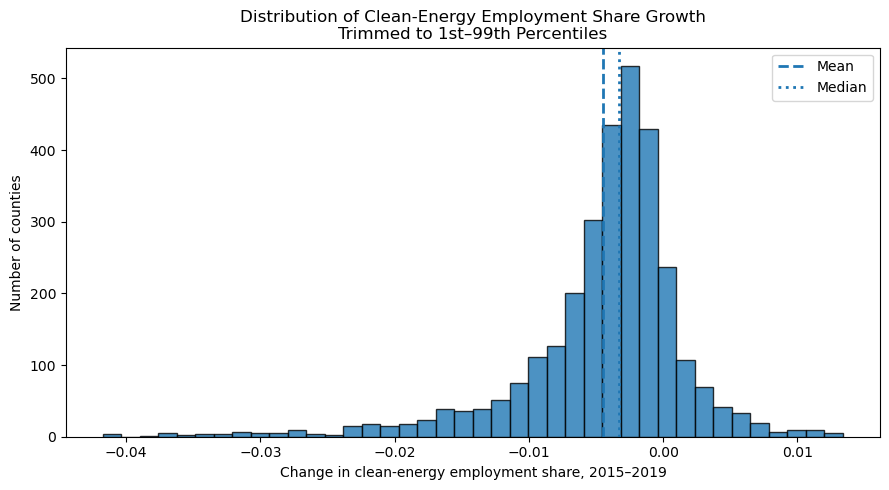


Saved:
figure_treatment_distribution_histogram_trimmed_p1_p99.png


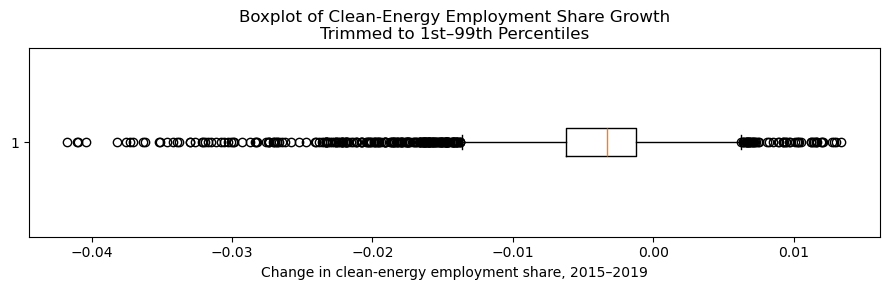


Saved:
figure_treatment_distribution_boxplot_trimmed_p1_p99.png

Step complete.
Created:
1. table1_summary_statistics_main_cleaned_sample.csv
2. table_treatment_distribution_main_cleaned_sample.csv
3. table_treatment_sign_distribution_main_cleaned_sample.csv
4. figure_treatment_distribution_histogram_trimmed_p1_p99.png
5. figure_treatment_distribution_boxplot_trimmed_p1_p99.png


In [25]:
# ------------------------------------------------------------
# Treatment distribution table
# Main Cleaned Sample
# ------------------------------------------------------------

t = df[treatment_var].dropna()

treatment_distribution_table = pd.DataFrame({
    "Statistic": [
        "N",
        "Mean",
        "Std. Dev.",
        "Min",
        "P1",
        "P5",
        "P10",
        "P25",
        "Median",
        "P75",
        "P90",
        "P95",
        "P99",
        "Max"
    ],
    "Value": [
        t.shape[0],
        t.mean(),
        t.std(),
        t.min(),
        t.quantile(0.01),
        t.quantile(0.05),
        t.quantile(0.10),
        t.quantile(0.25),
        t.quantile(0.50),
        t.quantile(0.75),
        t.quantile(0.90),
        t.quantile(0.95),
        t.quantile(0.99),
        t.max()
    ]
})

treatment_distribution_table["Value"] = treatment_distribution_table["Value"].round(6)

print("\nTreatment distribution table:")
print(treatment_distribution_table)

treatment_distribution_table.to_csv(
    "table_treatment_distribution_main_cleaned_sample.csv",
    index=False
)

print("\nSaved:")
print("table_treatment_distribution_main_cleaned_sample.csv")

# ------------------------------------------------------------
# 1. Treatment sign distribution table
# ------------------------------------------------------------

negative_count = (t < 0).sum()
zero_count = (t == 0).sum()
positive_count = (t > 0).sum()
total_count = t.shape[0]

treatment_sign_table = pd.DataFrame({
    "Category": [
        "Negative treatment",
        "Zero treatment",
        "Positive treatment"
    ],
    "Count": [
        negative_count,
        zero_count,
        positive_count
    ],
    "Share": [
        negative_count / total_count,
        zero_count / total_count,
        positive_count / total_count
    ]
})

treatment_sign_table["Share"] = treatment_sign_table["Share"].round(4)

print("\nTreatment sign distribution table:")
print(treatment_sign_table)

treatment_sign_table.to_csv(
    "table_treatment_sign_distribution_main_cleaned_sample.csv",
    index=False
)

print("\nSaved:")
print("table_treatment_sign_distribution_main_cleaned_sample.csv")

# ------------------------------------------------------------
# 2. Trimmed treatment distribution for figures only
# ------------------------------------------------------------

p1 = t.quantile(0.01)
p99 = t.quantile(0.99)

t_trimmed = t[
    (t >= p1)
    & (t <= p99)
]

print("\nTreatment range:")
print("Full sample min:", t.min())
print("Full sample max:", t.max())
print("Trimmed P1:", p1)
print("Trimmed P99:", p99)
print("N in full sample:", t.shape[0])
print("N in trimmed figure sample:", t_trimmed.shape[0])

# ------------------------------------------------------------
# 3. Histogram of treatment distribution, trimmed for readability
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(t_trimmed, bins=40, edgecolor="black", alpha=0.8)

plt.axvline(t_trimmed.mean(), linestyle="--", linewidth=2, label="Mean")
plt.axvline(t_trimmed.median(), linestyle=":", linewidth=2, label="Median")

plt.title(
    "Distribution of Clean-Energy Employment Share Growth\n"
    "Trimmed to 1st–99th Percentiles"
)
plt.xlabel("Change in clean-energy employment share, 2015–2019")
plt.ylabel("Number of counties")
plt.legend()

plt.tight_layout()
plt.savefig("figure_treatment_distribution_histogram_trimmed_p1_p99.png", dpi=300)
plt.show()

print("\nSaved:")
print("figure_treatment_distribution_histogram_trimmed_p1_p99.png")

# ------------------------------------------------------------
# 4. Boxplot of treatment distribution, trimmed for readability
# ------------------------------------------------------------

plt.figure(figsize=(9, 3))

plt.boxplot(t_trimmed, vert=False)

plt.title(
    "Boxplot of Clean-Energy Employment Share Growth\n"
    "Trimmed to 1st–99th Percentiles"
)
plt.xlabel("Change in clean-energy employment share, 2015–2019")

plt.tight_layout()
plt.savefig("figure_treatment_distribution_boxplot_trimmed_p1_p99.png", dpi=300)
plt.show()

print("\nSaved:")
print("figure_treatment_distribution_boxplot_trimmed_p1_p99.png")

# ------------------------------------------------------------
# 5. Optional: full treatment distribution table with sign table
# combined for viewing
# ------------------------------------------------------------

print("\nStep complete.")
print("Created:")
print("1. table1_summary_statistics_main_cleaned_sample.csv")
print("2. table_treatment_distribution_main_cleaned_sample.csv")
print("3. table_treatment_sign_distribution_main_cleaned_sample.csv")
print("4. figure_treatment_distribution_histogram_trimmed_p1_p99.png")
print("5. figure_treatment_distribution_boxplot_trimmed_p1_p99.png")

### Diagnostic

In [19]:
# ============================================================
# Step 27B.1
# ============================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Find available CSV files
# ------------------------------------------------------------

csv_files = [f for f in os.listdir() if f.endswith(".csv")]

print("CSV files in current folder:")
for f in csv_files:
    print(f)

# ------------------------------------------------------------
# 2. Choose main data file
# ------------------------------------------------------------
# Edit this if your filename is different.

possible_main_files = [
    "NEW Data(1).csv",
    "NEW Data.csv",
    "New Data.csv",
    "new data.csv"
]

main_file = None

for f in possible_main_files:
    if f in csv_files:
        main_file = f
        break

if main_file is None:
    raise FileNotFoundError(
        "Could not find NEW Data file. Check the printed CSV list above "
        "and manually set main_file = 'your_exact_filename.csv'."
    )

print("\nUsing main data file:")
print(main_file)

df_diag = pd.read_csv(main_file)

# ------------------------------------------------------------
# 3. Create county_fip if needed
# ------------------------------------------------------------

if "county_fip" not in df_diag.columns:
    if "FIPS" in df_diag.columns:
        df_diag["county_fip"] = df_diag["FIPS"].astype(str).str.replace(".0", "", regex=False).str.zfill(5)
    elif "fips" in df_diag.columns:
        df_diag["county_fip"] = df_diag["fips"].astype(str).str.replace(".0", "", regex=False).str.zfill(5)
    else:
        raise ValueError("No county_fip or FIPS column found.")

# ------------------------------------------------------------
# 4. Check required total employment columns
# ------------------------------------------------------------

required_total_emp_cols = [
    "total_employment_2015",
    "total_employment_2019"
]

missing_total_emp_cols = [
    col for col in required_total_emp_cols
    if col not in df_diag.columns
]

print("\nMissing total employment columns:")
print(missing_total_emp_cols)

if missing_total_emp_cols:
    raise ValueError("Missing total employment columns. Check column names.")

for col in required_total_emp_cols:
    df_diag[col] = pd.to_numeric(df_diag[col], errors="coerce")

# ------------------------------------------------------------
# 5. Identify energy columns
# ------------------------------------------------------------

main_cols = list(df_diag.columns)

cols_2015 = [col for col in main_cols if col.endswith("_2015")]
cols_2019 = [col for col in main_cols if col.endswith("_2019")]

non_energy_patterns = [
    "Personal_income",
    "personal_income",
    "Per_capita",
    "per_capita",
    "Population",
    "population",
    "Wage_Salaries",
    "wage",
    "salary",
    "total_employment",
    "Unemployment",
    "unemployment",
    "temp",
    "temperature",
    "income",
    "GDP",
    "gdp",
]

def is_non_energy_col(col):
    return any(pattern in col for pattern in non_energy_patterns)

energy_candidate_2015 = [
    col for col in cols_2015
    if not is_non_energy_col(col)
]

energy_candidate_2019 = [
    col for col in cols_2019
    if not is_non_energy_col(col)
]

# Conservative fossil/ambiguous exclusions
fossil_or_ambiguous_patterns = [
    "Natural Gas",
    "Petroleum",
    "Coal",
    "Oil & Other FF",
    "Oil and Other FF",
    "Other_F",
]

def is_fossil_or_ambiguous(col):
    return any(pattern in col for pattern in fossil_or_ambiguous_patterns)

clean_energy_cols_2015 = [
    col for col in energy_candidate_2015
    if not is_fossil_or_ambiguous(col)
]

clean_energy_cols_2019 = [
    col for col in energy_candidate_2019
    if not is_fossil_or_ambiguous(col)
]

# ------------------------------------------------------------
# 6. Use common clean-energy sectors only
# ------------------------------------------------------------

base_2015 = sorted([col.replace("_2015", "") for col in clean_energy_cols_2015])
base_2019 = sorted([col.replace("_2019", "") for col in clean_energy_cols_2019])

common_clean_bases = sorted(set(base_2015).intersection(set(base_2019)))

clean_energy_cols_2015_common = [base + "_2015" for base in common_clean_bases]
clean_energy_cols_2019_common = [base + "_2019" for base in common_clean_bases]

print("\nNumber of clean-energy columns before common-sector restriction:")
print("2015:", len(clean_energy_cols_2015))
print("2019:", len(clean_energy_cols_2019))

print("\nNumber of common clean-energy sectors:")
print(len(common_clean_bases))

print("\nCommon clean-energy sectors used:")
for x in common_clean_bases:
    print(x)

print("\nSectors in 2015 but not 2019:")
print(sorted(set(base_2015) - set(base_2019)))

print("\nSectors in 2019 but not 2015:")
print(sorted(set(base_2019) - set(base_2015)))

# ------------------------------------------------------------
# 7. Reconstruct treatment ingredients
# ------------------------------------------------------------

for col in clean_energy_cols_2015_common + clean_energy_cols_2019_common:
    df_diag[col] = pd.to_numeric(df_diag[col], errors="coerce")

df_diag["clean_energy_emp_2015"] = df_diag[clean_energy_cols_2015_common].sum(axis=1, skipna=True)
df_diag["clean_energy_emp_2019"] = df_diag[clean_energy_cols_2019_common].sum(axis=1, skipna=True)

df_diag["clean_energy_share_2015"] = df_diag["clean_energy_emp_2015"] / df_diag["total_employment_2015"]
df_diag["clean_energy_share_2019"] = df_diag["clean_energy_emp_2019"] / df_diag["total_employment_2019"]

df_diag["delta_clean_energy_share_2015_2019"] = (
    df_diag["clean_energy_share_2019"]
    - df_diag["clean_energy_share_2015"]
)

# ------------------------------------------------------------
# 8. Diagnostics
# ------------------------------------------------------------

needed_cols = [
    "county_fip",
    "county_name",
    "state",
    "clean_energy_emp_2015",
    "clean_energy_emp_2019",
    "total_employment_2015",
    "total_employment_2019",
    "clean_energy_share_2015",
    "clean_energy_share_2019",
    "delta_clean_energy_share_2015_2019"
]

needed_cols = [col for col in needed_cols if col in df_diag.columns]

print("\nClean-energy share summaries:")
print(
    df_diag[
        [
            "clean_energy_share_2015",
            "clean_energy_share_2019",
            "delta_clean_energy_share_2015_2019"
        ]
    ].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).T
)

invalid_shares = df_diag[
    (df_diag["clean_energy_share_2015"] < 0)
    | (df_diag["clean_energy_share_2015"] > 1)
    | (df_diag["clean_energy_share_2019"] < 0)
    | (df_diag["clean_energy_share_2019"] > 1)
]

print("\nRows with clean-energy shares outside [0, 1]:")
print(invalid_shares.shape[0])

if invalid_shares.shape[0] > 0:
    print(
        invalid_shares[needed_cols]
        .sort_values("delta_clean_energy_share_2015_2019")
        .head(30)
    )

invalid_delta = df_diag[
    (df_diag["delta_clean_energy_share_2015_2019"] < -1)
    | (df_diag["delta_clean_energy_share_2015_2019"] > 1)
]

print("\nRows with impossible treatment changes outside [-1, 1]:")
print(invalid_delta.shape[0])

if invalid_delta.shape[0] > 0:
    print(
        invalid_delta[needed_cols]
        .sort_values("delta_clean_energy_share_2015_2019")
        .head(30)
    )

df_diag["clean_emp_over_total_2015"] = (
    df_diag["clean_energy_emp_2015"] / df_diag["total_employment_2015"]
)

df_diag["clean_emp_over_total_2019"] = (
    df_diag["clean_energy_emp_2019"] / df_diag["total_employment_2019"]
)

over_total = df_diag[
    (df_diag["clean_emp_over_total_2015"] > 1)
    | (df_diag["clean_emp_over_total_2019"] > 1)
]

print("\nRows where clean-energy employment exceeds total employment:")
print(over_total.shape[0])

if over_total.shape[0] > 0:
    print(
        over_total[
            [
                "county_fip",
                "county_name",
                "state",
                "clean_energy_emp_2015",
                "total_employment_2015",
                "clean_emp_over_total_2015",
                "clean_energy_emp_2019",
                "total_employment_2019",
                "clean_emp_over_total_2019",
                "delta_clean_energy_share_2015_2019"
            ]
        ]
        .sort_values("delta_clean_energy_share_2015_2019")
        .head(30)
    )

# ------------------------------------------------------------
# 9. Save diagnostics
# ------------------------------------------------------------

#invalid_shares.to_csv("diagnostic_invalid_clean_energy_shares.csv", index=False)
#invalid_delta.to_csv("diagnostic_invalid_treatment_delta.csv", index=False)
#over_total.to_csv("diagnostic_clean_energy_emp_exceeds_total_emp.csv", index=False)

# Also save the reconstructed treatment data for Step 28
#df_diag.to_csv("main_with_reconstructed_treatment_for_diagnostics.csv", index=False)

#print("\nStep 27B revised complete.")
#print("Saved:")
#print("diagnostic_invalid_clean_energy_shares.csv")
#print("diagnostic_invalid_treatment_delta.csv")
#print("diagnostic_clean_energy_emp_exceeds_total_emp.csv")
#print("main_with_reconstructed_treatment_for_diagnostics.csv")

CSV files in current folder:
NEW Data.csv
econs513project_valid_treatment.csv
econs513project_valid_treatment_winsor_p1_p99.csv
nhgis0001_ds215_20155_county.csv
econs513project.csv
econs513project_valid_treatment_trimmed_p1_p99.csv
invalid_treatment_observations.csv

Using main data file:
NEW Data.csv

Missing total employment columns:
[]

Number of clean-energy columns before common-sector restriction:
2015: 16
2019: 18

Number of common clean-energy sectors:
15

Common clean-energy sectors used:
Advanced Materials & Insulation_EE
Corn Ethanol_F
ENERGY STAR & Efficient Lighting_EE
High Efficiency HVAC & Renewable H&C_EE
Hydroelectric_ (EPG)
MV
Micro Grid & Other Grid Mod TDS
Other_ (EPG)
Other_EE
Smart Grid TDS
Solar_ (EPG)
Storage TDS
Traditional HVAC_EE
Wind_ (EPG)
Woody Biomass_F

Sectors in 2015 but not 2019:
['Traditional TDS']

Sectors in 2019 but not 2015:
['Low-Impact Hydroelectric_ (EPG)', 'Other Clean Fuels_F', 'Traditional TDS ']

Clean-energy share summaries:
             

In [4]:
# ============================================================
# Step 27B.2 compact: show exact invalid treatment county
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

invalid_treatment = df_diag[
    (df_diag["clean_energy_share_2015"] < 0)
    | (df_diag["clean_energy_share_2015"] > 1)
    | (df_diag["clean_energy_share_2019"] < 0)
    | (df_diag["clean_energy_share_2019"] > 1)
].copy()

cols_to_show = [
    "county_fip",
    "county_name",
    "state",
    "clean_energy_emp_2015",
    "total_employment_2015",
    "clean_energy_share_2015",
    "clean_energy_emp_2019",
    "total_employment_2019",
    "clean_energy_share_2019",
    "delta_clean_energy_share_2015_2019"
]

print("\nInvalid treatment observations:")
print(invalid_treatment[cols_to_show])

print("\nNumber of invalid treatment observations:")
print(len(invalid_treatment))


Invalid treatment observations:
     county_fip  county_name state  clean_energy_emp_2015  total_employment_2015  clean_energy_share_2015  clean_energy_emp_2019  total_employment_2019  clean_energy_share_2019  \
2620      48263  Kent County    TX                    906                  603.0                 1.502488                     55                  589.0                 0.093379   

      delta_clean_energy_share_2015_2019  
2620                           -1.409109  

Number of invalid treatment observations:
1


Full treatment range:
min: -1.4091089543792077
max: 0.1709340026493598

Trimmed treatment range:
P1: -0.042146312889633754
P99: 0.013570284551938601
N trimmed: 3040


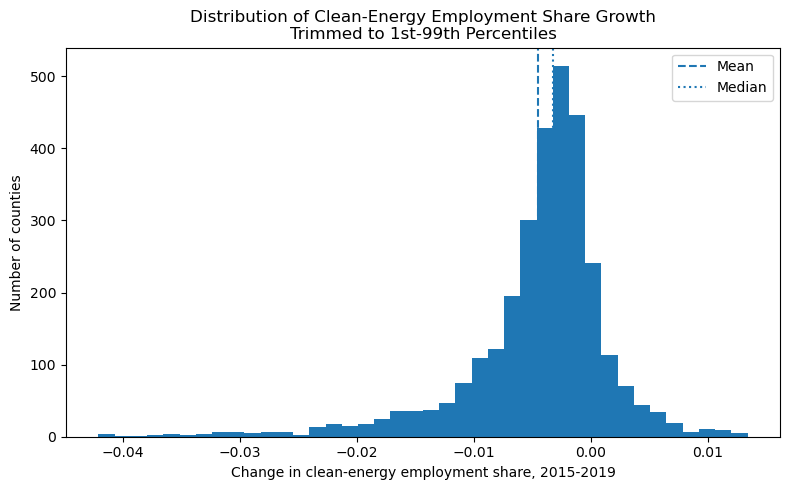

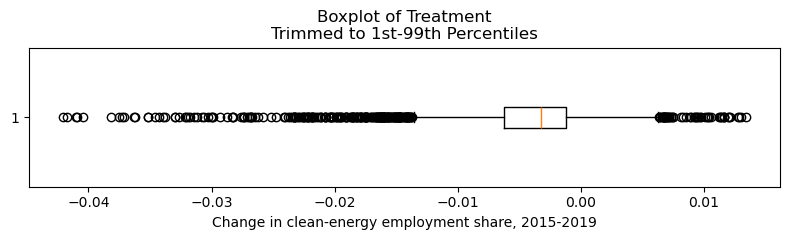

In [22]:
# ============================================================
# Step 27C: Treatment distribution plot trimmed to 1st-99th percentiles
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("econs513project.csv")

treatment_var = "delta_clean_energy_share_2015_2019"
t = pd.to_numeric(df[treatment_var], errors="coerce").dropna()

p01 = t.quantile(0.01)
p99 = t.quantile(0.99)

t_trim = t[(t >= p01) & (t <= p99)]

print("Full treatment range:")
print("min:", t.min())
print("max:", t.max())

print("\nTrimmed treatment range:")
print("P1:", p01)
print("P99:", p99)
print("N trimmed:", len(t_trim))

plt.figure(figsize=(8, 5))
plt.hist(t_trim, bins=40)
plt.axvline(t_trim.mean(), linestyle="--", label="Mean")
plt.axvline(t_trim.median(), linestyle=":", label="Median")
plt.xlabel("Change in clean-energy employment share, 2015-2019")
plt.ylabel("Number of counties")
plt.title("Distribution of Clean-Energy Employment Share Growth\nTrimmed to 1st-99th Percentiles")
plt.legend()
plt.tight_layout()
plt.savefig("treatment_histogram_trimmed_p1_p99.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 2.5))
plt.boxplot(t_trim, vert=False)
plt.xlabel("Change in clean-energy employment share, 2015-2019")
plt.title("Boxplot of Treatment\nTrimmed to 1st-99th Percentiles")
plt.tight_layout()
plt.savefig("treatment_boxplot_trimmed_p1_p99.png", dpi=300)
plt.show()

In [6]:
# ============================================================
# Step 28A: Drop invalid treatment-share observations
# Create corrected final modeling dataset
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Start from reconstructed diagnostic dataframe
# ------------------------------------------------------------
# df_diag should already exist from Step 27B.
# It contains reconstructed treatment ingredients.

df_clean = df_diag.copy()

# ------------------------------------------------------------
# 2. Identify invalid treatment observations
# ------------------------------------------------------------

invalid_treatment = df_clean[
    (df_clean["clean_energy_share_2015"] < 0)
    | (df_clean["clean_energy_share_2015"] > 1)
    | (df_clean["clean_energy_share_2019"] < 0)
    | (df_clean["clean_energy_share_2019"] > 1)
].copy()

print("\nInvalid treatment observations to drop:")
print(invalid_treatment[[
    "county_fip",
    "county_name",
    "state",
    "clean_energy_emp_2015",
    "total_employment_2015",
    "clean_energy_share_2015",
    "clean_energy_emp_2019",
    "total_employment_2019",
    "clean_energy_share_2019",
    "delta_clean_energy_share_2015_2019"
]])

print("\nRows before dropping invalid treatment observations:")
print(df_clean.shape[0])

# ------------------------------------------------------------
# 3. Keep only valid treatment observations
# ------------------------------------------------------------

df_clean = df_clean[
    (df_clean["clean_energy_share_2015"] >= 0)
    & (df_clean["clean_energy_share_2015"] <= 1)
    & (df_clean["clean_energy_share_2019"] >= 0)
    & (df_clean["clean_energy_share_2019"] <= 1)
].copy()

print("\nRows after dropping invalid treatment observations:")
print(df_clean.shape[0])

print("\nRows dropped:")
print(len(invalid_treatment))

# ------------------------------------------------------------
# 4. Save invalid-treatment diagnostic file
# ------------------------------------------------------------

invalid_treatment.to_csv("invalid_treatment_observations.csv", index=False)

print("\nSaved invalid treatment observations:")
print("invalid_treatment_observations.csv")

# ------------------------------------------------------------
# 5. Load existing final modeling dataset
# ------------------------------------------------------------
# This is your prior final dataset. It does not include treatment ingredients.
# We use county_fip to remove the invalid county from it.

final_old = pd.read_csv("econs513project.csv")

# Make county_fip consistent
final_old["county_fip"] = final_old["county_fip"].astype(str).str.zfill(5)
invalid_fips = invalid_treatment["county_fip"].astype(str).str.zfill(5).tolist()

print("\nInvalid FIPS to remove from final modeling dataset:")
print(invalid_fips)

final_valid = final_old[
    ~final_old["county_fip"].astype(str).str.zfill(5).isin(invalid_fips)
].copy()

print("\nOld final dataset shape:")
print(final_old.shape)

print("\nCorrected final dataset shape:")
print(final_valid.shape)

# ------------------------------------------------------------
# 6. Final checks
# ------------------------------------------------------------

print("\nCorrected final dataset checks:")
print("Rows:", final_valid.shape[0])
print("Unique county_fip:", final_valid["county_fip"].nunique())
print("Duplicate county_fip:", final_valid["county_fip"].duplicated().sum())
print("Missing values:", final_valid.isna().sum().sum())

# Check treatment range
treatment_var = "delta_clean_energy_share_2015_2019"

print("\nCorrected treatment summary:")
print(
    final_valid[treatment_var]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

# ------------------------------------------------------------
# 7. Save corrected final dataset
# ------------------------------------------------------------

final_valid.to_csv("econs513project_valid_treatment.csv", index=False)

print("\nStep 28 complete.")
print("Saved corrected final dataset:")
print("econs513project_valid_treatment.csv")


Invalid treatment observations to drop:
     county_fip  county_name state  clean_energy_emp_2015  total_employment_2015  clean_energy_share_2015  clean_energy_emp_2019  total_employment_2019  clean_energy_share_2019  \
2620      48263  Kent County    TX                    906                  603.0                 1.502488                     55                  589.0                 0.093379   

      delta_clean_energy_share_2015_2019  
2620                           -1.409109  

Rows before dropping invalid treatment observations:
3107

Rows after dropping invalid treatment observations:
3106

Rows dropped:
1

Saved invalid treatment observations:
invalid_treatment_observations.csv

Invalid FIPS to remove from final modeling dataset:
['48263']

Old final dataset shape:
(3104, 59)

Corrected final dataset shape:
(3103, 59)

Corrected final dataset checks:
Rows: 3103
Unique county_fip: 3103
Duplicate county_fip: 0
Missing values: 0

Corrected treatment summary:
count    3103.000000


In [7]:
# ============================================================
# Step 28B: Inspect remaining treatment extremes after cleaning
# ============================================================

import pandas as pd

df_valid = pd.read_csv("econs513project_valid_treatment.csv")

treatment_var = "delta_clean_energy_share_2015_2019"

print("\nCorrected treatment summary:")
print(
    df_valid[treatment_var]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

print("\nBottom 15 counties by corrected treatment:")
print(
    df_valid[
        ["county_fip", "county_name", "state", treatment_var]
    ]
    .sort_values(treatment_var)
    .head(15)
)

print("\nTop 15 counties by corrected treatment:")
print(
    df_valid[
        ["county_fip", "county_name", "state", treatment_var]
    ]
    .sort_values(treatment_var, ascending=False)
    .head(15)
)


Corrected treatment summary:
count    3103.000000
mean       -0.005358
std         0.019096
min        -0.686326
1%         -0.042080
5%         -0.018061
10%        -0.011969
25%        -0.006322
50%        -0.003266
75%        -0.001166
90%         0.001274
95%         0.003748
99%         0.013572
max         0.170934
Name: delta_clean_energy_share_2015_2019, dtype: float64

Bottom 15 counties by corrected treatment:
      county_fip        county_name state  delta_clean_energy_share_2015_2019
1908       35021     Harding County    NM                           -0.686326
1864       31183     Wheeler County    NE                           -0.409327
358        13001     Appling County    GA                           -0.270455
73          5013     Calhoun County    AR                           -0.212598
1720       38001       Adams County    ND                           -0.177323
1938       32017     Lincoln County    NV                           -0.147940
2906       50013  Grand Isle 

## Create Trimmed and Winsorized Robustness datasets

In [8]:
# ============================================================
# Step 29: Create treatment-tail robustness datasets
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv("econs513project_valid_treatment.csv")

treatment_var = "delta_clean_energy_share_2015_2019"

df[treatment_var] = pd.to_numeric(df[treatment_var], errors="coerce")

# ------------------------------------------------------------
# 1. Compute 1st and 99th percentile cutoffs
# ------------------------------------------------------------

p01 = df[treatment_var].quantile(0.01)
p99 = df[treatment_var].quantile(0.99)

print("Treatment P1:", p01)
print("Treatment P99:", p99)

# ------------------------------------------------------------
# 2. Create trimmed sample: drop treatment outside [P1, P99]
# ------------------------------------------------------------

df_trimmed = df[
    (df[treatment_var] >= p01)
    & (df[treatment_var] <= p99)
].copy()

print("\nMain valid-treatment sample rows:")
print(df.shape[0])

print("\nTrimmed 1st-99th percentile sample rows:")
print(df_trimmed.shape[0])

print("\nRows dropped by trimming:")
print(df.shape[0] - df_trimmed.shape[0])

# ------------------------------------------------------------
# 3. Create winsorized treatment variable
# ------------------------------------------------------------

df_winsor = df.copy()
df_winsor[treatment_var + "_winsor_1_99"] = df_winsor[treatment_var].clip(
    lower=p01,
    upper=p99
)

print("\nOriginal treatment summary:")
print(
    df[treatment_var]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
)

print("\nWinsorized treatment summary:")
print(
    df_winsor[treatment_var + "_winsor_1_99"]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
)

# ------------------------------------------------------------
# 4. Save robustness datasets
# ------------------------------------------------------------

df_trimmed.to_csv("econs513project_valid_treatment_trimmed_p1_p99.csv", index=False)
df_winsor.to_csv("econs513project_valid_treatment_winsor_p1_p99.csv", index=False)

print("\nStep 29 complete.")
print("Saved:")
print("econs513project_valid_treatment_trimmed_p1_p99.csv")
print("econs513project_valid_treatment_winsor_p1_p99.csv")

Treatment P1: -0.042080140890691335
Treatment P99: 0.013572094565836561

Main valid-treatment sample rows:
3103

Trimmed 1st-99th percentile sample rows:
3039

Rows dropped by trimming:
64

Original treatment summary:
count    3103.000000
mean       -0.005358
std         0.019096
min        -0.686326
1%         -0.042080
5%         -0.018061
50%        -0.003266
95%         0.003748
99%         0.013572
max         0.170934
Name: delta_clean_energy_share_2015_2019, dtype: float64

Winsorized treatment summary:
count    3103.000000
mean       -0.004670
std         0.007549
min        -0.042080
1%         -0.042073
5%         -0.018061
50%        -0.003266
95%         0.003748
99%         0.013569
max         0.013572
Name: delta_clean_energy_share_2015_2019_winsor_1_99, dtype: float64

Step 29 complete.
Saved:
econs513project_valid_treatment_trimmed_p1_p99.csv
econs513project_valid_treatment_winsor_p1_p99.csv


## Baseline OLS Estimates

Prompt: Baseline OLS Comparison for Clean-Energy Employment-Share Growth

Write clean, reproducible Python code to estimate baseline OLS models for the causal effect of county clean-energy employment-share growth from 2015 to 2019 on local economic performance.

The purpose is to create benchmark OLS estimates that can be compared with the Double Machine Learning results. These OLS models should be transparent, well-documented, and easy to interpret.

---

#### Research Question

Estimate whether counties with larger growth in clean-energy employment share from 2015 to 2019 experienced stronger local economic performance over the same period.

---

#### Treatment Variable

The treatment is continuous:

```python
treatment = "delta_clean_energy_share_2015_2019"
```

This variable measures:

$$D_i = \text{CleanEnergyShare}_{i,2019}-\text{CleanEnergyShare}_{i,2015}.$$

Because the treatment is a share change, interpret a one-percentage-point increase as:

$$0.01 \times \hat{\beta}.$$

---

#### Outcome Variables

Estimate models for the following outcomes: Effect on Income Growth, Effect on Wage growth, and Effect on Unemployment rate.

---

#### The key identification assumption

$$E[\varepsilon_i \mid D_i, X_i]=0$$

---

#### OLS Model Specifications

Estimate three OLS specifications for each outcome.

---

##### Model 1: Naive OLS

Estimate the unconditional relationship between the outcome and clean-energy employment-share growth:

$$Y_i = \alpha + \beta D_i + \varepsilon_i.$$

This model includes only the treatment variable.

---

##### Model 2: OLS with Baseline Economic Controls

Estimate:

$$Y_i = \alpha + \beta D_i + X_{i,\text{econ}}'\gamma + \varepsilon_i.$$

These controls account for baseline county economic conditions before the 2015–2019 treatment window.

---

##### Model 3: OLS with Full Controls

Estimate:

$$Y_i = \alpha + \beta D_i + X_i'\gamma + \varepsilon_i.$$

Full controls should include:

1. baseline economic controls,
2. 2011–2015 pre-trend controls,
3. NHGIS demographic, socioeconomic, housing, commuting, labor-force, and industry controls.

Use the following control lists.

---

##### Model 4: OLS with Full controls + state fixed effects

Estimate:

$$Y_i = \alpha + \beta D_i + X_i'\gamma + \delta_s \varepsilon_i.$$

---

#### Estimation Requirements

For each outcome and each model specification:

1. Load the dataset.
2. Check that all variables exist.
3. Drop rows with missing values in the outcome, treatment, and controls.
4. Add a constant.
5. Estimate OLS.
6. Use heteroskedasticity-robust standard errors, preferably HC1.
7. Extract the treatment coefficient and inference statistics.

---

#### Output Requirements

Create a clean summary table with one row per outcome and model.

The table should include:

```python
[
    "outcome",
    "model",
    "n",
    "r_squared",
    "adj_r_squared",
    "estimate",
    "std_error",
    "t_stat",
    "p_value",
    "ci_low",
    "ci_high",
    "effect_1pp",
    "effect_1pp_percent_if_log_outcome",
    "n_controls"
]
```

Where:

```python
estimate = coefficient on delta_clean_energy_share_2015_2019
effect_1pp = 0.01 * estimate
```

For log outcomes:

```python
effect_1pp_percent_if_log_outcome = 100 * effect_1pp
```

For non-log outcomes, set:

```python
effect_1pp_percent_if_log_outcome = np.nan
```

For the unemployment-rate outcome, explain that:

```python
effect_1pp
```

is measured in unemployment-rate percentage points.

---

#### Model Labels

Use the following labels:

```python
model_specs = {
    "1. Naive OLS": [],
    "2. Baseline Economic Controls": baseline_economic_controls,
    "3. Full Controls": full_controls
    "4. Full Controls + State Fixed Effects"
}
```

---

#### Deliverables

Provide:

1. Clean modular Python code
2. Clear comments explaining each step of the DML algorithm with a header 
3. Example usage on a dataset

Include Helpers

---

#### Interpretation Requirements

After producing the table, print a short interpretation for each outcome.

For the main outcome:

```python
delta_log_income_pc_2015_2019
```

interpret the coefficient as:

> A one-percentage-point increase in clean-energy employment-share growth is associated with approximately \(100 \times 0.01 \times \hat{\beta}\)% change in income per capita growth.

For unemployment:

```python
delta_unemployment_rate_2015_2019
```

interpret the coefficient as:

> A one-percentage-point increase in clean-energy employment-share growth is associated with \(0.01 \times \hat{\beta}\) percentage-point change in the unemployment-rate change.

For wage growth:

```python
delta_log_wages_pc_2015_2019
```

interpret the coefficient as:

> A one-percentage-point increase in clean-energy employment-share growth is associated with approximately \(100 \times 0.01 \times \hat{\beta}\)% change in wage-per-capita growth.

---

#### Important Notes

Do not claim that OLS alone identifies a causal effect without the selection-on-observables assumption.

Do not include post-treatment controls measured after 2015.

Use robust standard errors.

In [26]:
# ============================================================
# Baseline OLS Estimation
# Main Cleaned Sample
# Clean-Energy Employment Share Growth and County Outcomes
# ============================================================
#
# Dataset:
#   econs513project_valid_treatment.csv
#
# Treatment:
#   delta_clean_energy_share_2015_2019
#
# Outcomes:
#   1. delta_log_income_pc_2015_2019
#   2. delta_unemployment_rate_2015_2019
#   3. delta_log_wages_pc_2015_2019
#
# Models:
#   Model 1: Naive OLS
#   Model 2: Baseline economic controls
#   Model 3: Full controls
#   Model 4: Full controls + region fixed effects
#   Model 5: Full controls + state fixed effects
#
# Standard errors:
#   Heteroskedasticity-robust HC1
#
# Notes:
#   - County fixed effects are NOT included because there is only
#     one observation per county.
#   - The treatment is a share change. A one-percentage-point
#     increase equals 0.01.
#   - For log outcomes, the effect of a 1pp treatment increase
#     is approximately 100 * 0.01 * beta percent.
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm


# ============================================================
# 2. Load Data
# ============================================================

def load_data(data_path: str) -> pd.DataFrame:
    """
    Load the final county-level analysis dataset.

    Parameters
    ----------
    data_path : str
        Path to CSV file.

    Returns
    -------
    df : pandas DataFrame
        Loaded dataset.
    """

    df = pd.read_csv(data_path)

    print("\nDataset loaded.")
    print("File:", data_path)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    return df


# ============================================================
# 3. Create Census Region Variable
# ============================================================

def add_census_region(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create Census region variable from state abbreviation.

    Parameters
    ----------
    df : pandas DataFrame
        Dataset containing a 'state' column with two-letter abbreviations.

    Returns
    -------
    df : pandas DataFrame
        Dataset with added 'region' column.
    """

    if "state" not in df.columns:
        raise ValueError("The dataset must contain a 'state' column to create region FE.")

    state_to_region = {
        # Northeast
        "CT": "Northeast", "ME": "Northeast", "MA": "Northeast",
        "NH": "Northeast", "RI": "Northeast", "VT": "Northeast",
        "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

        # Midwest
        "IL": "Midwest", "IN": "Midwest", "MI": "Midwest",
        "OH": "Midwest", "WI": "Midwest",
        "IA": "Midwest", "KS": "Midwest", "MN": "Midwest",
        "MO": "Midwest", "NE": "Midwest", "ND": "Midwest",
        "SD": "Midwest",

        # South
        "DE": "South", "FL": "South", "GA": "South",
        "MD": "South", "NC": "South", "SC": "South",
        "VA": "South", "DC": "South", "WV": "South",
        "AL": "South", "KY": "South", "MS": "South",
        "TN": "South", "AR": "South", "LA": "South",
        "OK": "South", "TX": "South",

        # West
        "AZ": "West", "CO": "West", "ID": "West",
        "MT": "West", "NV": "West", "NM": "West",
        "UT": "West", "WY": "West",
        "AK": "West", "CA": "West", "HI": "West",
        "OR": "West", "WA": "West"
    }

    df = df.copy()
    df["state"] = df["state"].astype(str).str.upper().str.strip()
    df["region"] = df["state"].map(state_to_region)

    print("\nRegion variable created from state.")
    print(df["region"].value_counts(dropna=False))

    if df["region"].isna().any():
        missing_states = sorted(df.loc[df["region"].isna(), "state"].unique())
        raise ValueError(f"Some states could not be mapped to Census regions: {missing_states}")

    return df


# ============================================================
# 4. Variable Checks
# ============================================================

def check_variables(df: pd.DataFrame, variables: list):
    """
    Check that all variables exist in the dataset.

    Parameters
    ----------
    df : pandas DataFrame
        Dataset.
    variables : list
        Variable names required for model.

    Raises
    ------
    ValueError
        If any variables are missing.
    """

    missing_vars = [v for v in variables if v not in df.columns]

    if missing_vars:
        raise ValueError(f"Missing variables: {missing_vars}")

    return True


# ============================================================
# 5. Add Fixed Effects
# ============================================================

def add_fixed_effects(df: pd.DataFrame, fe_vars: list) -> pd.DataFrame:
    """
    Create numeric fixed-effect dummy variables.

    Parameters
    ----------
    df : pandas DataFrame
        Model dataframe.
    fe_vars : list
        List of categorical fixed-effect variables.

    Returns
    -------
    fe_df : pandas DataFrame
        Dummy variable dataframe.
    """

    if fe_vars is None or len(fe_vars) == 0:
        return pd.DataFrame(index=df.index)

    fe_blocks = []

    for fe in fe_vars:
        if fe not in df.columns:
            raise ValueError(f"Fixed effect variable not found: {fe}")

        dummies = pd.get_dummies(
            df[fe].astype(str),
            prefix=fe,
            drop_first=True,
            dtype=float
        )

        fe_blocks.append(dummies)

    fe_df = pd.concat(fe_blocks, axis=1)
    fe_df = fe_df.astype(float)

    return fe_df


# ============================================================
# 6. Run One OLS Model
# ============================================================

def run_ols_model(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list,
    model_name: str,
    fe_vars: list = None,
    cov_type: str = "HC1"
):
    """
    Run one OLS model with optional fixed effects.

    Parameters
    ----------
    df : pandas DataFrame
        Analysis dataset.
    outcome : str
        Outcome variable name.
    treatment : str
        Treatment variable name.
    controls : list
        Control variable names.
    model_name : str
        Specification name.
    fe_vars : list
        Fixed-effect variable names.
    cov_type : str
        Covariance type, default HC1.

    Returns
    -------
    result_row : dict
        Summary row for treatment coefficient.
    model : statsmodels regression result
        Fitted OLS model.
    """

    if controls is None:
        controls = []

    if fe_vars is None:
        fe_vars = []

    required_vars = [outcome, treatment] + controls + fe_vars
    check_variables(df, required_vars)

    # Keep only required variables
    df_model = df[required_vars].copy()

    # Replace infinite values with missing
    df_model = df_model.replace([np.inf, -np.inf], np.nan)

    # Convert outcome, treatment, and controls to numeric
    numeric_vars = [outcome, treatment] + controls

    for col in numeric_vars:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

    # Drop missing observations after numeric conversion
    n_before = df_model.shape[0]
    df_model = df_model.dropna().copy()

    # Outcome
    y = df_model[outcome].astype(float)

    # Treatment and controls
    X_parts = []

    X_treatment = df_model[[treatment]].astype(float)
    X_parts.append(X_treatment)

    if len(controls) > 0:
        X_controls = df_model[controls].astype(float)
        X_parts.append(X_controls)

    # Fixed effects
    if len(fe_vars) > 0:
        X_fe = add_fixed_effects(df_model, fe_vars)
        X_parts.append(X_fe)

    X = pd.concat(X_parts, axis=1)

    # Add constant
    X = sm.add_constant(X, has_constant="add")

    # Force entire design matrix to numeric float
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.astype(float)

    # Align y and X after any possible coercion
    valid_rows = X.notna().all(axis=1) & y.notna()
    X = X.loc[valid_rows].copy()
    y = y.loc[valid_rows].copy()

    # Final defensive checks
    if X.isna().sum().sum() > 0:
        raise ValueError("X still contains missing values after cleaning.")

    if y.isna().sum() > 0:
        raise ValueError("y still contains missing values after cleaning.")

    object_cols = X.select_dtypes(include=["object"]).columns.tolist()
    if len(object_cols) > 0:
        raise ValueError(f"X still contains object columns: {object_cols}")

    # Fit OLS with robust standard errors
    model = sm.OLS(y, X).fit(cov_type=cov_type)

    # Extract treatment coefficient
    estimate = model.params[treatment]
    std_error = model.bse[treatment]
    t_stat = model.tvalues[treatment]
    p_value = model.pvalues[treatment]

    ci_low, ci_high = model.conf_int().loc[treatment].tolist()

    # Treatment is a share change.
    # One percentage point = 0.01.
    effect_1pp = 0.01 * estimate
    effect_1pp_ci_low = 0.01 * ci_low
    effect_1pp_ci_high = 0.01 * ci_high

    # For log outcomes, approximate percent effect
    if "log" in outcome:
        effect_1pp_percent_if_log_outcome = 100 * effect_1pp
        effect_1pp_percent_ci_low = 100 * effect_1pp_ci_low
        effect_1pp_percent_ci_high = 100 * effect_1pp_ci_high
    else:
        effect_1pp_percent_if_log_outcome = np.nan
        effect_1pp_percent_ci_low = np.nan
        effect_1pp_percent_ci_high = np.nan

    result_row = {
        "outcome": outcome,
        "model": model_name,
        "n": int(model.nobs),
        "rows_dropped": n_before - int(model.nobs),
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "estimate": estimate,
        "std_error": std_error,
        "t_stat": t_stat,
        "p_value": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "effect_1pp": effect_1pp,
        "effect_1pp_ci_low": effect_1pp_ci_low,
        "effect_1pp_ci_high": effect_1pp_ci_high,
        "effect_1pp_percent_if_log_outcome": effect_1pp_percent_if_log_outcome,
        "effect_1pp_percent_ci_low": effect_1pp_percent_ci_low,
        "effect_1pp_percent_ci_high": effect_1pp_percent_ci_high,
        "n_controls": len(controls),
        "fixed_effects": ", ".join(fe_vars) if len(fe_vars) > 0 else "None",
        "cov_type": cov_type
    }

    return result_row, model


# ============================================================
# 7. Run All OLS Models
# ============================================================

def run_all_ols_models(
    df: pd.DataFrame,
    outcomes: list,
    treatment: str,
    model_specs: dict,
    cov_type: str = "HC1"
):
    """
    Run all OLS models for all outcomes.

    Parameters
    ----------
    df : pandas DataFrame
        Dataset.
    outcomes : list
        Outcome variable names.
    treatment : str
        Treatment variable.
    model_specs : dict
        Model specifications.
    cov_type : str
        Robust covariance type.

    Returns
    -------
    results_df : pandas DataFrame
        Summary results.
    models : dict
        Fitted statsmodels objects.
    """

    results = []
    models = {}

    for outcome in outcomes:
        for model_name, spec in model_specs.items():

            print("\n" + "=" * 80)
            print(f"Running: {model_name}")
            print(f"Outcome: {outcome}")
            print("=" * 80)

            controls = spec.get("controls", [])
            fe_vars = spec.get("fe_vars", [])

            result_row, model = run_ols_model(
                df=df,
                outcome=outcome,
                treatment=treatment,
                controls=controls,
                model_name=model_name,
                fe_vars=fe_vars,
                cov_type=cov_type
            )

            results.append(result_row)

            model_key = f"{outcome}__{model_name}"
            models[model_key] = model

    results_df = pd.DataFrame(results)

    return results_df, models


# ============================================================
# 8. Format OLS Summary Table
# ============================================================

def format_ols_summary(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Format OLS results into a clean summary table.

    Parameters
    ----------
    results_df : pandas DataFrame
        Raw OLS results.

    Returns
    -------
    ols_summary : pandas DataFrame
        Formatted OLS summary table.
    """

    ols_summary = results_df.copy()

    # Confidence intervals as strings
    ols_summary["CI"] = (
        "["
        + ols_summary["ci_low"].round(6).astype(str)
        + ", "
        + ols_summary["ci_high"].round(6).astype(str)
        + "]"
    )

    ols_summary["Effect 1pp CI"] = (
        "["
        + ols_summary["effect_1pp_ci_low"].round(6).astype(str)
        + ", "
        + ols_summary["effect_1pp_ci_high"].round(6).astype(str)
        + "]"
    )

    ols_summary["Effect 1pp Percent CI"] = (
        "["
        + ols_summary["effect_1pp_percent_ci_low"].round(6).astype(str)
        + ", "
        + ols_summary["effect_1pp_percent_ci_high"].round(6).astype(str)
        + "]"
    )

    # Round numeric columns
    round_cols = [
        "r_squared",
        "adj_r_squared",
        "estimate",
        "std_error",
        "t_stat",
        "p_value",
        "ci_low",
        "ci_high",
        "effect_1pp",
        "effect_1pp_ci_low",
        "effect_1pp_ci_high",
        "effect_1pp_percent_if_log_outcome",
        "effect_1pp_percent_ci_low",
        "effect_1pp_percent_ci_high"
    ]

    for col in round_cols:
        if col in ols_summary.columns:
            ols_summary[col] = ols_summary[col].round(6)

    keep_cols = [
        "outcome",
        "model",
        "n",
        "rows_dropped",
        "r_squared",
        "adj_r_squared",
        "estimate",
        "std_error",
        "t_stat",
        "p_value",
        "CI",
        "effect_1pp",
        "Effect 1pp CI",
        "effect_1pp_percent_if_log_outcome",
        "Effect 1pp Percent CI",
        "n_controls",
        "fixed_effects",
        "cov_type"
    ]

    keep_cols = [c for c in keep_cols if c in ols_summary.columns]

    ols_summary = ols_summary[keep_cols].copy()

    return ols_summary


# ============================================================
# 9. Create Outcome-Specific Tables
# ============================================================

def make_ols_outcome_table(
    ols_summary: pd.DataFrame,
    outcome_name: str,
    title: str,
    include_log_percent_effect: bool = True,
    output_file: str = None
):
    """
    Create one clean table for one outcome.

    Parameters
    ----------
    ols_summary : pandas DataFrame
        Full OLS summary.
    outcome_name : str
        Outcome variable to filter.
    title : str
        Table title.
    include_log_percent_effect : bool
        Whether to include percent effect column.
    output_file : str
        Optional CSV file name.

    Returns
    -------
    table : pandas DataFrame
        Outcome-specific table.
    """

    table = ols_summary[ols_summary["outcome"] == outcome_name].copy()

    keep_cols = [
        "model",
        "n",
        "r_squared",
        "adj_r_squared",
        "estimate",
        "std_error",
        "p_value",
        "CI",
        "effect_1pp",
        "fixed_effects"
    ]

    if include_log_percent_effect:
        keep_cols.append("effect_1pp_percent_if_log_outcome")

    table = table[keep_cols].copy()

    rename_cols = {
        "model": "Specification",
        "n": "N",
        "r_squared": "R-squared",
        "adj_r_squared": "Adjusted R-squared",
        "estimate": "Estimate",
        "std_error": "Std. Error",
        "p_value": "P-value",
        "effect_1pp": "Effect of 1pp Treatment Increase",
        "effect_1pp_percent_if_log_outcome": "Effect of 1pp Treatment Increase (%)",
        "fixed_effects": "Fixed Effects"
    }

    table = table.rename(columns=rename_cols)

    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))
    print(table)

    #if output_file is not None:
    #    table.to_csv(output_file, index=False)
    #    print(f"\nSaved: {output_file}")

    #return table


# ============================================================
# 10. Create DML-Style OLS Tables
# ============================================================

def make_ols_table_like_dml(
    ols_summary: pd.DataFrame,
    outcome_name: str,
    title: str,
    include_log_percent_effect: bool = True,
    output_file: str = None
):
    """
    Create a compact OLS table for one outcome, formatted similarly
    to DML result tables.
    """

    ols_display = ols_summary.copy()

    rename_map = {
        "model": "Specification",
        "n": "N",
        "estimate": "Estimate",
        "p_value": "P-value",
        "effect_1pp": "Effect of 1pp Treatment Increase",
        "effect_1pp_percent_if_log_outcome": "Effect of 1pp Treatment Increase (%)"
    }

    ols_display = ols_display.rename(columns=rename_map)

    if "CI" not in ols_display.columns:
        ols_display["CI"] = (
            "["
            + ols_display["ci_low"].round(6).astype(str)
            + ", "
            + ols_display["ci_high"].round(6).astype(str)
            + "]"
        )

    round_cols = [
        "Estimate",
        "std_error",
        "t_stat",
        "P-value",
        "Effect of 1pp Treatment Increase",
        "Effect of 1pp Treatment Increase (%)",
        "r_squared",
        "adj_r_squared"
    ]

    round_cols = [col for col in round_cols if col in ols_display.columns]
    ols_display[round_cols] = ols_display[round_cols].round(6)

    table = ols_display[ols_display["outcome"] == outcome_name].copy()

    if include_log_percent_effect:
        keep_cols = [
            "Specification",
            "N",
            "Estimate",
            "P-value",
            "CI",
            "Effect of 1pp Treatment Increase (%)"
        ]
    else:
        keep_cols = [
            "Specification",
            "N",
            "Estimate",
            "P-value",
            "CI",
            "Effect of 1pp Treatment Increase"
        ]

    table = table[keep_cols].copy()
    table = table.sort_values("Specification").reset_index(drop=True)

    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))
    print(table)

    #if output_file is not None:
    #    table.to_csv(output_file, index=False)
    #    print(f"\nSaved: {output_file}")

    #return table


# ============================================================
# 11. Print Interpretation
# ============================================================

def print_ols_interpretation(results_df: pd.DataFrame):
    """
    Print short interpretation of OLS treatment estimates.
    """

    print("\n" + "=" * 80)
    print("OLS Interpretation Summary")
    print("=" * 80)

    for _, row in results_df.iterrows():

        outcome = row["outcome"]
        model = row["model"]
        estimate = row["estimate"]
        p_value = row["p_value"]
        effect_1pp = row["effect_1pp"]

        print("\n" + "-" * 80)
        print(f"Outcome: {outcome}")
        print(f"Model: {model}")
        print(f"Estimate: {estimate:.6f}")
        print(f"Effect of 1pp treatment increase: {effect_1pp:.6f}")
        print(f"P-value: {p_value:.4f}")

        if "log" in outcome:
            percent_effect = row["effect_1pp_percent_if_log_outcome"]
            print(
                f"Interpretation: A one-percentage-point increase in clean-energy "
                f"employment-share growth is associated with approximately "
                f"{percent_effect:.4f}% change in {outcome}, conditional on this model's controls."
            )

        elif "unemployment" in outcome:
            print(
                f"Interpretation: A one-percentage-point increase in clean-energy "
                f"employment-share growth is associated with a "
                f"{effect_1pp:.4f} percentage-point change in unemployment-rate change, "
                f"conditional on this model's controls."
            )

        else:
            print(
                f"Interpretation: A one-percentage-point increase in clean-energy "
                f"employment-share growth is associated with a "
                f"{effect_1pp:.6f} change in {outcome}, conditional on this model's controls."
            )




In [27]:
# ============================================================
# 12. Main Usage
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # File path: main cleaned sample
    # --------------------------------------------------------

    data_path = "econs513project_valid_treatment.csv"

    df = load_data(data_path)

    # --------------------------------------------------------
    # Basic checks
    # --------------------------------------------------------

    print("\nBasic final-sample checks:")
    print("Missing values:", df.isna().sum().sum())

    if "county_fip" in df.columns:
        print("Unique county_fip:", df["county_fip"].astype(str).nunique())
        print("Duplicate county_fip:", df["county_fip"].astype(str).duplicated().sum())

    # --------------------------------------------------------
    # Create region variable
    # --------------------------------------------------------

    df = add_census_region(df)

    # --------------------------------------------------------
    # Treatment
    # --------------------------------------------------------

    treatment = "delta_clean_energy_share_2015_2019"

    # --------------------------------------------------------
    # Outcomes
    # --------------------------------------------------------

    outcomes = [
        "delta_log_income_pc_2015_2019",
        "delta_unemployment_rate_2015_2019",
        "delta_log_wages_pc_2015_2019"
    ]

    # --------------------------------------------------------
    # Baseline economic controls
    # --------------------------------------------------------

    baseline_economic_controls = [
        "log_income_pc_2015",
        "log_population_2015",
        "log_total_employment_2015",
        "unemployment_rate_2015",
        "log_wages_pc_2015",
        "baseline_clean_energy_share_2015",
        "baseline_fossil_or_ambiguous_share_2015",
        "log1p_clean_energy_emp_2015",
        "log1p_fossil_or_ambiguous_emp_2015"
    ]

    # --------------------------------------------------------
    # Pre-trend controls
    # --------------------------------------------------------

    pretrend_controls = [
        "income_pc_growth_2011_2015",
        "population_growth_2011_2015",
        "wage_growth_2011_2015",
        "wage_pc_growth_2011_2015",
        "employment_growth_2011_2015",
        "unemployment_rate_change_2011_2015"
    ]

    # --------------------------------------------------------
    # NHGIS controls
    # --------------------------------------------------------

    nhgis_controls = [
        # Age structure
        "share_under18_2015",
        "share_25_54_2015",
        "share_65plus_2015",

        # Race / ethnicity
        "share_nonhisp_white_2015",
        "share_nonhisp_black_2015",
        "share_nonhisp_asian_2015",
        "share_hispanic_2015",
        "share_other_nonhisp_2015",

        # Education
        "share_less_hs_2015",
        "share_ba_or_more_2015",
        "share_some_college_or_assoc_2015",

        # Poverty and income
        "poverty_rate_2015",
        "log_median_household_income_2015",

        # Labor force
        "labor_force_participation_rate_2015",
        "acs_employment_rate_2015",
        "acs_unemployment_rate_2015",

        # Housing
        "homeownership_rate_2015",
        "log_median_gross_rent_2015",
        "log_median_home_value_2015",

        # Commuting
        "share_drive_alone_2015",
        "share_public_transit_2015",
        "share_work_from_home_2015",
        "share_commute_30plus_2015",
        "approx_mean_commute_minutes_2015",

        # Industry composition
        "share_agriculture_2015",
        "share_mining_oil_gas_2015",
        "share_construction_2015",
        "share_manufacturing_2015",
        "share_utilities_2015",
        "share_transportation_2015",
        "share_information_2015",
        "share_finance_real_estate_2015",
        "share_professional_services_2015",
        "share_admin_support_waste_2015",
        "share_education_health_2015",
        "share_accommodation_food_2015",
        "share_public_admin_2015"
    ]

    # --------------------------------------------------------
    # Keep only controls that exist in the dataset
    # --------------------------------------------------------

    baseline_economic_controls = [
        c for c in baseline_economic_controls
        if c in df.columns
    ]

    pretrend_controls = [
        c for c in pretrend_controls
        if c in df.columns
    ]

    nhgis_controls = [
        c for c in nhgis_controls
        if c in df.columns
    ]

    full_controls = (
        baseline_economic_controls
        + pretrend_controls
        + nhgis_controls
    )

    print("\nControl counts:")
    print("Baseline economic controls:", len(baseline_economic_controls))
    print("Pretrend controls:", len(pretrend_controls))
    print("NHGIS controls:", len(nhgis_controls))
    print("Full controls:", len(full_controls))

    # --------------------------------------------------------
    # Check required core variables
    # --------------------------------------------------------

    required_core_vars = [treatment] + outcomes
    check_variables(df, required_core_vars)

    # --------------------------------------------------------
    # Treatment distribution check
    # --------------------------------------------------------

    print("\nTreatment summary in main cleaned sample:")
    print(
        df[treatment]
        .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    )

    # --------------------------------------------------------
    # Model specifications
    # --------------------------------------------------------

    model_specs = {
        "1. Naive OLS": {
            "controls": [],
            "fe_vars": []
        },

        "2. Baseline Economic Controls": {
            "controls": baseline_economic_controls,
            "fe_vars": []
        },

        "3. Full Controls": {
            "controls": full_controls,
            "fe_vars": []
        },

        "4. Full Controls + Region FE": {
            "controls": full_controls,
            "fe_vars": ["region"]
        },

        "5. Full Controls + State FE": {
            "controls": full_controls,
            "fe_vars": ["state"]
        }
    }

    # --------------------------------------------------------
    # Run all OLS models
    # --------------------------------------------------------

    ols_results_raw, ols_models = run_all_ols_models(
        df=df,
        outcomes=outcomes,
        treatment=treatment,
        model_specs=model_specs,
        cov_type="HC1"
    )

    # --------------------------------------------------------
    # Format summary table
    # --------------------------------------------------------

    ols_summary = format_ols_summary(ols_results_raw)

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 220)
    pd.set_option("display.max_colwidth", None)

    print("\n" + "=" * 80)
    print("OLS Summary Table: Main Cleaned Sample")
    print("=" * 80)
    print(ols_summary)

    # Save full OLS summary
    #ols_summary.to_csv("ols_main_cleaned_sample_summary_table.csv", index=False)

    #print("\nSaved full OLS summary table as:")
    #print("ols_main_cleaned_sample_summary_table.csv")

    # --------------------------------------------------------
    # Create outcome-specific detailed tables
    # --------------------------------------------------------

    ols_income_growth_table = make_ols_outcome_table(
        ols_summary=ols_summary,
        outcome_name="delta_log_income_pc_2015_2019",
        title="OLS Results for Effect on Income Growth: Main Cleaned Sample",
        include_log_percent_effect=True,
        #output_file="ols_main_cleaned_income_growth.csv"
    )

    ols_unemployment_table = make_ols_outcome_table(
        ols_summary=ols_summary,
        outcome_name="delta_unemployment_rate_2015_2019",
        title="OLS Results for Effect on Unemployment-Rate Change: Main Cleaned Sample",
        include_log_percent_effect=False,
        #output_file="ols_main_cleaned_unemployment_rate_change.csv"
    )

    ols_wage_growth_table = make_ols_outcome_table(
        ols_summary=ols_summary,
        outcome_name="delta_log_wages_pc_2015_2019",
        title="OLS Results for Effect on Wage Growth: Main Cleaned Sample",
        include_log_percent_effect=True,
        #output_file="ols_main_cleaned_wage_growth.csv"
    )

    # --------------------------------------------------------
    # Create compact DML-style OLS tables
    # --------------------------------------------------------

    ols_income_growth_table_like_dml = make_ols_table_like_dml(
        ols_summary=ols_summary,
        outcome_name="delta_log_income_pc_2015_2019",
        title="Compact OLS Table: Income Growth",
        include_log_percent_effect=True,
        #output_file="ols_main_cleaned_income_growth_like_dml.csv"
    )

    ols_unemployment_table_like_dml = make_ols_table_like_dml(
        ols_summary=ols_summary,
        outcome_name="delta_unemployment_rate_2015_2019",
        title="Compact OLS Table: Unemployment-Rate Change",
        include_log_percent_effect=False,
        #output_file="ols_main_cleaned_unemployment_rate_change_like_dml.csv"
    )

    ols_wage_growth_table_like_dml = make_ols_table_like_dml(
        ols_summary=ols_summary,
        outcome_name="delta_log_wages_pc_2015_2019",
        title="Compact OLS Table: Wage Growth",
        include_log_percent_effect=True,
        #output_file="ols_main_cleaned_wage_growth_like_dml.csv"
    )

    # Save combined compact display table too
    #ols_summary.to_csv("ols_main_cleaned_full_results.csv", index=False)

    # --------------------------------------------------------
    # Print interpretation
    # --------------------------------------------------------

    print_ols_interpretation(ols_results_raw)

    #print("\nOLS baseline estimation complete.")
    #print("Saved files:")
    #print("  ols_main_cleaned_sample_summary_table.csv")
    #print("  ols_main_cleaned_income_growth.csv")
    #print("  ols_main_cleaned_unemployment_rate_change.csv")
    #print("  ols_main_cleaned_wage_growth.csv")
    #print("  ols_main_cleaned_income_growth_like_dml.csv")
    #print("  ols_main_cleaned_unemployment_rate_change_like_dml.csv")
    #print("  ols_main_cleaned_wage_growth_like_dml.csv")
    #print("  ols_main_cleaned_full_results.csv")


Dataset loaded.
File: econs513project_valid_treatment.csv
Rows: 3103
Columns: 59

Basic final-sample checks:
Missing values: 0
Unique county_fip: 3103
Duplicate county_fip: 0

Region variable created from state.
region
South        1418
Midwest      1055
West          413
Northeast     217
Name: count, dtype: int64

Control counts:
Baseline economic controls: 9
Pretrend controls: 6
NHGIS controls: 37
Full controls: 52

Treatment summary in main cleaned sample:
count    3103.000000
mean       -0.005358
std         0.019096
min        -0.686326
1%         -0.042080
5%         -0.018061
10%        -0.011969
25%        -0.006322
50%        -0.003266
75%        -0.001166
90%         0.001274
95%         0.003748
99%         0.013572
max         0.170934
Name: delta_clean_energy_share_2015_2019, dtype: float64

Running: 1. Naive OLS
Outcome: delta_log_income_pc_2015_2019

Running: 2. Baseline Economic Controls
Outcome: delta_log_income_pc_2015_2019

Running: 3. Full Controls
Outcome: delta_

## DML Estimates


Prompt:

Complete Python implementations of Double Machine Learning for the partially linear regression model using cross-fitting.

The goal is to estimate the causal effect of growth in county clean-energy employment share from 2015 to 2019 on local economic performance.

---

#### Research Context

I am studying the causal effect of growth in county clean-energy employment share from 2015 to 2019 on local economic performance.

The unit of analysis is the U.S. county.

The treatment is continuous:

$$
D_i = \Delta \text{CleanEnergyShare}_{i,2015-2019}
$$

where:

$$
\Delta \text{CleanEnergyShare}_{i,2015-2019} = \text{CleanEnergyShare}_{i,2019} - \text{CleanEnergyShare}_{i,2015}.
$$

The clean-energy employment share is measured using only clean-energy sectors consistently observed in both 2015 and 2019.

The main outcome is:

$$
Y_i = \Delta \log(\text{Income Per Capita})_{i,2015-2019}.
$$

Secondary outcomes are:

$$
\Delta \text{Unemployment Rate}_{i,2015-2019}
$$

and

$$
\Delta \log(\text{Wages Per Capita})_{i,2015-2019}.
$$

The covariates \(X_i\) include:

- 2015 baseline economic controls
- 2011–2015 economic pre-trends
- 2011–2015 ACS/NHGIS county demographic controls
- education composition
- race/ethnicity composition
- poverty rate
- age structure
- housing controls
- commuting controls
- labor-force controls
- industry composition controls

---

#### Empirical Causal Question

The empirical causal question is:

$$
\text{What is the causal effect of county clean-energy employment-share growth from 2015 to 2019 on local economic performance?}
$$

More specifically:

$$
\text{Among U.S. counties with similar baseline characteristics and pre-period trends, does greater growth in clean-energy employment share improve county economic outcomes?}
$$

The main outcome is:

```python
delta_log_income_pc_2015_2019
```

The treatment is:

```python
delta_clean_energy_share_2015_2019
```

Secondary outcomes are:

```python
delta_unemployment_rate_2015_2019
delta_log_wages_pc_2015_2019
```

---

#### Setup and Target Parameter

Let:

- \(Y_i \in \mathbb{R}\) be the observed county-level outcome change from 2015 to 2019
- \(D_i \in \mathbb{R}\) be the continuous treatment, clean-energy employment-share growth from 2015 to 2019
- \(X_i \in \mathbb{R}^p\) be a possibly high-dimensional vector of county covariates
- \(i = 1,\dots,n\) index counties

The partially linear model is:

$$
Y_i = \theta_0 D_i + g_0(X_i) + \varepsilon_i.
$$

The treatment equation is:

$$
D_i = m_0(X_i) + v_i.
$$

where:

$$
g_0(X_i) = \mathbb{E}[Y_i \mid X_i]
$$

and

$$
m_0(X_i) = \mathbb{E}[D_i \mid X_i].
$$

The parameter of interest is:

$$
\theta_0.
$$

---

#### Parameter of Interest: Average Partial Effect

The parameter of interest is the average partial effect of clean-energy employment-share growth on local economic performance:

$$
\theta_0.
$$

For the main outcome:

$$
Y_i = \Delta \log(\text{Income Per Capita})_{i,2015-2019},
$$

the parameter $\theta_0$ measures the effect of a one-unit increase in clean-energy employment-share growth on log income per capita growth.

Since the treatment is a share change, a one-percentage-point increase corresponds to:

$$
0.01.
$$

Therefore, the effect of a one-percentage-point increase in clean-energy employment-share growth is:

$$
0.01 \times \theta_0.
$$

For a log outcome, this can be interpreted approximately as a percent effect:

$$
100 \times 0.01 \times \theta_0.
$$

For example, if:

$$
\theta_0 = 0.50,
$$

then a one-percentage-point increase in clean-energy employment-share growth implies:

$$
0.01 \times 0.50 = 0.005,
$$

which is approximately a 0.5 percent increase in income per capita growth.

---

#### Identification Assumptions

#### 1) Conditional Exogeneity / Selection on Observables

The identifying assumption is:

$$
\mathbb{E}[\varepsilon_i \mid D_i, X_i] = 0.
$$

Equivalently, after conditioning on baseline county characteristics and pre-period trends, remaining variation in clean-energy employment-share growth is assumed to be as-good-as-random with respect to potential county economic outcomes.

This is a selection-on-observables design.

It is not a randomized experiment.

It is not an instrumental variables design.

The interpretation is causal only under the conditional exogeneity assumption.

---

#### 2) Overlap / Common Support for Continuous Treatment

There must be sufficient residual variation in treatment after conditioning on \(X_i\):

$$
\mathbb{E}\left[(D_i - m_0(X_i))^2\right] > 0.
$$

In practice, check that the residualized treatment:

$$
\tilde{D}_i = D_i - \hat{m}(X_i)
$$

has nontrivial variance.

If the residualized treatment variance is nearly zero, the treatment effect is weakly identified.

---

#### 3) Stable Unit Treatment Value Assumption (SUTVA)

County \(i\)'s potential outcome should not be strongly affected by clean-energy employment growth in other counties.

This assumption may be imperfect because labor markets and commuting zones can cross county boundaries.

However, the baseline analysis treats counties as the unit of observation and assumes spillovers are limited enough for county-level analysis to be informative.

---

#### 4) No Bad Controls

Controls should be predetermined relative to the 2015–2019 treatment period.

Use:

- 2015 baseline county economic controls
- 2011–2015 economic pre-trends
- 2011–2015 ACS/NHGIS controls

Do not include controls measured after 2015 if they may themselves be affected by clean-energy employment growth.

Do not control for post-treatment mediators such as 2019 demographic composition, 2019 housing outcomes, or 2019 industry composition in the main specification.

---

#### Nuisance Functions

Define the nuisance components.

#### Outcome Regression

$$
g_0(X_i) = \mathbb{E}[Y_i \mid X_i].
$$

This is the conditional expectation of the outcome given baseline county controls.

#### Treatment Regression

$$
m_0(X_i) = \mathbb{E}[D_i \mid X_i].
$$

This is the conditional expectation of clean-energy employment-share growth given baseline county controls.

Collect nuisances as:

$$
\eta_0 = (g_0, m_0).
$$

Both nuisance components are regression problems because both \(Y_i\) and \(D_i\) are continuous.

---

#### Orthogonal Score

Let:

$$
W_i = (Y_i, D_i, X_i).
$$

The partially linear DML score is:

$$
\psi(W_i; \theta, \eta) = \left(Y_i - g(X_i) - \theta(D_i - m(X_i))\right) \left(D_i - m(X_i)\right).
$$

The target parameter satisfies the moment condition:

$$
\mathbb{E}[\psi(W_i; \theta_0, \eta_0)] = 0.
$$

Define residualized outcome:

$$
\tilde{Y}_i = Y_i - g_0(X_i).
$$

Define residualized treatment:

$$
\tilde{D}_i = D_i - m_0(X_i).
$$

Then:

$$
\tilde{Y}_i = \theta_0 \tilde{D}_i + \text{residual}.
$$

The DML estimator is obtained by regressing the residualized outcome on the residualized treatment.

---

#### DML Estimator

Using cross-fitted nuisance estimates \(\hat{g}(X_i)\) and \(\hat{m}(X_i)\), define:

$$
\hat{\tilde{Y}}_i = Y_i - \hat{g}(X_i)
$$

and

$$
\hat{\tilde{D}}_i = D_i - \hat{m}(X_i).
$$

Then the DML estimator is:

$$
\hat{\theta}_{DML} = \frac{\sum_{i=1}^n \hat{\tilde{D}}_i \hat{\tilde{Y}}_i}{\sum_{i=1}^n \hat{\tilde{D}}_i^2}.
$$

Equivalently:

$$
\hat{\theta}_{DML} = \frac{\frac{1}{n}\sum_{i=1}^n (D_i - \hat{m}(X_i))(Y_i - \hat{g}(X_i))}{\frac{1}{n}\sum_{i=1}^n (D_i - \hat{m}(X_i))^2}.
$$

---

#### Neyman Orthogonality

The score is Neyman-orthogonal with respect to nuisance perturbations:

$$
\left. \frac{\partial}{\partial \eta} \mathbb{E}[\psi(W_i; \theta_0, \eta)] \right|_{\eta=\eta_0} = 0.
$$

This means that small first-order errors in the nuisance functions \(g(X)\) and \(m(X)\) have limited first-order impact on the estimate of \(\theta_0\).

This is why flexible machine learning can be used to estimate the nuisance functions without directly invalidating inference for the causal parameter.

---

#### The DML Algorithm for the Partially Linear Model with Cross-Fitting

DML uses sample splitting and cross-fitting to reduce overfitting bias in nuisance estimation.

Let \(K \geq 2\) and split indices into folds:

$$
I_1, I_2, \dots, I_K.
$$

---

#### Step 0: Initialize

Choose machine-learning estimators for:

#### Outcome model

$$
g_0(X) = \mathbb{E}[Y \mid X].
$$

#### Treatment model

$$
m_0(X) = \mathbb{E}[D \mid X].
$$

Both models are regression models.

Candidate learners should include:

- LassoCV
- ElasticNetCV
- RandomForestRegressor
- GradientBoostingRegressor
- HistGradientBoostingRegressor
- MLPRegressor

Optionally include polynomial feature expansion for regularized linear models.

Optionally include hyperparameter tuning inside each training fold.

---

#### Step 1: Cross-Fit Nuisance Functions

For each fold \(k \in \{1,\dots,K\}\):

Training set:

$$
I_k^c = \{1,\dots,n\}\setminus I_k.
$$

Test set:

$$
I_k.
$$

Fit the outcome regression on the training set:

$$
\hat{g}^{(-k)}(\cdot) \approx \mathbb{E}[Y \mid X=\cdot] \quad \text{using observations in } I_k^c.
$$

Fit the treatment regression on the training set:

$$
\hat{m}^{(-k)}(\cdot) \approx \mathbb{E}[D \mid X=\cdot] \quad \text{using observations in } I_k^c.
$$

Predict nuisances on the held-out fold \(I_k\):

$$
\hat{g}(X_i) = \hat{g}^{(-k)}(X_i), \qquad i \in I_k.
$$

$$
\hat{m}(X_i) = \hat{m}^{(-k)}(X_i), \qquad i \in I_k.
$$

After looping through all folds, every observation has out-of-sample predictions for:

$$
\hat{g}(X_i)
$$

and

$$
\hat{m}(X_i).
$$

---

#### Step 2: Compute Cross-Fitted Residuals

For each observation \(i\), compute:

$$
\hat{\tilde{Y}}_i = Y_i - \hat{g}(X_i)
$$

and

$$
\hat{\tilde{D}}_i = D_i - \hat{m}(X_i).
$$

Check that:

$$
\mathrm{Var}(\hat{\tilde{D}}_i)
$$

is not close to zero.

If the residualized treatment has very low variance, the treatment effect is weakly identified after conditioning on controls.

---

#### Step 3: Estimate the Causal Effect

Estimate:

$$
\hat{\theta}_{DML} = \frac{\sum_{i=1}^n \hat{\tilde{D}}_i \hat{\tilde{Y}}_i}{\sum_{i=1}^n \hat{\tilde{D}}_i^2}.
$$

This is equivalent to an OLS regression of:

$$
\hat{\tilde{Y}}_i
$$

on:

$$
\hat{\tilde{D}}_i
$$

without an intercept.

---

#### Inference

Define the second-stage residual:

$$
\hat{u}_i = \hat{\tilde{Y}}_i - \hat{\theta}_{DML}\hat{\tilde{D}}_i.
$$

Use the heteroskedasticity-robust variance estimator:

$$
\widehat{\mathrm{Var}}(\hat{\theta}_{DML}) = \frac{\frac{1}{n}\sum_{i=1}^n \hat{\tilde{D}}_i^2 \hat{u}_i^2}{\left( \frac{1}
n\sum_{i=1}^n \hat{\tilde{D}}_i^2 \right)^2} \cdot \frac{1}{n}.
$$

Standard error:

$$
\widehat{\mathrm{SE}}(\hat{\theta}_{DML}) = \sqrt{\widehat{\mathrm{Var}}(\hat{\theta}_{DML})}.
$$

z-statistic:

$$
z = \frac{\hat{\theta}_{DML}}{\widehat{\mathrm{SE}}(\hat{\theta}_{DML})}.
$$

Two-sided p-value:

$$
p = 2\left(1-\Phi(|z|)\right).
$$

A 95 percent confidence interval is:

$$
\hat{\theta}_{DML} \pm 1.96 \cdot \widehat{\mathrm{SE}}(\hat{\theta}_{DML}).
$$

---

#### One-Percentage-Point Treatment Interpretation

Because treatment is measured as a share change, the effect of a one-percentage-point increase in clean-energy employment-share growth is:

$$
0.01 \times \hat{\theta}_{DML}.
$$

For log outcomes, this is approximately:

$$
100 \times 0.01 \times \hat{\theta}_{DML}
$$

percent.

For the unemployment-rate outcome, if unemployment rates are measured in percentage points, then:

$$
0.01 \times \hat{\theta}_{DML}
$$

is the percentage-point effect of a one-percentage-point increase in clean-energy employment-share growth.

---

#### Machine Learning Requirements

The nuisance learners should be configurable and support the following algorithms.

1) Lasso / Elastic Net

2) Random Forest

3) Gradient Boosting

4) Histogram Gradient Boosting

---

#### Engineering Requirements


The code must:

* Allow configurable parameters:

  * number of folds
  * ML algorithms
  * hyperparameter tuning
  * polynomial feature expansion

---

#### Required Helper Functions

Provide helper functions for:

#### 1) Loading Data

```python
load_data(data_path)
```

This function should:

- read the CSV file
- check shape
- check missing values
- verify treatment, outcome, and controls exist
- return a clean DataFrame

#### 2) Defining Variables

```python
define_variables(df, outcome, treatment, controls)
```

This function should:

- keep only required variables
- drop rows with missing values
- return \(Y\), \(D\), \(X\), and the cleaned DataFrame

#### 3) Building Learners

```python
build_learner(learner_name, random_state=123, poly_degree=None)
```

This function should return machine-learning pipelines for:

- outcome nuisance model \(g(X)\)
- treatment nuisance model \(m(X)\)

For linear learners, include:

- StandardScaler
- optional PolynomialFeatures
- LassoCV or ElasticNetCV

For tree learners, scaling is not required.

#### 4) Cross-Fitting

```python
cross_fit_nuisances(Y, D, X, learner_g, learner_m, n_folds=5, random_state=123)
```

This function should:

- split the sample into folds
- train \(g(X)\) and \(m(X)\) on training folds
- predict on held-out folds
- return cross-fitted predictions:
  - \(\hat{g}(X_i)\)
  - \(\hat{m}(X_i)\)

#### 5) DML Estimation

```python
estimate_dml_plr(Y, D, g_hat, m_hat)
```

This function should:

- compute residualized outcome
- compute residualized treatment
- compute \(\hat{\theta}_{DML}\)
- compute robust standard error
- compute z-statistic
- compute p-value
- compute confidence interval
- compute residualized treatment variance
- return a dictionary of results

#### 6) Nuisance Diagnostics

```python
nuisance_diagnostics(Y, D, g_hat, m_hat)
```

This function should report:

- \(R^2\) for the outcome model \(g(X)\)
- \(R^2\) for the treatment model \(m(X)\)
- RMSE for \(g(X)\)
- RMSE for \(m(X)\)
- variance of residualized treatment

#### 7) Run One DML Specification

```python
run_dml_for_outcome(df, outcome, treatment, controls, learner_name, n_folds=5, random_state=123)
```

This function should:

- prepare data
- build learners
- cross-fit nuisances
- estimate DML coefficient
- compute diagnostics
- return a results dictionary
- optionally return predictions and residuals

#### 8) Run All Learners and Outcomes

```python
run_all_dml_specs(df, outcomes, treatment, controls, learner_names, n_folds=5, random_state=123)
```

This function should:

- loop over outcomes
- loop over learners
- estimate DML for each combination
- collect results in a table
- return a pandas DataFrame

---

#### Required Learners

Implement at least the following learner options:

```python
learner_names = [
    "lasso",
    "elastic_net",
    "random_forest",
    "gradient_boosting",
    "hist_gradient_boosting",
    "mlp"
]
```

Each learner should estimate both nuisance functions:

$$
g(X)
$$

and

$$
m(X).
$$

Since both \(Y\) and \(D\) are continuous, both nuisance learners are regressors.

Do not use classifier models.

Do not use propensity scores.

Do not use binary-treatment AIPW.

---

#### Output

The function should return many in a nice table of the following for each ML:

* estimated treatment effect $\hat\alpha$
* standard error
* z-statistic
* p-value
* confidence interval
* nuisance predictions $\hat g(X)$, $\hat m(X)$



---

#### Robustness Checks

Include optional robustness checks:

1. Run DML using only baseline economic controls.

2. Run DML using baseline economic controls plus pre-trends.

3. Run DML using baseline economic controls, pre-trends, and NHGIS controls.

4. Compare results across nuisance learners.

5. Check whether results are sensitive to the number of folds.

6. Report residualized treatment variance for each specification.

7. Optionally winsorize treatment and outcome variables at the 1st and 99th percentiles and rerun the analysis.

8. Optionally include state fixed effects or region fixed effects if feasible.

---

#### Important Notes

Do not use the binary-treatment AIPW estimator because the treatment is continuous.

Do not estimate propensity scores.

Do not use classifier models.

Do not dichotomize clean-energy employment growth into high-growth and low-growth counties unless explicitly doing a robustness check.

Use the partially linear DML estimator for the main analysis.

The causal interpretation depends on the conditional exogeneity assumption.

Machine learning helps flexibly control for confounders, but it does not solve omitted-variable bias by itself.

Use complete-case data from:

```python
econs513project.csv
```

Do not include post-treatment controls measured after 2015 unless they are outcomes.

Clustered standard errors are not required for the baseline implementation, but include an optional placeholder for state-clustered inference if feasible.

---

#### Deliverables

Provide:

1. Clean modular Python code.

2. Clear comments explaining each step of the DML algorithm.

3. Helper functions for:


4. Example usage on:

```python
econs513project.csv
```

5. A final results table comparing ML learners across outcomes.


6. A short written interpretation of the main coefficient for:

```python
delta_log_income_pc_2015_2019
```

especially the effect of a one-percentage-point increase in clean-energy employment-share growth.

In [ ]:
# ============================================================
# Double Machine Learning for Continuous Treatment
# Main Cleaned Sample
# Clean-Energy Employment Share Growth and County Outcomes
# ============================================================
#
# Dataset:
#   econs513project_valid_treatment.csv
#
# Treatment:
#   D = delta_clean_energy_share_2015_2019
#
# Outcomes:
#   Y1 = delta_log_income_pc_2015_2019
#   Y2 = delta_unemployment_rate_2015_2019
#   Y3 = delta_log_wages_pc_2015_2019
#
# Method:
#   Partially Linear Double Machine Learning with cross-fitting.
#
# Model:
#   Y = theta * D + g(X) + error
#   D = m(X) + residual
#
# DML estimator:
#   theta_hat = sum(D_tilde * Y_tilde) / sum(D_tilde^2)
#
# Specifications:
#   1. LassoCV degree 1
#   2. LassoCV degree 2
#   3. Elastic Net
#   4. RandomForestRegressor
#   5. Gradient Boosting
#   6. HistGradientBoostingRegressor
#
# Notes:
#   - Treatment is a share change.
#   - A one-percentage-point treatment increase equals 0.01.
#   - For log outcomes, 100 * 0.01 * theta_hat is the approximate
#     percent effect of a 1pp treatment increase.
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LassoCV, ElasticNetCV

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


# ============================================================
# 2. Load Data
# ============================================================

def load_data(data_path: str) -> pd.DataFrame:
    """
    Load the final county-level analysis dataset.

    Parameters
    ----------
    data_path : str
        Path to CSV file.

    Returns
    -------
    df : pandas DataFrame
        Loaded dataset.
    """

    df = pd.read_csv(data_path)

    print("\nDataset loaded.")
    print("File:", data_path)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    return df


# ============================================================
# 3. Define Variables
# ============================================================

def define_variables(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list
):
    """
    Prepare Y, D, and X for DML.

    Drops rows with missing values in the outcome, treatment, or controls.

    Parameters
    ----------
    df : pandas DataFrame
        Full dataset.
    outcome : str
        Outcome variable name.
    treatment : str
        Treatment variable name.
    controls : list
        Control variable names.

    Returns
    -------
    Y : numpy array
        Outcome vector.
    D : numpy array
        Treatment vector.
    X : pandas DataFrame
        Control matrix.
    df_model : pandas DataFrame
        Cleaned model dataset.
    """

    required_vars = [outcome, treatment] + controls

    missing_vars = [v for v in required_vars if v not in df.columns]

    if missing_vars:
        raise ValueError(f"These variables are missing from the dataset: {missing_vars}")

    df_model = df[required_vars].copy()

    # Replace infinite values with NaN
    df_model = df_model.replace([np.inf, -np.inf], np.nan)

    # Convert all required variables to numeric
    for col in required_vars:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

    # Drop missing rows
    n_before = df_model.shape[0]
    df_model = df_model.dropna().copy()
    n_after = df_model.shape[0]

    print(f"\nPreparing model for outcome: {outcome}")
    print("Rows before dropping missing:", n_before)
    print("Rows after dropping missing:", n_after)
    print("Rows dropped:", n_before - n_after)

    Y = df_model[outcome].to_numpy(dtype=float)
    D = df_model[treatment].to_numpy(dtype=float)
    X = df_model[controls].astype(float)

    return Y, D, X, df_model


# ============================================================
# 4. Build Machine Learning Learners
# ============================================================

def build_learner(
    spec_name: str,
    random_state: int = 123
):
    """
    Build machine learning learner for nuisance functions.

    The same learner type is used for:
        g(X) = E[Y | X]
        m(X) = E[D | X]

    Parameters
    ----------
    spec_name : str
        One of:
        "lasso_degree_1"
        "lasso_degree_2"
        "elastic_net"
        "random_forest"
        "gradient_boosting"
        "hist_gradient_boosting"

    random_state : int
        Random seed.

    Returns
    -------
    learner : sklearn estimator
        Regression learner.
    """

    spec_name = spec_name.lower()

    # --------------------------------------------------------
    # LassoCV degree 1
    # --------------------------------------------------------
    if spec_name == "lasso_degree_1":
        learner = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "model",
                    LassoCV(
                        cv=5,
                        random_state=random_state,
                        max_iter=30000,
                        n_alphas=100
                    )
                )
            ]
        )

    # --------------------------------------------------------
    # LassoCV degree 2
    # --------------------------------------------------------
    elif spec_name == "lasso_degree_2":
        learner = Pipeline(
            steps=[
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LassoCV(
                        cv=5,
                        random_state=random_state,
                        max_iter=30000,
                        n_alphas=100
                    )
                )
            ]
        )

    # --------------------------------------------------------
    # Elastic Net
    # --------------------------------------------------------
    elif spec_name == "elastic_net":
        learner = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "model",
                    ElasticNetCV(
                        l1_ratio=[0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
                        cv=5,
                        random_state=random_state,
                        max_iter=30000,
                        n_alphas=100
                    )
                )
            ]
        )

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------
    elif spec_name == "random_forest":
        learner = RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=random_state,
            n_jobs=-1
        )

    # --------------------------------------------------------
    # Gradient Boosting
    # --------------------------------------------------------
    elif spec_name == "gradient_boosting":
        learner = GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=5,
            subsample=0.8,
            random_state=random_state
        )

    # --------------------------------------------------------
    # Histogram Gradient Boosting
    # --------------------------------------------------------
    elif spec_name == "hist_gradient_boosting":
        learner = HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.03,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.01,
            random_state=random_state
        )

    else:
        raise ValueError(
            f"Unknown spec_name: {spec_name}. "
            "Use one of: 'lasso_degree_1', 'lasso_degree_2', "
            "'elastic_net', 'random_forest', 'gradient_boosting', "
            "'hist_gradient_boosting'."
        )

    return learner


# ============================================================
# 5. Cross-Fit Nuisance Functions
# ============================================================

def cross_fit_nuisances(
    Y: np.ndarray,
    D: np.ndarray,
    X: pd.DataFrame,
    learner_g,
    learner_m,
    n_folds: int = 5,
    random_state: int = 123
):
    """
    Cross-fit nuisance functions.

    Estimates:
        g_hat(X) = E[Y | X]
        m_hat(X) = E[D | X]

    Each observation receives out-of-sample predictions.

    Parameters
    ----------
    Y : numpy array
        Outcome vector.
    D : numpy array
        Treatment vector.
    X : pandas DataFrame
        Controls.
    learner_g : sklearn estimator
        Learner for outcome regression.
    learner_m : sklearn estimator
        Learner for treatment regression.
    n_folds : int
        Number of cross-fitting folds.
    random_state : int
        Random seed.

    Returns
    -------
    g_hat : numpy array
        Cross-fitted predictions of E[Y | X].
    m_hat : numpy array
        Cross-fitted predictions of E[D | X].
    """

    n = len(Y)

    g_hat = np.full(n, np.nan)
    m_hat = np.full(n, np.nan)

    kf = KFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=random_state
    )

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

        print(f"  Cross-fitting fold {fold}/{n_folds}")

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        Y_train = Y[train_idx]
        D_train = D[train_idx]

        # Clone models so each fold starts fresh
        g_model = clone(learner_g)
        m_model = clone(learner_m)

        # Fit nuisance models on training folds
        g_model.fit(X_train, Y_train)
        m_model.fit(X_train, D_train)

        # Predict on held-out fold
        g_hat[test_idx] = g_model.predict(X_test)
        m_hat[test_idx] = m_model.predict(X_test)

    if np.isnan(g_hat).any() or np.isnan(m_hat).any():
        raise RuntimeError("Cross-fitting failed: some nuisance predictions are missing.")

    return g_hat, m_hat


# ============================================================
# 6. Estimate DML Partially Linear Regression
# ============================================================

def estimate_dml_plr(
    Y: np.ndarray,
    D: np.ndarray,
    g_hat: np.ndarray,
    m_hat: np.ndarray
):
    """
    Estimate partially linear DML coefficient.

    Parameters
    ----------
    Y : numpy array
        Outcome.
    D : numpy array
        Treatment.
    g_hat : numpy array
        Cross-fitted E[Y | X].
    m_hat : numpy array
        Cross-fitted E[D | X].

    Returns
    -------
    results : dict
        DML estimate, standard error, p-value, confidence interval, residuals.
    """

    # Residualize outcome and treatment
    Y_tilde = Y - g_hat
    D_tilde = D - m_hat

    # Check residualized treatment variation
    denom = np.sum(D_tilde ** 2)

    if denom <= 1e-14:
        raise RuntimeError(
            "Residualized treatment has nearly zero variance. "
            "DML coefficient is weakly identified."
        )

    # DML coefficient
    theta_hat = np.sum(D_tilde * Y_tilde) / denom

    # Second-stage residual
    u_hat = Y_tilde - theta_hat * D_tilde

    n = len(Y)

    # Heteroskedasticity-robust score-based standard error
    # Var(theta) = [mean(D_tilde^2 u^2)] / [mean(D_tilde^2)^2] / n
    mean_d2u2 = np.mean((D_tilde ** 2) * (u_hat ** 2))
    mean_d2 = np.mean(D_tilde ** 2)

    var_theta = mean_d2u2 / (mean_d2 ** 2) / n
    std_error = np.sqrt(var_theta)

    z_stat = theta_hat / std_error
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    ci_lower = theta_hat - 1.96 * std_error
    ci_upper = theta_hat + 1.96 * std_error

    residualized_treatment_variance = np.var(D_tilde, ddof=1)

    results = {
        "theta_hat": theta_hat,
        "std_error": std_error,
        "z_stat": z_stat,
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "residualized_treatment_variance": residualized_treatment_variance,
        "Y_tilde": Y_tilde,
        "D_tilde": D_tilde,
        "u_hat": u_hat
    }

    return results


# ============================================================
# 7. Nuisance Diagnostics
# ============================================================

def nuisance_diagnostics(
    Y: np.ndarray,
    D: np.ndarray,
    g_hat: np.ndarray,
    m_hat: np.ndarray
):
    """
    Compute out-of-sample nuisance model diagnostics.

    Returns
    -------
    diagnostics : dict
        R2 and RMSE for outcome and treatment nuisance models.
    """

    r2_y = r2_score(Y, g_hat)
    r2_d = r2_score(D, m_hat)

    rmse_y = np.sqrt(mean_squared_error(Y, g_hat))
    rmse_d = np.sqrt(mean_squared_error(D, m_hat))

    diagnostics = {
        "r2_y": r2_y,
        "r2_d": r2_d,
        "rmse_y": rmse_y,
        "rmse_d": rmse_d
    }

    return diagnostics


# ============================================================
# 8. Run DML for One Outcome and One Specification
# ============================================================

def run_dml_for_outcome(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list,
    spec_name: str,
    n_folds: int = 5,
    random_state: int = 123,
    save_predictions: bool = False
):
    """
    Run DML for one outcome and one learner specification.

    Parameters
    ----------
    df : pandas DataFrame
        Dataset.
    outcome : str
        Outcome variable.
    treatment : str
        Treatment variable.
    controls : list
        Control variables.
    spec_name : str
        Learner specification name.
    n_folds : int
        Number of cross-fitting folds.
    random_state : int
        Random seed.
    save_predictions : bool
        Whether to return predictions and residuals.

    Returns
    -------
    result_row : dict
        Results for one specification.
    pred_df : pandas DataFrame or None
        Predictions and residuals, if requested.
    """

    print("\n" + "=" * 80)
    print("Running DML")
    print(f"Outcome: {outcome}")
    print(f"Treatment: {treatment}")
    print(f"Specification: {spec_name}")
    print("=" * 80)

    Y, D, X, df_model = define_variables(
        df=df,
        outcome=outcome,
        treatment=treatment,
        controls=controls
    )

    learner_g = build_learner(
        spec_name=spec_name,
        random_state=random_state
    )

    learner_m = build_learner(
        spec_name=spec_name,
        random_state=random_state
    )

    g_hat, m_hat = cross_fit_nuisances(
        Y=Y,
        D=D,
        X=X,
        learner_g=learner_g,
        learner_m=learner_m,
        n_folds=n_folds,
        random_state=random_state
    )

    dml_results = estimate_dml_plr(
        Y=Y,
        D=D,
        g_hat=g_hat,
        m_hat=m_hat
    )

    diagnostics = nuisance_diagnostics(
        Y=Y,
        D=D,
        g_hat=g_hat,
        m_hat=m_hat
    )

    theta_hat = dml_results["theta_hat"]

    # Since treatment is a share, one percentage point = 0.01
    effect_1pp = 0.01 * theta_hat
    effect_1pp_ci_lower = 0.01 * dml_results["ci_lower"]
    effect_1pp_ci_upper = 0.01 * dml_results["ci_upper"]

    # For log outcomes, approximate percent effect
    if "log" in outcome:
        effect_1pp_percent_if_log_outcome = 100 * effect_1pp
        effect_1pp_percent_ci_lower = 100 * effect_1pp_ci_lower
        effect_1pp_percent_ci_upper = 100 * effect_1pp_ci_upper
    else:
        effect_1pp_percent_if_log_outcome = np.nan
        effect_1pp_percent_ci_lower = np.nan
        effect_1pp_percent_ci_upper = np.nan

    result_row = {
        "outcome": outcome,
        "specification": spec_name,
        "n": len(Y),
        "theta_hat": dml_results["theta_hat"],
        "std_error": dml_results["std_error"],
        "z_stat": dml_results["z_stat"],
        "p_value": dml_results["p_value"],
        "ci_lower": dml_results["ci_lower"],
        "ci_upper": dml_results["ci_upper"],
        "effect_1pp": effect_1pp,
        "effect_1pp_ci_lower": effect_1pp_ci_lower,
        "effect_1pp_ci_upper": effect_1pp_ci_upper,
        "effect_1pp_percent_if_log_outcome": effect_1pp_percent_if_log_outcome,
        "effect_1pp_percent_ci_lower": effect_1pp_percent_ci_lower,
        "effect_1pp_percent_ci_upper": effect_1pp_percent_ci_upper,
        "r2_y": diagnostics["r2_y"],
        "r2_d": diagnostics["r2_d"],
        "rmse_y": diagnostics["rmse_y"],
        "rmse_d": diagnostics["rmse_d"],
        "residualized_treatment_variance": dml_results["residualized_treatment_variance"],
        "n_folds": n_folds,
        "random_state": random_state,
        "n_controls": len(controls)
    }

    pred_df = None

    if save_predictions:
        pred_df = df_model.copy()
        pred_df["g_hat"] = g_hat
        pred_df["m_hat"] = m_hat
        pred_df["Y_tilde"] = dml_results["Y_tilde"]
        pred_df["D_tilde"] = dml_results["D_tilde"]
        pred_df["u_hat"] = dml_results["u_hat"]
        pred_df["outcome"] = outcome
        pred_df["specification"] = spec_name

    return result_row, pred_df


# ============================================================
# 9. Run All Outcomes and Specifications
# ============================================================

def run_all_dml_specs(
    df: pd.DataFrame,
    outcomes: list,
    treatment: str,
    controls: list,
    spec_names: list,
    n_folds: int = 5,
    random_state: int = 123,
    save_predictions: bool = False
):
    """
    Run DML across multiple outcomes and learner specifications.

    Returns
    -------
    results_df : pandas DataFrame
        Results table.
    predictions_dict : dict
        Optional predictions by outcome and specification.
    """

    results = []
    predictions_dict = {}

    for outcome in outcomes:
        for spec_name in spec_names:

            result_row, pred_df = run_dml_for_outcome(
                df=df,
                outcome=outcome,
                treatment=treatment,
                controls=controls,
                spec_name=spec_name,
                n_folds=n_folds,
                random_state=random_state,
                save_predictions=save_predictions
            )

            results.append(result_row)

            if save_predictions:
                key = f"{outcome}__{spec_name}"
                predictions_dict[key] = pred_df

    results_df = pd.DataFrame(results)

    return results_df, predictions_dict


# ============================================================
# 10. Format DML Results
# ============================================================

def format_dml_results(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Format DML results into clean table.
    """

    dml_summary = results_df.copy()

    spec_name_map = {
        "lasso_degree_1": "1. LassoCV Degree 1",
        "lasso_degree_2": "2. LassoCV Degree 2",
        "elastic_net": "3. Elastic Net",
        "random_forest": "4. Random Forest",
        "gradient_boosting": "5. Gradient Boosting",
        "hist_gradient_boosting": "6. HistGradientBoosting"
    }

    dml_summary["specification_pretty"] = dml_summary["specification"].replace(spec_name_map)

    dml_summary["CI"] = (
        "["
        + dml_summary["ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["ci_upper"].round(6).astype(str)
        + "]"
    )

    dml_summary["Effect 1pp CI"] = (
        "["
        + dml_summary["effect_1pp_ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["effect_1pp_ci_upper"].round(6).astype(str)
        + "]"
    )

    dml_summary["Effect 1pp Percent CI"] = (
        "["
        + dml_summary["effect_1pp_percent_ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["effect_1pp_percent_ci_upper"].round(6).astype(str)
        + "]"
    )

    round_cols = [
        "theta_hat",
        "std_error",
        "z_stat",
        "p_value",
        "ci_lower",
        "ci_upper",
        "effect_1pp",
        "effect_1pp_ci_lower",
        "effect_1pp_ci_upper",
        "effect_1pp_percent_if_log_outcome",
        "effect_1pp_percent_ci_lower",
        "effect_1pp_percent_ci_upper",
        "r2_y",
        "r2_d",
        "rmse_y",
        "rmse_d",
        "residualized_treatment_variance"
    ]

    for col in round_cols:
        if col in dml_summary.columns:
            dml_summary[col] = dml_summary[col].round(6)

    return dml_summary


# ============================================================
# 11. Create Outcome-Specific DML Tables
# ============================================================

def make_dml_outcome_table(
    dml_summary: pd.DataFrame,
    outcome_name: str,
    title: str,
    include_log_percent_effect: bool = True,
    output_file: str = None
):
    """
    Create one clean DML table for one outcome.
    """

    table = dml_summary[dml_summary["outcome"] == outcome_name].copy()

    table = table.sort_values("specification_pretty").reset_index(drop=True)

    keep_cols = [
        "specification_pretty",
        "n",
        "theta_hat",
        "std_error",
        "p_value",
        "CI",
        "effect_1pp",
        "r2_y",
        "r2_d",
        "residualized_treatment_variance"
    ]

    if include_log_percent_effect:
        keep_cols.append("effect_1pp_percent_if_log_outcome")

    table = table[keep_cols].copy()

    rename_cols = {
        "specification_pretty": "Specification",
        "n": "N",
        "theta_hat": "Estimate",
        "std_error": "Std. Error",
        "p_value": "P-value",
        "effect_1pp": "Effect of 1pp Treatment Increase",
        "effect_1pp_percent_if_log_outcome": "Effect of 1pp Treatment Increase (%)",
        "r2_y": "Nuisance R2: Outcome",
        "r2_d": "Nuisance R2: Treatment",
        "residualized_treatment_variance": "Var(Residualized Treatment)"
    }

    table = table.rename(columns=rename_cols)

    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))
    print(table)

    #if output_file is not None:
    #    table.to_csv(output_file, index=False)
    #    print(f"\nSaved: {output_file}")

    #return table


# ============================================================
# 12. Print Interpretation
# ============================================================

def print_dml_interpretation(results_df: pd.DataFrame):
    """
    Print simple interpretation for each result.
    """

    print("\n" + "=" * 80)
    print("DML Interpretation Summary")
    print("=" * 80)

    spec_name_map = {
        "lasso_degree_1": "LassoCV Degree 1",
        "lasso_degree_2": "LassoCV Degree 2",
        "elastic_net": "Elastic Net",
        "random_forest": "Random Forest",
        "gradient_boosting": "Gradient Boosting",
        "hist_gradient_boosting": "HistGradientBoosting"
    }

    for _, row in results_df.iterrows():

        outcome = row["outcome"]
        spec = row["specification"]
        spec_pretty = spec_name_map.get(spec, spec)
        theta = row["theta_hat"]
        effect_1pp = row["effect_1pp"]
        p_value = row["p_value"]

        print("\n" + "-" * 80)
        print(f"Outcome: {outcome}")
        print(f"Specification: {spec_pretty}")
        print(f"Theta_hat: {theta:.6f}")
        print(f"Effect of 1 percentage-point treatment increase: {effect_1pp:.6f}")
        print(f"P-value: {p_value:.4f}")

        if "log" in outcome:
            percent_effect = row["effect_1pp_percent_if_log_outcome"]
            print(
                f"Interpretation: A 1 percentage-point increase in clean-energy "
                f"employment-share growth is associated with approximately "
                f"{percent_effect:.4f}% change in {outcome}, conditional on controls."
            )
        elif "unemployment" in outcome:
            print(
                f"Interpretation: A 1 percentage-point increase in clean-energy "
                f"employment-share growth is associated with a "
                f"{effect_1pp:.4f} percentage-point change in unemployment-rate change, "
                f"conditional on controls."
            )
        else:
            print(
                f"Interpretation: A 1 percentage-point increase in clean-energy "
                f"employment-share growth is associated with a "
                f"{effect_1pp:.6f} change in {outcome}, conditional on controls."
            )




In [13]:
# ============================================================
# 13. Main Usage
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # File path: main cleaned sample
    # --------------------------------------------------------

    data_path = "econs513project_valid_treatment.csv"

    df = load_data(data_path)

    # --------------------------------------------------------
    # Basic checks
    # --------------------------------------------------------

    print("\nBasic final-sample checks:")
    print("Missing values:", df.isna().sum().sum())

    if "county_fip" in df.columns:
        print("Unique county_fip:", df["county_fip"].astype(str).nunique())
        print("Duplicate county_fip:", df["county_fip"].astype(str).duplicated().sum())

    # --------------------------------------------------------
    # Treatment
    # --------------------------------------------------------

    treatment = "delta_clean_energy_share_2015_2019"

    # --------------------------------------------------------
    # Outcomes
    # --------------------------------------------------------

    outcomes = [
        "delta_log_income_pc_2015_2019",
        "delta_unemployment_rate_2015_2019",
        "delta_log_wages_pc_2015_2019"
    ]

    # --------------------------------------------------------
    # Baseline economic controls
    # --------------------------------------------------------

    baseline_economic_controls = [
        "log_income_pc_2015",
        "log_population_2015",
        "log_total_employment_2015",
        "unemployment_rate_2015",
        "log_wages_pc_2015",
        "baseline_clean_energy_share_2015",
        "baseline_fossil_or_ambiguous_share_2015",
        "log1p_clean_energy_emp_2015",
        "log1p_fossil_or_ambiguous_emp_2015"
    ]

    # --------------------------------------------------------
    # Pre-trend controls
    # --------------------------------------------------------

    pretrend_controls = [
        "income_pc_growth_2011_2015",
        "population_growth_2011_2015",
        "wage_growth_2011_2015",
        "wage_pc_growth_2011_2015",
        "employment_growth_2011_2015",
        "unemployment_rate_change_2011_2015"
    ]

    # --------------------------------------------------------
    # NHGIS controls
    # --------------------------------------------------------

    nhgis_controls = [
        # Age structure
        "share_under18_2015",
        "share_25_54_2015",
        "share_65plus_2015",

        # Race / ethnicity
        "share_nonhisp_white_2015",
        "share_nonhisp_black_2015",
        "share_nonhisp_asian_2015",
        "share_hispanic_2015",
        "share_other_nonhisp_2015",

        # Education
        "share_less_hs_2015",
        "share_ba_or_more_2015",
        "share_some_college_or_assoc_2015",

        # Poverty and income
        "poverty_rate_2015",
        "log_median_household_income_2015",

        # Labor force
        "labor_force_participation_rate_2015",
        "acs_employment_rate_2015",
        "acs_unemployment_rate_2015",

        # Housing
        "homeownership_rate_2015",
        "log_median_gross_rent_2015",
        "log_median_home_value_2015",

        # Commuting
        "share_drive_alone_2015",
        "share_public_transit_2015",
        "share_work_from_home_2015",
        "share_commute_30plus_2015",
        "approx_mean_commute_minutes_2015",

        # Industry composition
        "share_agriculture_2015",
        "share_mining_oil_gas_2015",
        "share_construction_2015",
        "share_manufacturing_2015",
        "share_utilities_2015",
        "share_transportation_2015",
        "share_information_2015",
        "share_finance_real_estate_2015",
        "share_professional_services_2015",
        "share_admin_support_waste_2015",
        "share_education_health_2015",
        "share_accommodation_food_2015",
        "share_public_admin_2015"
    ]

    # --------------------------------------------------------
    # Combine controls
    # --------------------------------------------------------

    all_controls_requested = (
        baseline_economic_controls
        + pretrend_controls
        + nhgis_controls
    )

    controls = [c for c in all_controls_requested if c in df.columns]

    missing_controls = [c for c in all_controls_requested if c not in df.columns]

    print("\nControl counts:")
    print("Baseline economic controls:", len([c for c in baseline_economic_controls if c in df.columns]))
    print("Pretrend controls:", len([c for c in pretrend_controls if c in df.columns]))
    print("NHGIS controls:", len([c for c in nhgis_controls if c in df.columns]))
    print("Full controls used:", len(controls))

    print("\nControls missing from dataset:")
    print(missing_controls)

    # --------------------------------------------------------
    # Core variable checks
    # --------------------------------------------------------

    required_core_vars = [treatment] + outcomes
    missing_core = [c for c in required_core_vars if c not in df.columns]

    if missing_core:
        raise ValueError(f"Missing core variables: {missing_core}")

    # --------------------------------------------------------
    # Treatment distribution check
    # --------------------------------------------------------

    print("\nTreatment summary in main cleaned sample:")
    print(
        df[treatment]
        .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    )

    # --------------------------------------------------------
    # DML specifications requested
    # --------------------------------------------------------

    spec_names = [
        "lasso_degree_1",
        "lasso_degree_2",
        "elastic_net",
        "random_forest",
        "gradient_boosting",
        "hist_gradient_boosting"
    ]

    # --------------------------------------------------------
    # Run DML
    # --------------------------------------------------------

    results_df, predictions_dict = run_all_dml_specs(
        df=df,
        outcomes=outcomes,
        treatment=treatment,
        controls=controls,
        spec_names=spec_names,
        n_folds=5,
        random_state=123,
        save_predictions=True
    )

    # --------------------------------------------------------
    # Sort and format results
    # --------------------------------------------------------

    results_df = results_df.sort_values(
        by=["outcome", "specification"]
    ).reset_index(drop=True)

    dml_summary = format_dml_results(results_df)

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 220)
    pd.set_option("display.max_colwidth", None)

    print("\n" + "=" * 80)
    print("DML Results: Main Cleaned Sample")
    print("=" * 80)
    print(dml_summary)

    # --------------------------------------------------------
    # Save full DML results
    # --------------------------------------------------------

    #dml_summary.to_csv("dml_main_cleaned_sample_summary_table.csv", index=False)

    #print("\nSaved full DML summary table as:")
    #print("dml_main_cleaned_sample_summary_table.csv")

    # --------------------------------------------------------
    # Save nuisance predictions and residuals
    # --------------------------------------------------------

    for key, pred_df in predictions_dict.items():
        safe_key = (
            key.replace("/", "_")
            .replace(" ", "_")
            .replace(":", "_")
            .replace("__", "_")
        )
        #output_name = f"dml_main_cleaned_predictions_{safe_key}.csv"
        #pred_df.to_csv(output_name, index=False)

    print("\nSaved nuisance predictions and residuals for each outcome/specification.")

    # --------------------------------------------------------
    # Create outcome-specific tables
    # --------------------------------------------------------

    dml_income_growth_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_log_income_pc_2015_2019",
        title="DML Results for Effect on Income Growth: Main Cleaned Sample",
        include_log_percent_effect=True,
        #output_file="dml_main_cleaned_income_growth.csv"
    )

    dml_unemployment_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_unemployment_rate_2015_2019",
        title="DML Results for Effect on Unemployment-Rate Change: Main Cleaned Sample",
        include_log_percent_effect=False,
        #output_file="dml_main_cleaned_unemployment_rate_change.csv"
    )

    dml_wage_growth_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_log_wages_pc_2015_2019",
        title="DML Results for Effect on Wage Growth: Main Cleaned Sample",
        include_log_percent_effect=True,
        #output_file="dml_main_cleaned_wage_growth.csv"
    )

    # --------------------------------------------------------
    # Print interpretation
    # --------------------------------------------------------

    print_dml_interpretation(results_df)

    #print("\nDML estimation complete.")
    #print("Saved files:")
    #print("  dml_main_cleaned_sample_summary_table.csv")
    #print("  dml_main_cleaned_income_growth.csv")
    #print("  dml_main_cleaned_unemployment_rate_change.csv")
    #print("  dml_main_cleaned_wage_growth.csv")
    #print("  dml_main_cleaned_predictions_*.csv")


Dataset loaded.
File: econs513project_valid_treatment.csv
Rows: 3103
Columns: 59

Basic final-sample checks:
Missing values: 0
Unique county_fip: 3103
Duplicate county_fip: 0

Control counts:
Baseline economic controls: 9
Pretrend controls: 6
NHGIS controls: 37
Full controls used: 52

Controls missing from dataset:
[]

Treatment summary in main cleaned sample:
count    3103.000000
mean       -0.005358
std         0.019096
min        -0.686326
1%         -0.042080
5%         -0.018061
10%        -0.011969
25%        -0.006322
50%        -0.003266
75%        -0.001166
90%         0.001274
95%         0.003748
99%         0.013572
max         0.170934
Name: delta_clean_energy_share_2015_2019, dtype: float64

Running DML
Outcome: delta_log_income_pc_2015_2019
Treatment: delta_clean_energy_share_2015_2019
Specification: lasso_degree_1

Preparing model for outcome: delta_log_income_pc_2015_2019
Rows before dropping missing: 3103
Rows after dropping missing: 3103
Rows dropped: 0
  Cross-fitt

#### Tables (LATEX)

In [31]:
# ============================================================
# Generate LaTeX Tables for DML Results
# Main Cleaned Sample
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Start from DML results_df
# ------------------------------------------------------------
# This assumes you already ran the DML code and have:
# results_df = output from run_all_dml_specs(...)

dml = results_df.copy()

# ------------------------------------------------------------
# 2. Standardize column names
# ------------------------------------------------------------

dml = dml.rename(
    columns={
        "learner": "specification",
        "theta_hat": "estimate",
        "ci_lower": "ci_low",
        "ci_upper": "ci_high"
    }
)

# ------------------------------------------------------------
# 3. Pretty learner names
# ------------------------------------------------------------

spec_name_map = {
    "lasso": "LassoCV",
    "elastic_net": "Elastic Net",
    "random_forest": "Random Forest",
    "gradient_boosting": "Gradient Boosting",
    "hist_gradient_boosting": "Hist. Gradient Boosting",
    "mlp": "Neural Network"
}

dml["specification"] = dml["specification"].replace(spec_name_map)

# Preferred ordering
spec_order = [
    "LassoCV",
    "Elastic Net",
    "Random Forest",
    "Gradient Boosting",
    "Hist. Gradient Boosting",
    "Neural Network"
]

dml["specification"] = pd.Categorical(
    dml["specification"],
    categories=spec_order,
    ordered=True
)

# ------------------------------------------------------------
# 4. Add significance stars
# ------------------------------------------------------------

def stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

dml["stars"] = dml["p_value"].apply(stars)

# Estimate with stars
dml["estimate_stars"] = (
    dml["estimate"].map(lambda x: f"{x:.4f}")
    + dml["stars"]
)

# Standard error in parentheses
dml["se_paren"] = dml["std_error"].map(lambda x: f"({x:.4f})")

# Confidence interval
dml["ci"] = (
    "["
    + dml["ci_low"].map(lambda x: f"{x:.4f}")
    + ", "
    + dml["ci_high"].map(lambda x: f"{x:.4f}")
    + "]"
)

# Effect of 1pp treatment increase
dml["effect_1pp_display"] = dml["effect_1pp"].map(lambda x: f"{x:.4f}")

# Percent effect for log outcomes
if "effect_1pp_percent_if_log_outcome" in dml.columns:
    dml["effect_1pp_percent_display"] = dml["effect_1pp_percent_if_log_outcome"].map(
        lambda x: "" if pd.isna(x) else f"{x:.4f}"
    )
else:
    dml["effect_1pp_percent_display"] = ""

# Nuisance diagnostics
for col in ["r2_y", "r2_d", "residualized_treatment_variance"]:
    if col in dml.columns:
        dml[col] = pd.to_numeric(dml[col], errors="coerce")

# ------------------------------------------------------------
# 5. Outcome labels
# ------------------------------------------------------------

outcome_label_map = {
    "delta_log_income_pc_2015_2019": "Income Growth",
    "delta_unemployment_rate_2015_2019": "Unemployment Change",
    "delta_log_wages_pc_2015_2019": "Wage Growth"
}

dml["outcome_label"] = dml["outcome"].map(outcome_label_map).fillna(dml["outcome"])

# ------------------------------------------------------------
# 6. Helper: make one outcome-specific LaTeX table
# ------------------------------------------------------------

def make_dml_outcome_latex(
    df,
    outcome_name,
    caption,
    label,
    log_outcome=True,
    output_file=None
):
    table = df[df["outcome"] == outcome_name].copy()
    table = table.sort_values("specification")

    lines = []

    lines.append(r"\begin{table}[!htbp]")
    lines.append(r"\centering")
    lines.append(fr"\caption{{{caption}}}")
    lines.append(fr"\label{{{label}}}")
    lines.append(r"\begin{threeparttable}")
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

    if log_outcome:
        lines.append(r"\begin{tabular}{lrrrrrr}")
        lines.append(r"\toprule")
        lines.append(r"Specification & N & Estimate & Std. Error & P-value & 95\% CI & Effect of 1pp Increase (\%) \\")
        lines.append(r"\midrule")

        for _, row in table.iterrows():
            lines.append(
                f"{row['specification']} & "
                f"{int(row['n'])} & "
                f"{row['estimate_stars']} & "
                f"{row['std_error']:.4f} & "
                f"{row['p_value']:.4f} & "
                f"{row['ci']} & "
                f"{row['effect_1pp_percent_display']} \\\\"
            )

    else:
        lines.append(r"\begin{tabular}{lrrrrrr}")
        lines.append(r"\toprule")
        lines.append(r"Specification & N & Estimate & Std. Error & P-value & 95\% CI & Effect of 1pp Increase \\")
        lines.append(r"\midrule")

        for _, row in table.iterrows():
            lines.append(
                f"{row['specification']} & "
                f"{int(row['n'])} & "
                f"{row['estimate_stars']} & "
                f"{row['std_error']:.4f} & "
                f"{row['p_value']:.4f} & "
                f"{row['ci']} & "
                f"{row['effect_1pp_display']} \\\\"
            )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{adjustbox}")
    lines.append(r"\vspace{0.5em}")
    lines.append(r"\begin{minipage}{0.95\textwidth}")
    lines.append(r"\footnotesize")
    lines.append(
        r"\textit{Notes:} The table reports partially linear Double Machine Learning estimates. "
        r"The treatment is the change in clean-energy employment as a share of total county employment from 2015 to 2019. "
        r"Five-fold cross-fitting is used. Standard errors are heteroskedasticity-robust score-based standard errors. "
        r"For log outcomes, the last column reports the approximate percent change associated with a one-percentage-point increase in the treatment. "
        r"Significance levels: * \(p<0.10\), ** \(p<0.05\), *** \(p<0.01\)."
    )
    lines.append(r"\end{minipage}")
    lines.append(r"\end{threeparttable}")
    lines.append(r"\end{table}")

    latex = "\n".join(lines)

    print("\n" + "=" * 80)
    print(caption)
    print("=" * 80)
    print(latex)

    if output_file is not None:
        with open(output_file, "w") as f:
            f.write(latex)
        print(f"\nSaved: {output_file}")

    return latex

# ------------------------------------------------------------
# 7. Create outcome-specific LaTeX tables
# ------------------------------------------------------------

latex_dml_income = make_dml_outcome_latex(
    df=dml,
    outcome_name="delta_log_income_pc_2015_2019",
    caption="DML Estimates: Income Per Capita Growth",
    label="tab:dml_income_growth",
    log_outcome=True,
    output_file="table_dml_income_growth.tex"
)

latex_dml_unemployment = make_dml_outcome_latex(
    df=dml,
    outcome_name="delta_unemployment_rate_2015_2019",
    caption="DML Estimates: Unemployment-Rate Change",
    label="tab:dml_unemployment_change",
    log_outcome=False,
    output_file="table_dml_unemployment_change.tex"
)

latex_dml_wage = make_dml_outcome_latex(
    df=dml,
    outcome_name="delta_log_wages_pc_2015_2019",
    caption="DML Estimates: Wage Income Per Capita Growth",
    label="tab:dml_wage_growth",
    log_outcome=True,
    output_file="table_dml_wage_growth.tex"
)

# ------------------------------------------------------------
# 8. Combined DML table
# ------------------------------------------------------------

def make_combined_dml_latex(df, output_file=None):
    table = df.copy()
    table = table.sort_values(["specification", "outcome_label"])

    # Build wide table: estimate and SE for each outcome
    wide = {}

    for spec in spec_order:
        sub = table[table["specification"] == spec]

        if sub.empty:
            continue

        wide[spec] = {}

        for outcome_key, outcome_label in outcome_label_map.items():
            row = sub[sub["outcome"] == outcome_key]

            if row.empty:
                wide[spec][outcome_label] = ("", "")
            else:
                r = row.iloc[0]
                wide[spec][outcome_label] = (
                    r["estimate_stars"],
                    r["se_paren"]
                )

    lines = []

    lines.append(r"\begin{table}[!htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{DML Estimates Across Outcomes}")
    lines.append(r"\label{tab:dml_combined}")
    lines.append(r"\begin{threeparttable}")
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")
    lines.append(r"\begin{tabular}{lccc}")
    lines.append(r"\toprule")
    lines.append(r" & Income Growth & Unemployment Change & Wage Growth \\")
    lines.append(r"\cmidrule(lr){2-2} \cmidrule(lr){3-3} \cmidrule(lr){4-4}")
    lines.append(r"Specification & Estimate & Estimate & Estimate \\")
    lines.append(r"\midrule")

    for spec, vals in wide.items():
        inc_est, inc_se = vals.get("Income Growth", ("", ""))
        unemp_est, unemp_se = vals.get("Unemployment Change", ("", ""))
        wage_est, wage_se = vals.get("Wage Growth", ("", ""))

        lines.append(
            f"{spec} & {inc_est} & {unemp_est} & {wage_est} \\\\"
        )
        lines.append(
            f" & {inc_se} & {unemp_se} & {wage_se} \\\\"
        )
        lines.append(r"\addlinespace")

    lines.append(r"\midrule")
    lines.append(r"Observations & 3103 & 3103 & 3103 \\")
    lines.append(r"Controls & Yes & Yes & Yes \\")
    lines.append(r"Cross-fitting folds & 5 & 5 & 5 \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{adjustbox}")
    lines.append(r"\vspace{0.5em}")
    lines.append(r"\begin{minipage}{0.95\textwidth}")
    lines.append(r"\footnotesize")
    lines.append(
        r"\textit{Notes:} The table reports partially linear Double Machine Learning estimates. "
        r"The treatment is the change in clean-energy employment as a share of total county employment from 2015 to 2019. "
        r"Standard errors are reported in parentheses. Five-fold cross-fitting is used. "
        r"All specifications use the full set of baseline economic controls, 2011--2015 pre-trends, and ACS/NHGIS county controls. "
        r"Significance levels: * \(p<0.10\), ** \(p<0.05\), *** \(p<0.01\)."
    )
    lines.append(r"\end{minipage}")
    lines.append(r"\end{threeparttable}")
    lines.append(r"\end{table}")

    latex = "\n".join(lines)

    print("\n" + "=" * 80)
    print("Combined DML Table")
    print("=" * 80)
    print(latex)

    if output_file is not None:
        with open(output_file, "w") as f:
            f.write(latex)
        print(f"\nSaved: {output_file}")

    return latex

latex_dml_combined = make_combined_dml_latex(
    dml,
    output_file="table_dml_combined.tex"
)

# ------------------------------------------------------------
# 9. Optional: combined one-percentage-point effect table
# ------------------------------------------------------------

def make_combined_dml_1pp_latex(df, output_file=None):
    table = df.copy()
    table = table.sort_values(["specification", "outcome_label"])

    wide = {}

    for spec in spec_order:
        sub = table[table["specification"] == spec]

        if sub.empty:
            continue

        wide[spec] = {}

        for outcome_key, outcome_label in outcome_label_map.items():
            row = sub[sub["outcome"] == outcome_key]

            if row.empty:
                wide[spec][outcome_label] = ""
            else:
                r = row.iloc[0]

                if outcome_key in [
                    "delta_log_income_pc_2015_2019",
                    "delta_log_wages_pc_2015_2019"
                ]:
                    val = r["effect_1pp_percent_if_log_outcome"]
                else:
                    val = r["effect_1pp"]

                wide[spec][outcome_label] = f"{val:.4f}{r['stars']}"

    lines = []

    lines.append(r"\begin{table}[!htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{DML Estimates: Effect of a One-Percentage-Point Increase in Treatment}")
    lines.append(r"\label{tab:dml_combined_1pp}")
    lines.append(r"\begin{threeparttable}")
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")
    lines.append(r"\begin{tabular}{lccc}")
    lines.append(r"\toprule")
    lines.append(r" & Income Growth (\%) & Unemployment Change & Wage Growth (\%) \\")
    lines.append(r"\cmidrule(lr){2-2} \cmidrule(lr){3-3} \cmidrule(lr){4-4}")
    lines.append(r"Specification & Effect & Effect & Effect \\")
    lines.append(r"\midrule")

    for spec, vals in wide.items():
        lines.append(
            f"{spec} & "
            f"{vals.get('Income Growth', '')} & "
            f"{vals.get('Unemployment Change', '')} & "
            f"{vals.get('Wage Growth', '')} \\\\"
        )

    lines.append(r"\midrule")
    lines.append(r"Observations & 3103 & 3103 & 3103 \\")
    lines.append(r"Controls & Yes & Yes & Yes \\")
    lines.append(r"Cross-fitting folds & 5 & 5 & 5 \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{adjustbox}")
    lines.append(r"\vspace{0.5em}")
    lines.append(r"\begin{minipage}{0.95\textwidth}")
    lines.append(r"\footnotesize")
    lines.append(
        r"\textit{Notes:} The table reports the implied effect of a one-percentage-point increase in clean-energy employment-share growth. "
        r"For log income and wage outcomes, entries are approximate percent changes. "
        r"For unemployment, entries are percentage-point changes. "
        r"Significance levels are based on the underlying DML estimate: * \(p<0.10\), ** \(p<0.05\), *** \(p<0.01\)."
    )
    lines.append(r"\end{minipage}")
    lines.append(r"\end{threeparttable}")
    lines.append(r"\end{table}")

    latex = "\n".join(lines)

    print("\n" + "=" * 80)
    print("Combined DML 1pp Effect Table")
    print("=" * 80)
    print(latex)

    if output_file is not None:
        with open(output_file, "w") as f:
            f.write(latex)
        print(f"\nSaved: {output_file}")

    return latex

latex_dml_combined_1pp = make_combined_dml_1pp_latex(
    dml,
    output_file="table_dml_combined_1pp.tex"
)

print("\nDone. Created:")
print("table_dml_income_growth.tex")
print("table_dml_unemployment_change.tex")
print("table_dml_wage_growth.tex")
print("table_dml_combined.tex")
print("table_dml_combined_1pp.tex")


DML Estimates: Income Per Capita Growth
\begin{table}[!htbp]
\centering
\caption{DML Estimates: Income Per Capita Growth}
\label{tab:dml_income_growth}
\begin{threeparttable}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{lrrrrrr}
\toprule
Specification & N & Estimate & Std. Error & P-value & 95\% CI & Effect of 1pp Increase (\%) \\
\midrule
Random Forest & 3103 & -0.6339** & 0.2651 & 0.0168 & [-1.1535, -0.1144] & -0.6339 \\
Hist. Gradient Boosting & 3103 & -0.7470*** & 0.2792 & 0.0075 & [-1.2943, -0.1998] & -0.7470 \\
nan & 3103 & -0.8686*** & 0.2307 & 0.0002 & [-1.3208, -0.4164] & -0.8686 \\
\bottomrule
\end{tabular}
\end{adjustbox}
\vspace{0.5em}
\begin{minipage}{0.95\textwidth}
\footnotesize
\textit{Notes:} The table reports partially linear Double Machine Learning estimates. The treatment is the change in clean-energy employment as a share of total county employment from 2015 to 2019. Five-fold cross-fitting is used. Standard errors are heteroskedasticity-robust score-ba

## Trimmed Robustness Sample

### OLS

In [32]:
# ============================================================
# Preferred OLS Robustness Check
# Trimmed Treatment Sample: 1st-99th Percentiles
# ============================================================
#
# Dataset:
#   econs513project_valid_treatment_trimmed_p1_p99.csv
#
# Preferred OLS model:
#   Full controls + state fixed effects
#
# Treatment:
#   delta_clean_energy_share_2015_2019
#
# Outcomes:
#   1. delta_log_income_pc_2015_2019
#   2. delta_unemployment_rate_2015_2019
#   3. delta_log_wages_pc_2015_2019
#
# Standard errors:
#   Heteroskedasticity-robust HC1
#
# Interpretation:
#   Treatment is a share change.
#   A 1 percentage-point treatment increase = 0.01.
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm


# ============================================================
# 2. Load Data
# ============================================================

data_path = "econs513project_valid_treatment_trimmed_p1_p99.csv"

df = pd.read_csv(data_path)

print("\nDataset loaded.")
print("File:", data_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isna().sum().sum())

if "county_fip" in df.columns:
    print("\nCounty checks:")
    print("Unique county_fip:", df["county_fip"].astype(str).nunique())
    print("Duplicate county_fip:", df["county_fip"].astype(str).duplicated().sum())


# ============================================================
# 3. Define Treatment and Outcomes
# ============================================================

treatment = "delta_clean_energy_share_2015_2019"

outcomes = [
    "delta_log_income_pc_2015_2019",
    "delta_unemployment_rate_2015_2019",
    "delta_log_wages_pc_2015_2019"
]

print("\nTreatment summary in trimmed sample:")
print(
    df[treatment]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)


# ============================================================
# 4. Define Control Variables
# ============================================================

# ------------------------------------------------------------
# Baseline economic controls
# ------------------------------------------------------------

baseline_economic_controls = [
    "log_income_pc_2015",
    "log_population_2015",
    "log_total_employment_2015",
    "unemployment_rate_2015",
    "log_wages_pc_2015",
    "baseline_clean_energy_share_2015",
    "baseline_fossil_or_ambiguous_share_2015",
    "log1p_clean_energy_emp_2015",
    "log1p_fossil_or_ambiguous_emp_2015"
]

# ------------------------------------------------------------
# Pre-trend controls
# ------------------------------------------------------------

pretrend_controls = [
    "income_pc_growth_2011_2015",
    "population_growth_2011_2015",
    "wage_growth_2011_2015",
    "wage_pc_growth_2011_2015",
    "employment_growth_2011_2015",
    "unemployment_rate_change_2011_2015"
]

# ------------------------------------------------------------
# NHGIS controls
# ------------------------------------------------------------

nhgis_controls = [
    # Age structure
    "share_under18_2015",
    "share_25_54_2015",
    "share_65plus_2015",

    # Race / ethnicity
    "share_nonhisp_white_2015",
    "share_nonhisp_black_2015",
    "share_nonhisp_asian_2015",
    "share_hispanic_2015",
    "share_other_nonhisp_2015",

    # Education
    "share_less_hs_2015",
    "share_ba_or_more_2015",
    "share_some_college_or_assoc_2015",

    # Poverty and income
    "poverty_rate_2015",
    "log_median_household_income_2015",

    # Labor force
    "labor_force_participation_rate_2015",
    "acs_employment_rate_2015",
    "acs_unemployment_rate_2015",

    # Housing
    "homeownership_rate_2015",
    "log_median_gross_rent_2015",
    "log_median_home_value_2015",

    # Commuting
    "share_drive_alone_2015",
    "share_public_transit_2015",
    "share_work_from_home_2015",
    "share_commute_30plus_2015",
    "approx_mean_commute_minutes_2015",

    # Industry composition
    "share_agriculture_2015",
    "share_mining_oil_gas_2015",
    "share_construction_2015",
    "share_manufacturing_2015",
    "share_utilities_2015",
    "share_transportation_2015",
    "share_information_2015",
    "share_finance_real_estate_2015",
    "share_professional_services_2015",
    "share_admin_support_waste_2015",
    "share_education_health_2015",
    "share_accommodation_food_2015",
    "share_public_admin_2015"
]

all_requested_controls = (
    baseline_economic_controls
    + pretrend_controls
    + nhgis_controls
)

controls = [c for c in all_requested_controls if c in df.columns]
missing_controls = [c for c in all_requested_controls if c not in df.columns]

print("\nControl counts:")
print("Baseline economic controls:", len([c for c in baseline_economic_controls if c in df.columns]))
print("Pretrend controls:", len([c for c in pretrend_controls if c in df.columns]))
print("NHGIS controls:", len([c for c in nhgis_controls if c in df.columns]))
print("Full controls used:", len(controls))

print("\nControls missing from dataset:")
print(missing_controls)


# ============================================================
# 5. Helper Function: Run Preferred OLS with State FE
# ============================================================

def run_preferred_ols_state_fe(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list,
    state_var: str = "state",
    cov_type: str = "HC1"
):
    """
    Run preferred OLS model:
        outcome = alpha + beta * treatment + controls + state FE + error

    Parameters
    ----------
    df : pandas DataFrame
        Analysis dataset.
    outcome : str
        Outcome variable.
    treatment : str
        Treatment variable.
    controls : list
        Control variables.
    state_var : str
        State fixed-effect variable.
    cov_type : str
        Robust covariance type.

    Returns
    -------
    result_row : dict
        Treatment coefficient summary.
    model : statsmodels regression result
        Fitted OLS model.
    """

    required_vars = [outcome, treatment] + controls + [state_var]

    missing_vars = [v for v in required_vars if v not in df.columns]

    if missing_vars:
        raise ValueError(f"Missing variables: {missing_vars}")

    df_model = df[required_vars].copy()

    # Replace infinite values
    df_model = df_model.replace([np.inf, -np.inf], np.nan)

    # Convert outcome, treatment, and controls to numeric
    numeric_vars = [outcome, treatment] + controls

    for col in numeric_vars:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

    # Clean state variable
    df_model[state_var] = df_model[state_var].astype(str).str.upper().str.strip()

    n_before = df_model.shape[0]

    # Drop missing
    df_model = df_model.dropna().copy()

    # Outcome
    y = df_model[outcome].astype(float)

    # Treatment + controls
    X_main = df_model[[treatment] + controls].astype(float)

    # State fixed effects
    state_dummies = pd.get_dummies(
        df_model[state_var],
        prefix="state",
        drop_first=True,
        dtype=float
    )

    X = pd.concat([X_main, state_dummies], axis=1)

    # Add constant
    X = sm.add_constant(X, has_constant="add")

    # Defensive conversion
    X = X.apply(pd.to_numeric, errors="coerce").astype(float)

    valid_rows = X.notna().all(axis=1) & y.notna()

    X = X.loc[valid_rows].copy()
    y = y.loc[valid_rows].copy()

    if X.isna().sum().sum() > 0:
        raise ValueError("X still contains missing values.")

    if y.isna().sum() > 0:
        raise ValueError("y still contains missing values.")

    # Fit model
    model = sm.OLS(y, X).fit(cov_type=cov_type)

    # Extract treatment coefficient
    estimate = model.params[treatment]
    std_error = model.bse[treatment]
    t_stat = model.tvalues[treatment]
    p_value = model.pvalues[treatment]
    ci_low, ci_high = model.conf_int().loc[treatment].tolist()

    # Effect of a 1 percentage-point treatment increase
    effect_1pp = 0.01 * estimate
    effect_1pp_ci_low = 0.01 * ci_low
    effect_1pp_ci_high = 0.01 * ci_high

    # For log outcomes, approximate percent effect
    if "log" in outcome:
        effect_1pp_percent = 100 * effect_1pp
        effect_1pp_percent_ci_low = 100 * effect_1pp_ci_low
        effect_1pp_percent_ci_high = 100 * effect_1pp_ci_high
    else:
        effect_1pp_percent = np.nan
        effect_1pp_percent_ci_low = np.nan
        effect_1pp_percent_ci_high = np.nan

    result_row = {
        "sample": "Trimmed P1-P99",
        "outcome": outcome,
        "model": "Preferred OLS: Full Controls + State FE",
        "n": int(model.nobs),
        "rows_dropped": n_before - int(model.nobs),
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "estimate": estimate,
        "std_error": std_error,
        "t_stat": t_stat,
        "p_value": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "effect_1pp": effect_1pp,
        "effect_1pp_ci_low": effect_1pp_ci_low,
        "effect_1pp_ci_high": effect_1pp_ci_high,
        "effect_1pp_percent_if_log_outcome": effect_1pp_percent,
        "effect_1pp_percent_ci_low": effect_1pp_percent_ci_low,
        "effect_1pp_percent_ci_high": effect_1pp_percent_ci_high,
        "n_controls": len(controls),
        "fixed_effects": "state",
        "cov_type": cov_type
    }

    return result_row, model


# ============================================================
# 6. Run Preferred OLS for All Outcomes
# ============================================================

results = []
models = {}

for outcome in outcomes:

    print("\n" + "=" * 80)
    print("Running preferred OLS robustness model")
    print("Outcome:", outcome)
    print("Specification: Full controls + state fixed effects")
    print("=" * 80)

    result_row, model = run_preferred_ols_state_fe(
        df=df,
        outcome=outcome,
        treatment=treatment,
        controls=controls,
        state_var="state",
        cov_type="HC1"
    )

    results.append(result_row)
    models[outcome] = model

preferred_ols_trimmed_results = pd.DataFrame(results)


# ============================================================
# 7. Format Results Table
# ============================================================

preferred_ols_trimmed_results["CI"] = (
    "["
    + preferred_ols_trimmed_results["ci_low"].round(6).astype(str)
    + ", "
    + preferred_ols_trimmed_results["ci_high"].round(6).astype(str)
    + "]"
)

preferred_ols_trimmed_results["Effect 1pp CI"] = (
    "["
    + preferred_ols_trimmed_results["effect_1pp_ci_low"].round(6).astype(str)
    + ", "
    + preferred_ols_trimmed_results["effect_1pp_ci_high"].round(6).astype(str)
    + "]"
)

preferred_ols_trimmed_results["Effect 1pp Percent CI"] = (
    "["
    + preferred_ols_trimmed_results["effect_1pp_percent_ci_low"].round(6).astype(str)
    + ", "
    + preferred_ols_trimmed_results["effect_1pp_percent_ci_high"].round(6).astype(str)
    + "]"
)

round_cols = [
    "r_squared",
    "adj_r_squared",
    "estimate",
    "std_error",
    "t_stat",
    "p_value",
    "effect_1pp",
    "effect_1pp_ci_low",
    "effect_1pp_ci_high",
    "effect_1pp_percent_if_log_outcome",
    "effect_1pp_percent_ci_low",
    "effect_1pp_percent_ci_high"
]

for col in round_cols:
    preferred_ols_trimmed_results[col] = preferred_ols_trimmed_results[col].round(6)


# ============================================================
# 8. Print and Save Full Results
# ============================================================

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", None)

print("\n" + "=" * 80)
print("Preferred OLS Robustness Results: Trimmed Sample")
print("=" * 80)

print(preferred_ols_trimmed_results)

#preferred_ols_trimmed_results.to_csv(
#    "ols_trimmed_p1_p99_preferred_state_fe_full_results.csv",
#    index=False
#)

#print("\nSaved full results:")
#print("ols_trimmed_p1_p99_preferred_state_fe_full_results.csv")


# ============================================================
# 9. Compact Table for Paper
# ============================================================

compact_cols = [
    "outcome",
    "n",
    "estimate",
    "std_error",
    "p_value",
    "CI",
    "effect_1pp",
    "effect_1pp_percent_if_log_outcome",
    "r_squared",
    "fixed_effects"
]

compact_table = preferred_ols_trimmed_results[compact_cols].copy()

compact_table = compact_table.rename(
    columns={
        "outcome": "Outcome",
        "n": "N",
        "estimate": "Estimate",
        "std_error": "Std. Error",
        "p_value": "P-value",
        "effect_1pp": "Effect of 1pp Treatment Increase",
        "effect_1pp_percent_if_log_outcome": "Effect of 1pp Treatment Increase (%)",
        "r_squared": "R-squared",
        "fixed_effects": "Fixed Effects"
    }
)

print("\n" + "=" * 80)
print("Compact Preferred OLS Robustness Table: Trimmed Sample")
print("=" * 80)
print(compact_table)

#compact_table.to_csv(
#    "ols_trimmed_p1_p99_preferred_state_fe_compact_table.csv",
#    index=False
#)

#print("\nSaved compact table:")
#print("ols_trimmed_p1_p99_preferred_state_fe_compact_table.csv")


# ============================================================
# 10. Interpretation
# ============================================================

print("\n" + "=" * 80)
print("Interpretation Summary")
print("=" * 80)

for _, row in preferred_ols_trimmed_results.iterrows():

    outcome = row["outcome"]
    estimate = row["estimate"]
    effect_1pp = row["effect_1pp"]
    p_value = row["p_value"]

    print("\n" + "-" * 80)
    print("Outcome:", outcome)
    print("Estimate:", round(estimate, 6))
    print("Effect of 1pp treatment increase:", round(effect_1pp, 6))
    print("P-value:", round(p_value, 4))

    if "log" in outcome:
        percent_effect = row["effect_1pp_percent_if_log_outcome"]

        print(
            f"Interpretation: In the trimmed robustness sample, a one-percentage-point "
            f"increase in clean-energy employment-share growth is associated with "
            f"approximately {percent_effect:.4f}% change in {outcome}, conditional on "
            f"full controls and state fixed effects."
        )

    elif "unemployment" in outcome:
        print(
            f"Interpretation: In the trimmed robustness sample, a one-percentage-point "
            f"increase in clean-energy employment-share growth is associated with "
            f"{effect_1pp:.4f} percentage-point change in unemployment-rate change, "
            f"conditional on full controls and state fixed effects."
        )

print("\nPreferred OLS robustness estimation complete. Somehow, the machine obeyed.")


Dataset loaded.
File: econs513project_valid_treatment_trimmed_p1_p99.csv
Rows: 3039
Columns: 59

Missing values:
0

County checks:
Unique county_fip: 3039
Duplicate county_fip: 0

Treatment summary in trimmed sample:
count    3039.000000
mean       -0.004468
std         0.006317
min        -0.041728
1%         -0.029659
5%         -0.016389
10%        -0.011420
25%        -0.006203
50%        -0.003266
75%        -0.001218
90%         0.000959
95%         0.003169
99%         0.007874
max         0.013395
Name: delta_clean_energy_share_2015_2019, dtype: float64

Control counts:
Baseline economic controls: 9
Pretrend controls: 6
NHGIS controls: 37
Full controls used: 52

Controls missing from dataset:
[]

Running preferred OLS robustness model
Outcome: delta_log_income_pc_2015_2019
Specification: Full controls + state fixed effects

Running preferred OLS robustness model
Outcome: delta_unemployment_rate_2015_2019
Specification: Full controls + state fixed effects

Running preferred OLS

### DML

In [20]:
# ============================================================
# DML Robustness Check
# Trimmed Treatment Sample: 1st-99th Percentiles
# Preferred DML Specifications
# ============================================================
#
# Dataset:
#   econs513project_valid_treatment_trimmed_p1_p99.csv
#
# Treatment:
#   delta_clean_energy_share_2015_2019
#
# Outcomes:
#   1. delta_log_income_pc_2015_2019
#   2. delta_unemployment_rate_2015_2019
#   3. delta_log_wages_pc_2015_2019
#
# DML specifications:
#   1. LassoCV degree 2
#   2. RandomForestRegressor
#   3. HistGradientBoostingRegressor
#
# Method:
#   Partially Linear Double Machine Learning with cross-fitting
#
# Model:
#   Y = theta * D + g(X) + error
#   D = m(X) + residual
#
# DML estimator:
#   theta_hat = sum(D_tilde * Y_tilde) / sum(D_tilde^2)
#
# Treatment interpretation:
#   Treatment is a share change.
#   A one-percentage-point treatment increase equals 0.01.
#
# For log outcomes:
#   100 * 0.01 * theta_hat gives the approximate percent effect
#   of a one-percentage-point increase in clean-energy employment-share growth.
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


# ============================================================
# 2. Load Data
# ============================================================

def load_data(data_path: str) -> pd.DataFrame:
    """
    Load the county-level analysis dataset.

    Parameters
    ----------
    data_path : str
        Path to CSV file.

    Returns
    -------
    df : pandas DataFrame
        Loaded dataset.
    """

    df = pd.read_csv(data_path)

    print("\nDataset loaded.")
    print("File:", data_path)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    return df


# ============================================================
# 3. Define Variables
# ============================================================

def define_variables(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list
):
    """
    Prepare Y, D, and X for DML.

    Drops rows with missing values in the outcome, treatment, or controls.

    Parameters
    ----------
    df : pandas DataFrame
        Full dataset.
    outcome : str
        Outcome variable name.
    treatment : str
        Treatment variable name.
    controls : list
        Control variable names.

    Returns
    -------
    Y : numpy array
        Outcome vector.
    D : numpy array
        Treatment vector.
    X : pandas DataFrame
        Control matrix.
    df_model : pandas DataFrame
        Cleaned model dataset.
    """

    required_vars = [outcome, treatment] + controls

    missing_vars = [v for v in required_vars if v not in df.columns]

    if missing_vars:
        raise ValueError(f"These variables are missing from the dataset: {missing_vars}")

    df_model = df[required_vars].copy()

    # Replace infinite values with missing
    df_model = df_model.replace([np.inf, -np.inf], np.nan)

    # Convert all required variables to numeric
    for col in required_vars:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

    # Drop missing rows
    n_before = df_model.shape[0]
    df_model = df_model.dropna().copy()
    n_after = df_model.shape[0]

    print(f"\nPreparing model for outcome: {outcome}")
    print("Rows before dropping missing:", n_before)
    print("Rows after dropping missing:", n_after)
    print("Rows dropped:", n_before - n_after)

    Y = df_model[outcome].to_numpy(dtype=float)
    D = df_model[treatment].to_numpy(dtype=float)
    X = df_model[controls].astype(float)

    return Y, D, X, df_model


# ============================================================
# 4. Build Machine Learning Learners
# ============================================================

def build_learner(
    spec_name: str,
    random_state: int = 123
):
    """
    Build machine learning learner for nuisance functions.

    The same learner type is used for:
        g(X) = E[Y | X]
        m(X) = E[D | X]

    Parameters
    ----------
    spec_name : str
        One of:
        "lasso_degree_2"
        "random_forest"
        "hist_gradient_boosting"

    random_state : int
        Random seed.

    Returns
    -------
    learner : sklearn estimator
        Regression learner.
    """

    spec_name = spec_name.lower()

    # --------------------------------------------------------
    # LassoCV degree 2
    # --------------------------------------------------------
    if spec_name == "lasso_degree_2":
        learner = Pipeline(
            steps=[
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LassoCV(
                        cv=5,
                        random_state=random_state,
                        max_iter=30000,
                        n_alphas=100
                    )
                )
            ]
        )

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------
    elif spec_name == "random_forest":
        learner = RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=random_state,
            n_jobs=-1
        )

    # --------------------------------------------------------
    # Histogram Gradient Boosting
    # --------------------------------------------------------
    elif spec_name == "hist_gradient_boosting":
        learner = HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.03,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.01,
            random_state=random_state
        )

    else:
        raise ValueError(
            f"Unknown spec_name: {spec_name}. "
            "Use one of: 'lasso_degree_2', 'random_forest', "
            "'hist_gradient_boosting'."
        )

    return learner


# ============================================================
# 5. Cross-Fit Nuisance Functions
# ============================================================

def cross_fit_nuisances(
    Y: np.ndarray,
    D: np.ndarray,
    X: pd.DataFrame,
    learner_g,
    learner_m,
    n_folds: int = 5,
    random_state: int = 123
):
    """
    Cross-fit nuisance functions.

    Estimates:
        g_hat(X) = E[Y | X]
        m_hat(X) = E[D | X]

    Each observation receives out-of-sample predictions.

    Parameters
    ----------
    Y : numpy array
        Outcome vector.
    D : numpy array
        Treatment vector.
    X : pandas DataFrame
        Controls.
    learner_g : sklearn estimator
        Learner for outcome regression.
    learner_m : sklearn estimator
        Learner for treatment regression.
    n_folds : int
        Number of cross-fitting folds.
    random_state : int
        Random seed.

    Returns
    -------
    g_hat : numpy array
        Cross-fitted predictions of E[Y | X].
    m_hat : numpy array
        Cross-fitted predictions of E[D | X].
    """

    n = len(Y)

    g_hat = np.full(n, np.nan)
    m_hat = np.full(n, np.nan)

    kf = KFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=random_state
    )

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

        print(f"  Cross-fitting fold {fold}/{n_folds}")

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        Y_train = Y[train_idx]
        D_train = D[train_idx]

        # Clone models so each fold starts fresh
        g_model = clone(learner_g)
        m_model = clone(learner_m)

        # Fit nuisance models on training folds
        g_model.fit(X_train, Y_train)
        m_model.fit(X_train, D_train)

        # Predict on held-out fold
        g_hat[test_idx] = g_model.predict(X_test)
        m_hat[test_idx] = m_model.predict(X_test)

    if np.isnan(g_hat).any() or np.isnan(m_hat).any():
        raise RuntimeError("Cross-fitting failed: some nuisance predictions are missing.")

    return g_hat, m_hat


# ============================================================
# 6. Estimate DML Partially Linear Regression
# ============================================================

def estimate_dml_plr(
    Y: np.ndarray,
    D: np.ndarray,
    g_hat: np.ndarray,
    m_hat: np.ndarray
):
    """
    Estimate partially linear DML coefficient.

    Parameters
    ----------
    Y : numpy array
        Outcome.
    D : numpy array
        Treatment.
    g_hat : numpy array
        Cross-fitted E[Y | X].
    m_hat : numpy array
        Cross-fitted E[D | X].

    Returns
    -------
    results : dict
        DML estimate, standard error, p-value, confidence interval, residuals.
    """

    # Residualize outcome and treatment
    Y_tilde = Y - g_hat
    D_tilde = D - m_hat

    # Check residualized treatment variation
    denom = np.sum(D_tilde ** 2)

    if denom <= 1e-14:
        raise RuntimeError(
            "Residualized treatment has nearly zero variance. "
            "DML coefficient is weakly identified."
        )

    # DML coefficient
    theta_hat = np.sum(D_tilde * Y_tilde) / denom

    # Second-stage residual
    u_hat = Y_tilde - theta_hat * D_tilde

    n = len(Y)

    # Heteroskedasticity-robust score-based standard error
    mean_d2u2 = np.mean((D_tilde ** 2) * (u_hat ** 2))
    mean_d2 = np.mean(D_tilde ** 2)

    var_theta = mean_d2u2 / (mean_d2 ** 2) / n
    std_error = np.sqrt(var_theta)

    z_stat = theta_hat / std_error
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    ci_lower = theta_hat - 1.96 * std_error
    ci_upper = theta_hat + 1.96 * std_error

    residualized_treatment_variance = np.var(D_tilde, ddof=1)

    results = {
        "theta_hat": theta_hat,
        "std_error": std_error,
        "z_stat": z_stat,
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "residualized_treatment_variance": residualized_treatment_variance,
        "Y_tilde": Y_tilde,
        "D_tilde": D_tilde,
        "u_hat": u_hat
    }

    return results


# ============================================================
# 7. Nuisance Diagnostics
# ============================================================

def nuisance_diagnostics(
    Y: np.ndarray,
    D: np.ndarray,
    g_hat: np.ndarray,
    m_hat: np.ndarray
):
    """
    Compute out-of-sample nuisance model diagnostics.

    Returns
    -------
    diagnostics : dict
        R2 and RMSE for outcome and treatment nuisance models.
    """

    r2_y = r2_score(Y, g_hat)
    r2_d = r2_score(D, m_hat)

    rmse_y = np.sqrt(mean_squared_error(Y, g_hat))
    rmse_d = np.sqrt(mean_squared_error(D, m_hat))

    diagnostics = {
        "r2_y": r2_y,
        "r2_d": r2_d,
        "rmse_y": rmse_y,
        "rmse_d": rmse_d
    }

    return diagnostics


# ============================================================
# 8. Run DML for One Outcome and One Specification
# ============================================================

def run_dml_for_outcome(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list,
    spec_name: str,
    n_folds: int = 5,
    random_state: int = 123,
    save_predictions: bool = False
):
    """
    Run DML for one outcome and one learner specification.

    Parameters
    ----------
    df : pandas DataFrame
        Dataset.
    outcome : str
        Outcome variable.
    treatment : str
        Treatment variable.
    controls : list
        Control variables.
    spec_name : str
        Learner specification name.
    n_folds : int
        Number of cross-fitting folds.
    random_state : int
        Random seed.
    save_predictions : bool
        Whether to return predictions and residuals.

    Returns
    -------
    result_row : dict
        Results for one specification.
    pred_df : pandas DataFrame or None
        Predictions and residuals, if requested.
    """

    print("\n" + "=" * 80)
    print("Running DML robustness model")
    print(f"Outcome: {outcome}")
    print(f"Treatment: {treatment}")
    print(f"Specification: {spec_name}")
    print("=" * 80)

    Y, D, X, df_model = define_variables(
        df=df,
        outcome=outcome,
        treatment=treatment,
        controls=controls
    )

    learner_g = build_learner(
        spec_name=spec_name,
        random_state=random_state
    )

    learner_m = build_learner(
        spec_name=spec_name,
        random_state=random_state
    )

    g_hat, m_hat = cross_fit_nuisances(
        Y=Y,
        D=D,
        X=X,
        learner_g=learner_g,
        learner_m=learner_m,
        n_folds=n_folds,
        random_state=random_state
    )

    dml_results = estimate_dml_plr(
        Y=Y,
        D=D,
        g_hat=g_hat,
        m_hat=m_hat
    )

    diagnostics = nuisance_diagnostics(
        Y=Y,
        D=D,
        g_hat=g_hat,
        m_hat=m_hat
    )

    theta_hat = dml_results["theta_hat"]

    # Treatment is a share change.
    # One percentage point = 0.01.
    effect_1pp = 0.01 * theta_hat
    effect_1pp_ci_lower = 0.01 * dml_results["ci_lower"]
    effect_1pp_ci_upper = 0.01 * dml_results["ci_upper"]

    # For log outcomes, approximate percent effect
    if "log" in outcome:
        effect_1pp_percent_if_log_outcome = 100 * effect_1pp
        effect_1pp_percent_ci_lower = 100 * effect_1pp_ci_lower
        effect_1pp_percent_ci_upper = 100 * effect_1pp_ci_upper
    else:
        effect_1pp_percent_if_log_outcome = np.nan
        effect_1pp_percent_ci_lower = np.nan
        effect_1pp_percent_ci_upper = np.nan

    result_row = {
        "sample": "Trimmed P1-P99",
        "outcome": outcome,
        "specification": spec_name,
        "n": len(Y),
        "theta_hat": dml_results["theta_hat"],
        "std_error": dml_results["std_error"],
        "z_stat": dml_results["z_stat"],
        "p_value": dml_results["p_value"],
        "ci_lower": dml_results["ci_lower"],
        "ci_upper": dml_results["ci_upper"],
        "effect_1pp": effect_1pp,
        "effect_1pp_ci_lower": effect_1pp_ci_lower,
        "effect_1pp_ci_upper": effect_1pp_ci_upper,
        "effect_1pp_percent_if_log_outcome": effect_1pp_percent_if_log_outcome,
        "effect_1pp_percent_ci_lower": effect_1pp_percent_ci_lower,
        "effect_1pp_percent_ci_upper": effect_1pp_percent_ci_upper,
        "r2_y": diagnostics["r2_y"],
        "r2_d": diagnostics["r2_d"],
        "rmse_y": diagnostics["rmse_y"],
        "rmse_d": diagnostics["rmse_d"],
        "residualized_treatment_variance": dml_results["residualized_treatment_variance"],
        "n_folds": n_folds,
        "random_state": random_state,
        "n_controls": len(controls)
    }

    pred_df = None

    if save_predictions:
        pred_df = df_model.copy()
        pred_df["g_hat"] = g_hat
        pred_df["m_hat"] = m_hat
        pred_df["Y_tilde"] = dml_results["Y_tilde"]
        pred_df["D_tilde"] = dml_results["D_tilde"]
        pred_df["u_hat"] = dml_results["u_hat"]
        pred_df["outcome"] = outcome
        pred_df["specification"] = spec_name

    return result_row, pred_df


# ============================================================
# 9. Run All Outcomes and Specifications
# ============================================================

def run_all_dml_specs(
    df: pd.DataFrame,
    outcomes: list,
    treatment: str,
    controls: list,
    spec_names: list,
    n_folds: int = 5,
    random_state: int = 123,
    save_predictions: bool = False
):
    """
    Run DML across multiple outcomes and learner specifications.

    Returns
    -------
    results_df : pandas DataFrame
        Results table.
    predictions_dict : dict
        Optional predictions by outcome and specification.
    """

    results = []
    predictions_dict = {}

    for outcome in outcomes:
        for spec_name in spec_names:

            result_row, pred_df = run_dml_for_outcome(
                df=df,
                outcome=outcome,
                treatment=treatment,
                controls=controls,
                spec_name=spec_name,
                n_folds=n_folds,
                random_state=random_state,
                save_predictions=save_predictions
            )

            results.append(result_row)

            if save_predictions:
                key = f"{outcome}__{spec_name}"
                predictions_dict[key] = pred_df

    results_df = pd.DataFrame(results)

    return results_df, predictions_dict


# ============================================================
# 10. Format DML Results
# ============================================================

def format_dml_results(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Format DML results into a clean table.
    """

    dml_summary = results_df.copy()

    spec_name_map = {
        "lasso_degree_2": "1. LassoCV Degree 2",
        "random_forest": "2. Random Forest",
        "hist_gradient_boosting": "3. HistGradientBoosting"
    }

    dml_summary["specification_pretty"] = dml_summary["specification"].replace(spec_name_map)

    dml_summary["CI"] = (
        "["
        + dml_summary["ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["ci_upper"].round(6).astype(str)
        + "]"
    )

    dml_summary["Effect 1pp CI"] = (
        "["
        + dml_summary["effect_1pp_ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["effect_1pp_ci_upper"].round(6).astype(str)
        + "]"
    )

    dml_summary["Effect 1pp Percent CI"] = (
        "["
        + dml_summary["effect_1pp_percent_ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["effect_1pp_percent_ci_upper"].round(6).astype(str)
        + "]"
    )

    round_cols = [
        "theta_hat",
        "std_error",
        "z_stat",
        "p_value",
        "ci_lower",
        "ci_upper",
        "effect_1pp",
        "effect_1pp_ci_lower",
        "effect_1pp_ci_upper",
        "effect_1pp_percent_if_log_outcome",
        "effect_1pp_percent_ci_lower",
        "effect_1pp_percent_ci_upper",
        "r2_y",
        "r2_d",
        "rmse_y",
        "rmse_d",
        "residualized_treatment_variance"
    ]

    for col in round_cols:
        if col in dml_summary.columns:
            dml_summary[col] = dml_summary[col].round(6)

    return dml_summary


# ============================================================
# 11. Create Outcome-Specific DML Tables
# ============================================================

def make_dml_outcome_table(
    dml_summary: pd.DataFrame,
    outcome_name: str,
    title: str,
    include_log_percent_effect: bool = True,
    output_file: str = None
):
    """
    Create one clean DML table for one outcome.
    """

    table = dml_summary[dml_summary["outcome"] == outcome_name].copy()

    table = table.sort_values("specification_pretty").reset_index(drop=True)

    keep_cols = [
        "specification_pretty",
        "n",
        "theta_hat",
        "std_error",
        "p_value",
        "CI",
        "effect_1pp",
        "r2_y",
        "r2_d",
        "residualized_treatment_variance"
    ]

    if include_log_percent_effect:
        keep_cols.append("effect_1pp_percent_if_log_outcome")

    table = table[keep_cols].copy()

    rename_cols = {
        "specification_pretty": "Specification",
        "n": "N",
        "theta_hat": "Estimate",
        "std_error": "Std. Error",
        "p_value": "P-value",
        "effect_1pp": "Effect of 1pp Treatment Increase",
        "effect_1pp_percent_if_log_outcome": "Effect of 1pp Treatment Increase (%)",
        "r2_y": "Nuisance R2: Outcome",
        "r2_d": "Nuisance R2: Treatment",
        "residualized_treatment_variance": "Var(Residualized Treatment)"
    }

    table = table.rename(columns=rename_cols)

    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))
    print(table)

    #if output_file is not None:
    #    table.to_csv(output_file, index=False)
    #    print(f"\nSaved: {output_file}")

    #return table


# ============================================================
# 12. Print Interpretation
# ============================================================

def print_dml_interpretation(results_df: pd.DataFrame):
    """
    Print interpretation for each DML result.
    """

    print("\n" + "=" * 80)
    print("DML Robustness Interpretation Summary")
    print("=" * 80)

    spec_name_map = {
        "lasso_degree_2": "LassoCV Degree 2",
        "random_forest": "Random Forest",
        "hist_gradient_boosting": "HistGradientBoosting"
    }

    for _, row in results_df.iterrows():

        outcome = row["outcome"]
        spec = row["specification"]
        spec_pretty = spec_name_map.get(spec, spec)
        theta = row["theta_hat"]
        effect_1pp = row["effect_1pp"]
        p_value = row["p_value"]

        print("\n" + "-" * 80)
        print(f"Outcome: {outcome}")
        print(f"Specification: {spec_pretty}")
        print(f"Theta_hat: {theta:.6f}")
        print(f"Effect of 1 percentage-point treatment increase: {effect_1pp:.6f}")
        print(f"P-value: {p_value:.4f}")

        if "log" in outcome:
            percent_effect = row["effect_1pp_percent_if_log_outcome"]
            print(
                f"Interpretation: In the trimmed robustness sample, a 1 percentage-point "
                f"increase in clean-energy employment-share growth is associated with "
                f"approximately {percent_effect:.4f}% change in {outcome}, conditional on controls."
            )
        elif "unemployment" in outcome:
            print(
                f"Interpretation: In the trimmed robustness sample, a 1 percentage-point "
                f"increase in clean-energy employment-share growth is associated with a "
                f"{effect_1pp:.4f} percentage-point change in unemployment-rate change, "
                f"conditional on controls."
            )
        else:
            print(
                f"Interpretation: In the trimmed robustness sample, a 1 percentage-point "
                f"increase in clean-energy employment-share growth is associated with a "
                f"{effect_1pp:.6f} change in {outcome}, conditional on controls."
            )


# ============================================================
# 13. Main Usage
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # File path: trimmed robustness sample
    # --------------------------------------------------------

    data_path = "econs513project_valid_treatment_trimmed_p1_p99.csv"

    df = load_data(data_path)

    # --------------------------------------------------------
    # Basic checks
    # --------------------------------------------------------

    print("\nBasic trimmed-sample checks:")
    print("Missing values:", df.isna().sum().sum())

    if "county_fip" in df.columns:
        print("Unique county_fip:", df["county_fip"].astype(str).nunique())
        print("Duplicate county_fip:", df["county_fip"].astype(str).duplicated().sum())

    # --------------------------------------------------------
    # Treatment
    # --------------------------------------------------------

    treatment = "delta_clean_energy_share_2015_2019"

    # --------------------------------------------------------
    # Outcomes
    # --------------------------------------------------------

    outcomes = [
        "delta_log_income_pc_2015_2019",
        "delta_unemployment_rate_2015_2019",
        "delta_log_wages_pc_2015_2019"
    ]

    # --------------------------------------------------------
    # Baseline economic controls
    # --------------------------------------------------------

    baseline_economic_controls = [
        "log_income_pc_2015",
        "log_population_2015",
        "log_total_employment_2015",
        "unemployment_rate_2015",
        "log_wages_pc_2015",
        "baseline_clean_energy_share_2015",
        "baseline_fossil_or_ambiguous_share_2015",
        "log1p_clean_energy_emp_2015",
        "log1p_fossil_or_ambiguous_emp_2015"
    ]

    # --------------------------------------------------------
    # Pre-trend controls
    # --------------------------------------------------------

    pretrend_controls = [
        "income_pc_growth_2011_2015",
        "population_growth_2011_2015",
        "wage_growth_2011_2015",
        "wage_pc_growth_2011_2015",
        "employment_growth_2011_2015",
        "unemployment_rate_change_2011_2015"
    ]

    # --------------------------------------------------------
    # NHGIS controls
    # --------------------------------------------------------

    nhgis_controls = [
        # Age structure
        "share_under18_2015",
        "share_25_54_2015",
        "share_65plus_2015",

        # Race / ethnicity
        "share_nonhisp_white_2015",
        "share_nonhisp_black_2015",
        "share_nonhisp_asian_2015",
        "share_hispanic_2015",
        "share_other_nonhisp_2015",

        # Education
        "share_less_hs_2015",
        "share_ba_or_more_2015",
        "share_some_college_or_assoc_2015",

        # Poverty and income
        "poverty_rate_2015",
        "log_median_household_income_2015",

        # Labor force
        "labor_force_participation_rate_2015",
        "acs_employment_rate_2015",
        "acs_unemployment_rate_2015",

        # Housing
        "homeownership_rate_2015",
        "log_median_gross_rent_2015",
        "log_median_home_value_2015",

        # Commuting
        "share_drive_alone_2015",
        "share_public_transit_2015",
        "share_work_from_home_2015",
        "share_commute_30plus_2015",
        "approx_mean_commute_minutes_2015",

        # Industry composition
        "share_agriculture_2015",
        "share_mining_oil_gas_2015",
        "share_construction_2015",
        "share_manufacturing_2015",
        "share_utilities_2015",
        "share_transportation_2015",
        "share_information_2015",
        "share_finance_real_estate_2015",
        "share_professional_services_2015",
        "share_admin_support_waste_2015",
        "share_education_health_2015",
        "share_accommodation_food_2015",
        "share_public_admin_2015"
    ]

    # --------------------------------------------------------
    # Combine controls
    # --------------------------------------------------------

    all_controls_requested = (
        baseline_economic_controls
        + pretrend_controls
        + nhgis_controls
    )

    controls = [c for c in all_controls_requested if c in df.columns]

    missing_controls = [c for c in all_controls_requested if c not in df.columns]

    print("\nControl counts:")
    print("Baseline economic controls:", len([c for c in baseline_economic_controls if c in df.columns]))
    print("Pretrend controls:", len([c for c in pretrend_controls if c in df.columns]))
    print("NHGIS controls:", len([c for c in nhgis_controls if c in df.columns]))
    print("Full controls used:", len(controls))

    print("\nControls missing from dataset:")
    print(missing_controls)

    # --------------------------------------------------------
    # Core variable checks
    # --------------------------------------------------------

    required_core_vars = [treatment] + outcomes

    missing_core = [c for c in required_core_vars if c not in df.columns]

    if missing_core:
        raise ValueError(f"Missing core variables: {missing_core}")

    # --------------------------------------------------------
    # Treatment distribution check
    # --------------------------------------------------------

    print("\nTreatment summary in trimmed robustness sample:")
    print(
        df[treatment]
        .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    )

    # --------------------------------------------------------
    # Preferred DML robustness specifications
    # --------------------------------------------------------

    spec_names = [
        "lasso_degree_2",
        "random_forest",
        "hist_gradient_boosting"
    ]

    # --------------------------------------------------------
    # Run DML
    # --------------------------------------------------------

    results_df, predictions_dict = run_all_dml_specs(
        df=df,
        outcomes=outcomes,
        treatment=treatment,
        controls=controls,
        spec_names=spec_names,
        n_folds=5,
        random_state=123,
        save_predictions=True
    )

    # --------------------------------------------------------
    # Sort and format results
    # --------------------------------------------------------

    results_df = results_df.sort_values(
        by=["outcome", "specification"]
    ).reset_index(drop=True)

    dml_summary = format_dml_results(results_df)

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 220)
    pd.set_option("display.max_colwidth", None)

    print("\n" + "=" * 80)
    print("Preferred DML Robustness Results: Trimmed Sample")
    print("=" * 80)
    print(dml_summary)

    # --------------------------------------------------------
    # Save full DML results
    # --------------------------------------------------------

    #dml_summary.to_csv(
    #    "dml_trimmed_p1_p99_preferred_specs_summary_table.csv",
    #    index=False
    #)

    #print("\nSaved full DML robustness summary table as:")
    #print("dml_trimmed_p1_p99_preferred_specs_summary_table.csv")

    # --------------------------------------------------------
    # Save nuisance predictions and residuals
    # --------------------------------------------------------

    for key, pred_df in predictions_dict.items():
        safe_key = (
            key.replace("/", "_")
            .replace(" ", "_")
            .replace(":", "_")
            .replace("__", "_")
        )
        #output_name = f"dml_trimmed_p1_p99_predictions_{safe_key}.csv"
        #pred_df.to_csv(output_name, index=False)

    print("\nSaved nuisance predictions and residuals for each outcome/specification.")

    # --------------------------------------------------------
    # Create outcome-specific tables
    # --------------------------------------------------------

    dml_income_growth_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_log_income_pc_2015_2019",
        title="DML Robustness Results for Income Growth: Trimmed Sample",
        include_log_percent_effect=True,
        #output_file="dml_trimmed_p1_p99_income_growth.csv"
    )

    dml_unemployment_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_unemployment_rate_2015_2019",
        title="DML Robustness Results for Unemployment-Rate Change: Trimmed Sample",
        include_log_percent_effect=False,
        #output_file="dml_trimmed_p1_p99_unemployment_rate_change.csv"
    )

    dml_wage_growth_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_log_wages_pc_2015_2019",
        title="DML Robustness Results for Wage Growth: Trimmed Sample",
        include_log_percent_effect=True,
        #output_file="dml_trimmed_p1_p99_wage_growth.csv"
    )

    # --------------------------------------------------------
    # Print interpretation
    # --------------------------------------------------------

    print_dml_interpretation(results_df)

    #print("\nPreferred DML robustness estimation complete.")
    #print("Saved files:")
    #print("  dml_trimmed_p1_p99_preferred_specs_summary_table.csv")
    #print("  dml_trimmed_p1_p99_income_growth.csv")
    #print("  dml_trimmed_p1_p99_unemployment_rate_change.csv")
    #print("  dml_trimmed_p1_p99_wage_growth.csv")
    #print("  dml_trimmed_p1_p99_predictions_*.csv") 


Dataset loaded.
File: econs513project_valid_treatment_trimmed_p1_p99.csv
Rows: 3039
Columns: 59

Basic trimmed-sample checks:
Missing values: 0
Unique county_fip: 3039
Duplicate county_fip: 0

Control counts:
Baseline economic controls: 9
Pretrend controls: 6
NHGIS controls: 37
Full controls used: 52

Controls missing from dataset:
[]

Treatment summary in trimmed robustness sample:
count    3039.000000
mean       -0.004468
std         0.006317
min        -0.041728
1%         -0.029659
5%         -0.016389
10%        -0.011420
25%        -0.006203
50%        -0.003266
75%        -0.001218
90%         0.000959
95%         0.003169
99%         0.007874
max         0.013395
Name: delta_clean_energy_share_2015_2019, dtype: float64

Running DML robustness model
Outcome: delta_log_income_pc_2015_2019
Treatment: delta_clean_energy_share_2015_2019
Specification: lasso_degree_2

Preparing model for outcome: delta_log_income_pc_2015_2019
Rows before dropping missing: 3039
Rows after dropping mi

## Winsorized Robustness Sample

### OLS

In [33]:
# ============================================================
# Preferred OLS Robustness Check
# Winsorized Treatment Sample: 1st-99th Percentiles
# ============================================================
#
# Dataset:
#   econs513project_valid_treatment_winsor_p1_p99.csv
#
# Preferred OLS model:
#   Full controls + state fixed effects
#
# Treatment:
#   delta_clean_energy_share_2015_2019_winsor_1_99
#
# Outcomes:
#   1. delta_log_income_pc_2015_2019
#   2. delta_unemployment_rate_2015_2019
#   3. delta_log_wages_pc_2015_2019
#
# Standard errors:
#   Heteroskedasticity-robust HC1
#
# Interpretation:
#   Treatment is a winsorized share change.
#   A 1 percentage-point treatment increase = 0.01.
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm


# ============================================================
# 2. Load Data
# ============================================================

data_path = "econs513project_valid_treatment_winsor_p1_p99.csv"

df = pd.read_csv(data_path)

print("\nDataset loaded.")
print("File:", data_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isna().sum().sum())

if "county_fip" in df.columns:
    print("\nCounty checks:")
    print("Unique county_fip:", df["county_fip"].astype(str).nunique())
    print("Duplicate county_fip:", df["county_fip"].astype(str).duplicated().sum())


# ============================================================
# 3. Define Treatment and Outcomes
# ============================================================

# IMPORTANT:
# For the winsorized robustness sample, use the winsorized treatment.
# Do NOT use delta_clean_energy_share_2015_2019 here.

treatment = "delta_clean_energy_share_2015_2019_winsor_1_99"

outcomes = [
    "delta_log_income_pc_2015_2019",
    "delta_unemployment_rate_2015_2019",
    "delta_log_wages_pc_2015_2019"
]

required_core_vars = [treatment] + outcomes

missing_core_vars = [v for v in required_core_vars if v not in df.columns]

print("\nMissing core variables:")
print(missing_core_vars)

if missing_core_vars:
    raise ValueError(f"Missing core variables: {missing_core_vars}")

print("\nWinsorized treatment summary:")
print(
    df[treatment]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

# Optional comparison with original treatment, if present
if "delta_clean_energy_share_2015_2019" in df.columns:
    print("\nOriginal treatment summary, for comparison:")
    print(
        df["delta_clean_energy_share_2015_2019"]
        .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    )


# ============================================================
# 4. Define Control Variables
# ============================================================

# ------------------------------------------------------------
# Baseline economic controls
# ------------------------------------------------------------

baseline_economic_controls = [
    "log_income_pc_2015",
    "log_population_2015",
    "log_total_employment_2015",
    "unemployment_rate_2015",
    "log_wages_pc_2015",
    "baseline_clean_energy_share_2015",
    "baseline_fossil_or_ambiguous_share_2015",
    "log1p_clean_energy_emp_2015",
    "log1p_fossil_or_ambiguous_emp_2015"
]

# ------------------------------------------------------------
# Pre-trend controls
# ------------------------------------------------------------

pretrend_controls = [
    "income_pc_growth_2011_2015",
    "population_growth_2011_2015",
    "wage_growth_2011_2015",
    "wage_pc_growth_2011_2015",
    "employment_growth_2011_2015",
    "unemployment_rate_change_2011_2015"
]

# ------------------------------------------------------------
# NHGIS controls
# ------------------------------------------------------------

nhgis_controls = [
    # Age structure
    "share_under18_2015",
    "share_25_54_2015",
    "share_65plus_2015",

    # Race / ethnicity
    "share_nonhisp_white_2015",
    "share_nonhisp_black_2015",
    "share_nonhisp_asian_2015",
    "share_hispanic_2015",
    "share_other_nonhisp_2015",

    # Education
    "share_less_hs_2015",
    "share_ba_or_more_2015",
    "share_some_college_or_assoc_2015",

    # Poverty and income
    "poverty_rate_2015",
    "log_median_household_income_2015",

    # Labor force
    "labor_force_participation_rate_2015",
    "acs_employment_rate_2015",
    "acs_unemployment_rate_2015",

    # Housing
    "homeownership_rate_2015",
    "log_median_gross_rent_2015",
    "log_median_home_value_2015",

    # Commuting
    "share_drive_alone_2015",
    "share_public_transit_2015",
    "share_work_from_home_2015",
    "share_commute_30plus_2015",
    "approx_mean_commute_minutes_2015",

    # Industry composition
    "share_agriculture_2015",
    "share_mining_oil_gas_2015",
    "share_construction_2015",
    "share_manufacturing_2015",
    "share_utilities_2015",
    "share_transportation_2015",
    "share_information_2015",
    "share_finance_real_estate_2015",
    "share_professional_services_2015",
    "share_admin_support_waste_2015",
    "share_education_health_2015",
    "share_accommodation_food_2015",
    "share_public_admin_2015"
]

all_requested_controls = (
    baseline_economic_controls
    + pretrend_controls
    + nhgis_controls
)

controls = [c for c in all_requested_controls if c in df.columns]
missing_controls = [c for c in all_requested_controls if c not in df.columns]

print("\nControl counts:")
print("Baseline economic controls:", len([c for c in baseline_economic_controls if c in df.columns]))
print("Pretrend controls:", len([c for c in pretrend_controls if c in df.columns]))
print("NHGIS controls:", len([c for c in nhgis_controls if c in df.columns]))
print("Full controls used:", len(controls))

print("\nControls missing from dataset:")
print(missing_controls)


# ============================================================
# 5. Helper Function: Run Preferred OLS with State FE
# ============================================================

def run_preferred_ols_state_fe(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list,
    state_var: str = "state",
    cov_type: str = "HC1"
):
    """
    Run preferred OLS model:
        outcome = alpha + beta * treatment + controls + state FE + error

    Parameters
    ----------
    df : pandas DataFrame
        Analysis dataset.
    outcome : str
        Outcome variable.
    treatment : str
        Treatment variable.
    controls : list
        Control variables.
    state_var : str
        State fixed-effect variable.
    cov_type : str
        Robust covariance type.

    Returns
    -------
    result_row : dict
        Treatment coefficient summary.
    model : statsmodels regression result
        Fitted OLS model.
    """

    required_vars = [outcome, treatment] + controls + [state_var]

    missing_vars = [v for v in required_vars if v not in df.columns]

    if missing_vars:
        raise ValueError(f"Missing variables: {missing_vars}")

    df_model = df[required_vars].copy()

    # Replace infinite values
    df_model = df_model.replace([np.inf, -np.inf], np.nan)

    # Convert outcome, treatment, and controls to numeric
    numeric_vars = [outcome, treatment] + controls

    for col in numeric_vars:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

    # Clean state variable
    df_model[state_var] = df_model[state_var].astype(str).str.upper().str.strip()

    n_before = df_model.shape[0]

    # Drop missing
    df_model = df_model.dropna().copy()

    # Outcome
    y = df_model[outcome].astype(float)

    # Treatment + controls
    X_main = df_model[[treatment] + controls].astype(float)

    # State fixed effects
    state_dummies = pd.get_dummies(
        df_model[state_var],
        prefix="state",
        drop_first=True,
        dtype=float
    )

    X = pd.concat([X_main, state_dummies], axis=1)

    # Add constant
    X = sm.add_constant(X, has_constant="add")

    # Defensive conversion
    X = X.apply(pd.to_numeric, errors="coerce").astype(float)

    valid_rows = X.notna().all(axis=1) & y.notna()

    X = X.loc[valid_rows].copy()
    y = y.loc[valid_rows].copy()

    if X.isna().sum().sum() > 0:
        raise ValueError("X still contains missing values.")

    if y.isna().sum() > 0:
        raise ValueError("y still contains missing values.")

    # Fit model
    model = sm.OLS(y, X).fit(cov_type=cov_type)

    # Extract treatment coefficient
    estimate = model.params[treatment]
    std_error = model.bse[treatment]
    t_stat = model.tvalues[treatment]
    p_value = model.pvalues[treatment]
    ci_low, ci_high = model.conf_int().loc[treatment].tolist()

    # Effect of a 1 percentage-point treatment increase
    effect_1pp = 0.01 * estimate
    effect_1pp_ci_low = 0.01 * ci_low
    effect_1pp_ci_high = 0.01 * ci_high

    # For log outcomes, approximate percent effect
    if "log" in outcome:
        effect_1pp_percent = 100 * effect_1pp
        effect_1pp_percent_ci_low = 100 * effect_1pp_ci_low
        effect_1pp_percent_ci_high = 100 * effect_1pp_ci_high
    else:
        effect_1pp_percent = np.nan
        effect_1pp_percent_ci_low = np.nan
        effect_1pp_percent_ci_high = np.nan

    result_row = {
        "sample": "Winsorized P1-P99",
        "outcome": outcome,
        "model": "Preferred OLS: Full Controls + State FE",
        "treatment": treatment,
        "n": int(model.nobs),
        "rows_dropped": n_before - int(model.nobs),
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "estimate": estimate,
        "std_error": std_error,
        "t_stat": t_stat,
        "p_value": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "effect_1pp": effect_1pp,
        "effect_1pp_ci_low": effect_1pp_ci_low,
        "effect_1pp_ci_high": effect_1pp_ci_high,
        "effect_1pp_percent_if_log_outcome": effect_1pp_percent,
        "effect_1pp_percent_ci_low": effect_1pp_percent_ci_low,
        "effect_1pp_percent_ci_high": effect_1pp_percent_ci_high,
        "n_controls": len(controls),
        "fixed_effects": "state",
        "cov_type": cov_type
    }

    return result_row, model


# ============================================================
# 6. Run Preferred OLS for All Outcomes
# ============================================================

results = []
models = {}

for outcome in outcomes:

    print("\n" + "=" * 80)
    print("Running preferred OLS robustness model")
    print("Sample: Winsorized P1-P99")
    print("Outcome:", outcome)
    print("Specification: Full controls + state fixed effects")
    print("Treatment:", treatment)
    print("=" * 80)

    result_row, model = run_preferred_ols_state_fe(
        df=df,
        outcome=outcome,
        treatment=treatment,
        controls=controls,
        state_var="state",
        cov_type="HC1"
    )

    results.append(result_row)
    models[outcome] = model

preferred_ols_winsor_results = pd.DataFrame(results)


# ============================================================
# 7. Format Results Table
# ============================================================

preferred_ols_winsor_results["CI"] = (
    "["
    + preferred_ols_winsor_results["ci_low"].round(6).astype(str)
    + ", "
    + preferred_ols_winsor_results["ci_high"].round(6).astype(str)
    + "]"
)

preferred_ols_winsor_results["Effect 1pp CI"] = (
    "["
    + preferred_ols_winsor_results["effect_1pp_ci_low"].round(6).astype(str)
    + ", "
    + preferred_ols_winsor_results["effect_1pp_ci_high"].round(6).astype(str)
    + "]"
)

preferred_ols_winsor_results["Effect 1pp Percent CI"] = (
    "["
    + preferred_ols_winsor_results["effect_1pp_percent_ci_low"].round(6).astype(str)
    + ", "
    + preferred_ols_winsor_results["effect_1pp_percent_ci_high"].round(6).astype(str)
    + "]"
)

round_cols = [
    "r_squared",
    "adj_r_squared",
    "estimate",
    "std_error",
    "t_stat",
    "p_value",
    "effect_1pp",
    "effect_1pp_ci_low",
    "effect_1pp_ci_high",
    "effect_1pp_percent_if_log_outcome",
    "effect_1pp_percent_ci_low",
    "effect_1pp_percent_ci_high"
]

for col in round_cols:
    preferred_ols_winsor_results[col] = preferred_ols_winsor_results[col].round(6)


# ============================================================
# 8. Print and Save Full Results
# ============================================================

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", None)

print("\n" + "=" * 80)
print("Preferred OLS Robustness Results: Winsorized Sample")
print("=" * 80)

print(preferred_ols_winsor_results)

#preferred_ols_winsor_results.to_csv(
#    "ols_winsor_p1_p99_preferred_state_fe_full_results.csv",
#    index=False
#)

#print("\nSaved full results:")
#print("ols_winsor_p1_p99_preferred_state_fe_full_results.csv")


# ============================================================
# 9. Compact Table for Paper
# ============================================================

compact_cols = [
    "outcome",
    "n",
    "estimate",
    "std_error",
    "p_value",
    "CI",
    "effect_1pp",
    "effect_1pp_percent_if_log_outcome",
    "r_squared",
    "fixed_effects",
    "treatment"
]

compact_table = preferred_ols_winsor_results[compact_cols].copy()

compact_table = compact_table.rename(
    columns={
        "outcome": "Outcome",
        "n": "N",
        "estimate": "Estimate",
        "std_error": "Std. Error",
        "p_value": "P-value",
        "effect_1pp": "Effect of 1pp Treatment Increase",
        "effect_1pp_percent_if_log_outcome": "Effect of 1pp Treatment Increase (%)",
        "r_squared": "R-squared",
        "fixed_effects": "Fixed Effects",
        "treatment": "Treatment Variable"
    }
)

print("\n" + "=" * 80)
print("Compact Preferred OLS Robustness Table: Winsorized Sample")
print("=" * 80)
print(compact_table)

#compact_table.to_csv(
#    "ols_winsor_p1_p99_preferred_state_fe_compact_table.csv",
#    index=False
#)

#print("\nSaved compact table:")
#print("ols_winsor_p1_p99_preferred_state_fe_compact_table.csv")


# ============================================================
# 10. Interpretation
# ============================================================

print("\n" + "=" * 80)
print("Interpretation Summary")
print("=" * 80)

for _, row in preferred_ols_winsor_results.iterrows():

    outcome = row["outcome"]
    estimate = row["estimate"]
    effect_1pp = row["effect_1pp"]
    p_value = row["p_value"]

    print("\n" + "-" * 80)
    print("Outcome:", outcome)
    print("Estimate:", round(estimate, 6))
    print("Effect of 1pp treatment increase:", round(effect_1pp, 6))
    print("P-value:", round(p_value, 4))

    if "log" in outcome:
        percent_effect = row["effect_1pp_percent_if_log_outcome"]

        print(
            f"Interpretation: In the winsorized robustness sample, a one-percentage-point "
            f"increase in winsorized clean-energy employment-share growth is associated with "
            f"approximately {percent_effect:.4f}% change in {outcome}, conditional on "
            f"full controls and state fixed effects."
        )

    elif "unemployment" in outcome:
        print(
            f"Interpretation: In the winsorized robustness sample, a one-percentage-point "
            f"increase in winsorized clean-energy employment-share growth is associated with "
            f"{effect_1pp:.4f} percentage-point change in unemployment-rate change, "
            f"conditional on full controls and state fixed effects."
        )

print("\nPreferred OLS winsorized robustness estimation complete. The outliers have been put on a leash.")


Dataset loaded.
File: econs513project_valid_treatment_winsor_p1_p99.csv
Rows: 3103
Columns: 60

Missing values:
0

County checks:
Unique county_fip: 3103
Duplicate county_fip: 0

Missing core variables:
[]

Winsorized treatment summary:
count    3103.000000
mean       -0.004670
std         0.007549
min        -0.042080
1%         -0.042073
5%         -0.018061
10%        -0.011969
25%        -0.006322
50%        -0.003266
75%        -0.001166
90%         0.001274
95%         0.003748
99%         0.013569
max         0.013572
Name: delta_clean_energy_share_2015_2019_winsor_1_99, dtype: float64

Original treatment summary, for comparison:
count    3103.000000
mean       -0.005358
std         0.019096
min        -0.686326
1%         -0.042080
5%         -0.018061
10%        -0.011969
25%        -0.006322
50%        -0.003266
75%        -0.001166
90%         0.001274
95%         0.003748
99%         0.013572
max         0.170934
Name: delta_clean_energy_share_2015_2019, dtype: float64

Co

### DML

In [21]:
# ============================================================
# Preferred DML Robustness Check
# Winsorized Treatment Sample: 1st-99th Percentiles
# ============================================================
#
# Dataset:
#   econs513project_valid_treatment_winsor_p1_p99.csv
#
# Treatment:
#   delta_clean_energy_share_2015_2019_winsor_1_99
#
# Outcomes:
#   1. delta_log_income_pc_2015_2019
#   2. delta_unemployment_rate_2015_2019
#   3. delta_log_wages_pc_2015_2019
#
# Preferred DML specifications:
#   1. LassoCV Degree 2
#   2. RandomForestRegressor
#   3. HistGradientBoostingRegressor
#
# Method:
#   Partially Linear Double Machine Learning with cross-fitting
#
# Model:
#   Y = theta * D + g(X) + error
#   D = m(X) + residual
#
# DML estimator:
#   theta_hat = sum(D_tilde * Y_tilde) / sum(D_tilde^2)
#
# Treatment interpretation:
#   Treatment is a winsorized share change.
#   A one-percentage-point treatment increase equals 0.01.
#
# For log outcomes:
#   100 * 0.01 * theta_hat gives the approximate percent effect
#   of a one-percentage-point increase in winsorized clean-energy
#   employment-share growth.
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


# ============================================================
# 2. Load Data
# ============================================================

def load_data(data_path: str) -> pd.DataFrame:
    """
    Load the county-level analysis dataset.

    Parameters
    ----------
    data_path : str
        Path to CSV file.

    Returns
    -------
    df : pandas DataFrame
        Loaded dataset.
    """

    df = pd.read_csv(data_path)

    print("\nDataset loaded.")
    print("File:", data_path)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    return df


# ============================================================
# 3. Define Variables
# ============================================================

def define_variables(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list
):
    """
    Prepare Y, D, and X for DML.

    Drops rows with missing values in the outcome, treatment, or controls.

    Parameters
    ----------
    df : pandas DataFrame
        Full dataset.
    outcome : str
        Outcome variable name.
    treatment : str
        Treatment variable name.
    controls : list
        Control variable names.

    Returns
    -------
    Y : numpy array
        Outcome vector.
    D : numpy array
        Treatment vector.
    X : pandas DataFrame
        Control matrix.
    df_model : pandas DataFrame
        Cleaned model dataset.
    """

    required_vars = [outcome, treatment] + controls

    missing_vars = [v for v in required_vars if v not in df.columns]

    if missing_vars:
        raise ValueError(f"These variables are missing from the dataset: {missing_vars}")

    df_model = df[required_vars].copy()

    # Replace infinite values with missing
    df_model = df_model.replace([np.inf, -np.inf], np.nan)

    # Convert all required variables to numeric
    for col in required_vars:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

    # Drop missing rows
    n_before = df_model.shape[0]
    df_model = df_model.dropna().copy()
    n_after = df_model.shape[0]

    print(f"\nPreparing model for outcome: {outcome}")
    print("Rows before dropping missing:", n_before)
    print("Rows after dropping missing:", n_after)
    print("Rows dropped:", n_before - n_after)

    Y = df_model[outcome].to_numpy(dtype=float)
    D = df_model[treatment].to_numpy(dtype=float)
    X = df_model[controls].astype(float)

    return Y, D, X, df_model


# ============================================================
# 4. Build Machine Learning Learners
# ============================================================

def build_learner(
    spec_name: str,
    random_state: int = 123
):
    """
    Build machine learning learner for nuisance functions.

    The same learner type is used for:
        g(X) = E[Y | X]
        m(X) = E[D | X]

    Parameters
    ----------
    spec_name : str
        One of:
        "lasso_degree_2"
        "random_forest"
        "hist_gradient_boosting"

    random_state : int
        Random seed.

    Returns
    -------
    learner : sklearn estimator
        Regression learner.
    """

    spec_name = spec_name.lower()

    # --------------------------------------------------------
    # LassoCV degree 2
    # --------------------------------------------------------
    if spec_name == "lasso_degree_2":
        learner = Pipeline(
            steps=[
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LassoCV(
                        cv=5,
                        random_state=random_state,
                        max_iter=30000,
                        n_alphas=100
                    )
                )
            ]
        )

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------
    elif spec_name == "random_forest":
        learner = RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=random_state,
            n_jobs=-1
        )

    # --------------------------------------------------------
    # Histogram Gradient Boosting
    # --------------------------------------------------------
    elif spec_name == "hist_gradient_boosting":
        learner = HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.03,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.01,
            random_state=random_state
        )

    else:
        raise ValueError(
            f"Unknown spec_name: {spec_name}. "
            "Use one of: 'lasso_degree_2', 'random_forest', "
            "'hist_gradient_boosting'."
        )

    return learner


# ============================================================
# 5. Cross-Fit Nuisance Functions
# ============================================================

def cross_fit_nuisances(
    Y: np.ndarray,
    D: np.ndarray,
    X: pd.DataFrame,
    learner_g,
    learner_m,
    n_folds: int = 5,
    random_state: int = 123
):
    """
    Cross-fit nuisance functions.

    Estimates:
        g_hat(X) = E[Y | X]
        m_hat(X) = E[D | X]

    Each observation receives out-of-sample predictions.

    Parameters
    ----------
    Y : numpy array
        Outcome vector.
    D : numpy array
        Treatment vector.
    X : pandas DataFrame
        Controls.
    learner_g : sklearn estimator
        Learner for outcome regression.
    learner_m : sklearn estimator
        Learner for treatment regression.
    n_folds : int
        Number of cross-fitting folds.
    random_state : int
        Random seed.

    Returns
    -------
    g_hat : numpy array
        Cross-fitted predictions of E[Y | X].
    m_hat : numpy array
        Cross-fitted predictions of E[D | X].
    """

    n = len(Y)

    g_hat = np.full(n, np.nan)
    m_hat = np.full(n, np.nan)

    kf = KFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=random_state
    )

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

        print(f"  Cross-fitting fold {fold}/{n_folds}")

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        Y_train = Y[train_idx]
        D_train = D[train_idx]

        # Clone models so each fold starts fresh
        g_model = clone(learner_g)
        m_model = clone(learner_m)

        # Fit nuisance models on training folds
        g_model.fit(X_train, Y_train)
        m_model.fit(X_train, D_train)

        # Predict on held-out fold
        g_hat[test_idx] = g_model.predict(X_test)
        m_hat[test_idx] = m_model.predict(X_test)

    if np.isnan(g_hat).any() or np.isnan(m_hat).any():
        raise RuntimeError("Cross-fitting failed: some nuisance predictions are missing.")

    return g_hat, m_hat


# ============================================================
# 6. Estimate DML Partially Linear Regression
# ============================================================

def estimate_dml_plr(
    Y: np.ndarray,
    D: np.ndarray,
    g_hat: np.ndarray,
    m_hat: np.ndarray
):
    """
    Estimate partially linear DML coefficient.

    Parameters
    ----------
    Y : numpy array
        Outcome.
    D : numpy array
        Treatment.
    g_hat : numpy array
        Cross-fitted E[Y | X].
    m_hat : numpy array
        Cross-fitted E[D | X].

    Returns
    -------
    results : dict
        DML estimate, standard error, p-value, confidence interval, residuals.
    """

    # Residualize outcome and treatment
    Y_tilde = Y - g_hat
    D_tilde = D - m_hat

    # Check residualized treatment variation
    denom = np.sum(D_tilde ** 2)

    if denom <= 1e-14:
        raise RuntimeError(
            "Residualized treatment has nearly zero variance. "
            "DML coefficient is weakly identified."
        )

    # DML coefficient
    theta_hat = np.sum(D_tilde * Y_tilde) / denom

    # Second-stage residual
    u_hat = Y_tilde - theta_hat * D_tilde

    n = len(Y)

    # Heteroskedasticity-robust score-based standard error
    mean_d2u2 = np.mean((D_tilde ** 2) * (u_hat ** 2))
    mean_d2 = np.mean(D_tilde ** 2)

    var_theta = mean_d2u2 / (mean_d2 ** 2) / n
    std_error = np.sqrt(var_theta)

    z_stat = theta_hat / std_error
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    ci_lower = theta_hat - 1.96 * std_error
    ci_upper = theta_hat + 1.96 * std_error

    residualized_treatment_variance = np.var(D_tilde, ddof=1)

    results = {
        "theta_hat": theta_hat,
        "std_error": std_error,
        "z_stat": z_stat,
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "residualized_treatment_variance": residualized_treatment_variance,
        "Y_tilde": Y_tilde,
        "D_tilde": D_tilde,
        "u_hat": u_hat
    }

    return results


# ============================================================
# 7. Nuisance Diagnostics
# ============================================================

def nuisance_diagnostics(
    Y: np.ndarray,
    D: np.ndarray,
    g_hat: np.ndarray,
    m_hat: np.ndarray
):
    """
    Compute out-of-sample nuisance model diagnostics.

    Returns
    -------
    diagnostics : dict
        R2 and RMSE for outcome and treatment nuisance models.
    """

    r2_y = r2_score(Y, g_hat)
    r2_d = r2_score(D, m_hat)

    rmse_y = np.sqrt(mean_squared_error(Y, g_hat))
    rmse_d = np.sqrt(mean_squared_error(D, m_hat))

    diagnostics = {
        "r2_y": r2_y,
        "r2_d": r2_d,
        "rmse_y": rmse_y,
        "rmse_d": rmse_d
    }

    return diagnostics


# ============================================================
# 8. Run DML for One Outcome and One Specification
# ============================================================

def run_dml_for_outcome(
    df: pd.DataFrame,
    outcome: str,
    treatment: str,
    controls: list,
    spec_name: str,
    n_folds: int = 5,
    random_state: int = 123,
    save_predictions: bool = False
):
    """
    Run DML for one outcome and one learner specification.

    Parameters
    ----------
    df : pandas DataFrame
        Dataset.
    outcome : str
        Outcome variable.
    treatment : str
        Treatment variable.
    controls : list
        Control variables.
    spec_name : str
        Learner specification name.
    n_folds : int
        Number of cross-fitting folds.
    random_state : int
        Random seed.
    save_predictions : bool
        Whether to return predictions and residuals.

    Returns
    -------
    result_row : dict
        Results for one specification.
    pred_df : pandas DataFrame or None
        Predictions and residuals, if requested.
    """

    print("\n" + "=" * 80)
    print("Running DML winsorized robustness model")
    print(f"Outcome: {outcome}")
    print(f"Treatment: {treatment}")
    print(f"Specification: {spec_name}")
    print("=" * 80)

    Y, D, X, df_model = define_variables(
        df=df,
        outcome=outcome,
        treatment=treatment,
        controls=controls
    )

    learner_g = build_learner(
        spec_name=spec_name,
        random_state=random_state
    )

    learner_m = build_learner(
        spec_name=spec_name,
        random_state=random_state
    )

    g_hat, m_hat = cross_fit_nuisances(
        Y=Y,
        D=D,
        X=X,
        learner_g=learner_g,
        learner_m=learner_m,
        n_folds=n_folds,
        random_state=random_state
    )

    dml_results = estimate_dml_plr(
        Y=Y,
        D=D,
        g_hat=g_hat,
        m_hat=m_hat
    )

    diagnostics = nuisance_diagnostics(
        Y=Y,
        D=D,
        g_hat=g_hat,
        m_hat=m_hat
    )

    theta_hat = dml_results["theta_hat"]

    # Treatment is a winsorized share change.
    # One percentage point = 0.01.
    effect_1pp = 0.01 * theta_hat
    effect_1pp_ci_lower = 0.01 * dml_results["ci_lower"]
    effect_1pp_ci_upper = 0.01 * dml_results["ci_upper"]

    # For log outcomes, approximate percent effect
    if "log" in outcome:
        effect_1pp_percent_if_log_outcome = 100 * effect_1pp
        effect_1pp_percent_ci_lower = 100 * effect_1pp_ci_lower
        effect_1pp_percent_ci_upper = 100 * effect_1pp_ci_upper
    else:
        effect_1pp_percent_if_log_outcome = np.nan
        effect_1pp_percent_ci_lower = np.nan
        effect_1pp_percent_ci_upper = np.nan

    result_row = {
        "sample": "Winsorized P1-P99",
        "outcome": outcome,
        "specification": spec_name,
        "treatment": treatment,
        "n": len(Y),
        "theta_hat": dml_results["theta_hat"],
        "std_error": dml_results["std_error"],
        "z_stat": dml_results["z_stat"],
        "p_value": dml_results["p_value"],
        "ci_lower": dml_results["ci_lower"],
        "ci_upper": dml_results["ci_upper"],
        "effect_1pp": effect_1pp,
        "effect_1pp_ci_lower": effect_1pp_ci_lower,
        "effect_1pp_ci_upper": effect_1pp_ci_upper,
        "effect_1pp_percent_if_log_outcome": effect_1pp_percent_if_log_outcome,
        "effect_1pp_percent_ci_lower": effect_1pp_percent_ci_lower,
        "effect_1pp_percent_ci_upper": effect_1pp_percent_ci_upper,
        "r2_y": diagnostics["r2_y"],
        "r2_d": diagnostics["r2_d"],
        "rmse_y": diagnostics["rmse_y"],
        "rmse_d": diagnostics["rmse_d"],
        "residualized_treatment_variance": dml_results["residualized_treatment_variance"],
        "n_folds": n_folds,
        "random_state": random_state,
        "n_controls": len(controls)
    }

    pred_df = None

    if save_predictions:
        pred_df = df_model.copy()
        pred_df["g_hat"] = g_hat
        pred_df["m_hat"] = m_hat
        pred_df["Y_tilde"] = dml_results["Y_tilde"]
        pred_df["D_tilde"] = dml_results["D_tilde"]
        pred_df["u_hat"] = dml_results["u_hat"]
        pred_df["outcome"] = outcome
        pred_df["specification"] = spec_name
        pred_df["treatment"] = treatment

    return result_row, pred_df


# ============================================================
# 9. Run All Outcomes and Specifications
# ============================================================

def run_all_dml_specs(
    df: pd.DataFrame,
    outcomes: list,
    treatment: str,
    controls: list,
    spec_names: list,
    n_folds: int = 5,
    random_state: int = 123,
    save_predictions: bool = False
):
    """
    Run DML across multiple outcomes and learner specifications.

    Returns
    -------
    results_df : pandas DataFrame
        Results table.
    predictions_dict : dict
        Optional predictions by outcome and specification.
    """

    results = []
    predictions_dict = {}

    for outcome in outcomes:
        for spec_name in spec_names:

            result_row, pred_df = run_dml_for_outcome(
                df=df,
                outcome=outcome,
                treatment=treatment,
                controls=controls,
                spec_name=spec_name,
                n_folds=n_folds,
                random_state=random_state,
                save_predictions=save_predictions
            )

            results.append(result_row)

            if save_predictions:
                key = f"{outcome}__{spec_name}"
                predictions_dict[key] = pred_df

    results_df = pd.DataFrame(results)

    return results_df, predictions_dict


# ============================================================
# 10. Format DML Results
# ============================================================

def format_dml_results(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Format DML results into a clean table.
    """

    dml_summary = results_df.copy()

    spec_name_map = {
        "lasso_degree_2": "1. LassoCV Degree 2",
        "random_forest": "2. Random Forest",
        "hist_gradient_boosting": "3. HistGradientBoosting"
    }

    dml_summary["specification_pretty"] = dml_summary["specification"].replace(spec_name_map)

    dml_summary["CI"] = (
        "["
        + dml_summary["ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["ci_upper"].round(6).astype(str)
        + "]"
    )

    dml_summary["Effect 1pp CI"] = (
        "["
        + dml_summary["effect_1pp_ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["effect_1pp_ci_upper"].round(6).astype(str)
        + "]"
    )

    dml_summary["Effect 1pp Percent CI"] = (
        "["
        + dml_summary["effect_1pp_percent_ci_lower"].round(6).astype(str)
        + ", "
        + dml_summary["effect_1pp_percent_ci_upper"].round(6).astype(str)
        + "]"
    )

    round_cols = [
        "theta_hat",
        "std_error",
        "z_stat",
        "p_value",
        "ci_lower",
        "ci_upper",
        "effect_1pp",
        "effect_1pp_ci_lower",
        "effect_1pp_ci_upper",
        "effect_1pp_percent_if_log_outcome",
        "effect_1pp_percent_ci_lower",
        "effect_1pp_percent_ci_upper",
        "r2_y",
        "r2_d",
        "rmse_y",
        "rmse_d",
        "residualized_treatment_variance"
    ]

    for col in round_cols:
        if col in dml_summary.columns:
            dml_summary[col] = dml_summary[col].round(6)

    return dml_summary


# ============================================================
# 11. Create Outcome-Specific DML Tables
# ============================================================

def make_dml_outcome_table(
    dml_summary: pd.DataFrame,
    outcome_name: str,
    title: str,
    include_log_percent_effect: bool = True,
    output_file: str = None
):
    """
    Create one clean DML table for one outcome.
    """

    table = dml_summary[dml_summary["outcome"] == outcome_name].copy()

    table = table.sort_values("specification_pretty").reset_index(drop=True)

    keep_cols = [
        "specification_pretty",
        "n",
        "theta_hat",
        "std_error",
        "p_value",
        "CI",
        "effect_1pp",
        "r2_y",
        "r2_d",
        "residualized_treatment_variance",
        "treatment"
    ]

    if include_log_percent_effect:
        keep_cols.append("effect_1pp_percent_if_log_outcome")

    table = table[keep_cols].copy()

    rename_cols = {
        "specification_pretty": "Specification",
        "n": "N",
        "theta_hat": "Estimate",
        "std_error": "Std. Error",
        "p_value": "P-value",
        "effect_1pp": "Effect of 1pp Treatment Increase",
        "effect_1pp_percent_if_log_outcome": "Effect of 1pp Treatment Increase (%)",
        "r2_y": "Nuisance R2: Outcome",
        "r2_d": "Nuisance R2: Treatment",
        "residualized_treatment_variance": "Var(Residualized Treatment)",
        "treatment": "Treatment Variable"
    }

    table = table.rename(columns=rename_cols)

    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))
    print(table)

    #if output_file is not None:
    #    table.to_csv(output_file, index=False)
    #    print(f"\nSaved: {output_file}")

    #return table


# ============================================================
# 12. Print Interpretation
# ============================================================

def print_dml_interpretation(results_df: pd.DataFrame):
    """
    Print interpretation for each DML result.
    """

    print("\n" + "=" * 80)
    print("DML Winsorized Robustness Interpretation Summary")
    print("=" * 80)

    spec_name_map = {
        "lasso_degree_2": "LassoCV Degree 2",
        "random_forest": "Random Forest",
        "hist_gradient_boosting": "HistGradientBoosting"
    }

    for _, row in results_df.iterrows():

        outcome = row["outcome"]
        spec = row["specification"]
        spec_pretty = spec_name_map.get(spec, spec)
        theta = row["theta_hat"]
        effect_1pp = row["effect_1pp"]
        p_value = row["p_value"]

        print("\n" + "-" * 80)
        print(f"Outcome: {outcome}")
        print(f"Specification: {spec_pretty}")
        print(f"Theta_hat: {theta:.6f}")
        print(f"Effect of 1 percentage-point treatment increase: {effect_1pp:.6f}")
        print(f"P-value: {p_value:.4f}")

        if "log" in outcome:
            percent_effect = row["effect_1pp_percent_if_log_outcome"]
            print(
                f"Interpretation: In the winsorized robustness sample, a 1 percentage-point "
                f"increase in winsorized clean-energy employment-share growth is associated with "
                f"approximately {percent_effect:.4f}% change in {outcome}, conditional on controls."
            )
        elif "unemployment" in outcome:
            print(
                f"Interpretation: In the winsorized robustness sample, a 1 percentage-point "
                f"increase in winsorized clean-energy employment-share growth is associated with a "
                f"{effect_1pp:.4f} percentage-point change in unemployment-rate change, "
                f"conditional on controls."
            )
        else:
            print(
                f"Interpretation: In the winsorized robustness sample, a 1 percentage-point "
                f"increase in winsorized clean-energy employment-share growth is associated with a "
                f"{effect_1pp:.6f} change in {outcome}, conditional on controls."
            )


# ============================================================
# 13. Main Usage
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # File path: winsorized robustness sample
    # --------------------------------------------------------

    data_path = "econs513project_valid_treatment_winsor_p1_p99.csv"

    df = load_data(data_path)

    # --------------------------------------------------------
    # Basic checks
    # --------------------------------------------------------

    print("\nBasic winsorized-sample checks:")
    print("Missing values:", df.isna().sum().sum())

    if "county_fip" in df.columns:
        print("Unique county_fip:", df["county_fip"].astype(str).nunique())
        print("Duplicate county_fip:", df["county_fip"].astype(str).duplicated().sum())

    # --------------------------------------------------------
    # Treatment
    # --------------------------------------------------------
    # IMPORTANT:
    # For the winsorized robustness sample, use the winsorized treatment.
    # Do NOT use delta_clean_energy_share_2015_2019 here.

    treatment = "delta_clean_energy_share_2015_2019_winsor_1_99"

    # --------------------------------------------------------
    # Outcomes
    # --------------------------------------------------------

    outcomes = [
        "delta_log_income_pc_2015_2019",
        "delta_unemployment_rate_2015_2019",
        "delta_log_wages_pc_2015_2019"
    ]

    # --------------------------------------------------------
    # Baseline economic controls
    # --------------------------------------------------------

    baseline_economic_controls = [
        "log_income_pc_2015",
        "log_population_2015",
        "log_total_employment_2015",
        "unemployment_rate_2015",
        "log_wages_pc_2015",
        "baseline_clean_energy_share_2015",
        "baseline_fossil_or_ambiguous_share_2015",
        "log1p_clean_energy_emp_2015",
        "log1p_fossil_or_ambiguous_emp_2015"
    ]

    # --------------------------------------------------------
    # Pre-trend controls
    # --------------------------------------------------------

    pretrend_controls = [
        "income_pc_growth_2011_2015",
        "population_growth_2011_2015",
        "wage_growth_2011_2015",
        "wage_pc_growth_2011_2015",
        "employment_growth_2011_2015",
        "unemployment_rate_change_2011_2015"
    ]

    # --------------------------------------------------------
    # NHGIS controls
    # --------------------------------------------------------

    nhgis_controls = [
        # Age structure
        "share_under18_2015",
        "share_25_54_2015",
        "share_65plus_2015",

        # Race / ethnicity
        "share_nonhisp_white_2015",
        "share_nonhisp_black_2015",
        "share_nonhisp_asian_2015",
        "share_hispanic_2015",
        "share_other_nonhisp_2015",

        # Education
        "share_less_hs_2015",
        "share_ba_or_more_2015",
        "share_some_college_or_assoc_2015",

        # Poverty and income
        "poverty_rate_2015",
        "log_median_household_income_2015",

        # Labor force
        "labor_force_participation_rate_2015",
        "acs_employment_rate_2015",
        "acs_unemployment_rate_2015",

        # Housing
        "homeownership_rate_2015",
        "log_median_gross_rent_2015",
        "log_median_home_value_2015",

        # Commuting
        "share_drive_alone_2015",
        "share_public_transit_2015",
        "share_work_from_home_2015",
        "share_commute_30plus_2015",
        "approx_mean_commute_minutes_2015",

        # Industry composition
        "share_agriculture_2015",
        "share_mining_oil_gas_2015",
        "share_construction_2015",
        "share_manufacturing_2015",
        "share_utilities_2015",
        "share_transportation_2015",
        "share_information_2015",
        "share_finance_real_estate_2015",
        "share_professional_services_2015",
        "share_admin_support_waste_2015",
        "share_education_health_2015",
        "share_accommodation_food_2015",
        "share_public_admin_2015"
    ]

    # --------------------------------------------------------
    # Combine controls
    # --------------------------------------------------------

    all_controls_requested = (
        baseline_economic_controls
        + pretrend_controls
        + nhgis_controls
    )

    controls = [c for c in all_controls_requested if c in df.columns]

    missing_controls = [c for c in all_controls_requested if c not in df.columns]

    print("\nControl counts:")
    print("Baseline economic controls:", len([c for c in baseline_economic_controls if c in df.columns]))
    print("Pretrend controls:", len([c for c in pretrend_controls if c in df.columns]))
    print("NHGIS controls:", len([c for c in nhgis_controls if c in df.columns]))
    print("Full controls used:", len(controls))

    print("\nControls missing from dataset:")
    print(missing_controls)

    # --------------------------------------------------------
    # Core variable checks
    # --------------------------------------------------------

    required_core_vars = [treatment] + outcomes

    missing_core = [c for c in required_core_vars if c not in df.columns]

    print("\nMissing core variables:")
    print(missing_core)

    if missing_core:
        raise ValueError(f"Missing core variables: {missing_core}")

    # --------------------------------------------------------
    # Treatment distribution check
    # --------------------------------------------------------

    print("\nWinsorized treatment summary:")
    print(
        df[treatment]
        .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    )

    if "delta_clean_energy_share_2015_2019" in df.columns:
        print("\nOriginal treatment summary, for comparison:")
        print(
            df["delta_clean_energy_share_2015_2019"]
            .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
        )

    # --------------------------------------------------------
    # Preferred DML winsorized robustness specifications
    # --------------------------------------------------------

    spec_names = [
        "lasso_degree_2",
        "random_forest",
        "hist_gradient_boosting"
    ]

    # --------------------------------------------------------
    # Run DML
    # --------------------------------------------------------

    results_df, predictions_dict = run_all_dml_specs(
        df=df,
        outcomes=outcomes,
        treatment=treatment,
        controls=controls,
        spec_names=spec_names,
        n_folds=5,
        random_state=123,
        save_predictions=True
    )

    # --------------------------------------------------------
    # Sort and format results
    # --------------------------------------------------------

    results_df = results_df.sort_values(
        by=["outcome", "specification"]
    ).reset_index(drop=True)

    dml_summary = format_dml_results(results_df)

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 220)
    pd.set_option("display.max_colwidth", None)

    print("\n" + "=" * 80)
    print("Preferred DML Robustness Results: Winsorized Sample")
    print("=" * 80)
    print(dml_summary)

    # --------------------------------------------------------
    # Save full DML results
    # --------------------------------------------------------

    #dml_summary.to_csv(
    #    "dml_winsor_p1_p99_preferred_specs_summary_table.csv",
    #    index=False
    #)

    #print("\nSaved full DML winsorized robustness summary table as:")
    #print("dml_winsor_p1_p99_preferred_specs_summary_table.csv")

    # --------------------------------------------------------
    # Save nuisance predictions and residuals
    # --------------------------------------------------------

    for key, pred_df in predictions_dict.items():
        safe_key = (
            key.replace("/", "_")
            .replace(" ", "_")
            .replace(":", "_")
            .replace("__", "_")
        )
        #output_name = f"dml_winsor_p1_p99_predictions_{safe_key}.csv"
        #pred_df.to_csv(output_name, index=False)

    print("\nSaved nuisance predictions and residuals for each outcome/specification.")

    # --------------------------------------------------------
    # Create outcome-specific tables
    # --------------------------------------------------------

    dml_income_growth_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_log_income_pc_2015_2019",
        title="DML Winsorized Robustness Results for Income Growth",
        include_log_percent_effect=True,
        #output_file="dml_winsor_p1_p99_income_growth.csv"
    )

    dml_unemployment_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_unemployment_rate_2015_2019",
        title="DML Winsorized Robustness Results for Unemployment-Rate Change",
        include_log_percent_effect=False,
        #output_file="dml_winsor_p1_p99_unemployment_rate_change.csv"
    )

    dml_wage_growth_table = make_dml_outcome_table(
        dml_summary=dml_summary,
        outcome_name="delta_log_wages_pc_2015_2019",
        title="DML Winsorized Robustness Results for Wage Growth",
        include_log_percent_effect=True,
        #output_file="dml_winsor_p1_p99_wage_growth.csv"
    )

    # --------------------------------------------------------
    # Print interpretation
    # --------------------------------------------------------

    #print_dml_interpretation(results_df)

    #print("\nPreferred DML winsorized robustness estimation complete.")
    #print("Saved files:")
    #print("  dml_winsor_p1_p99_preferred_specs_summary_table.csv")
    #print("  dml_winsor_p1_p99_income_growth.csv")
    #print("  dml_winsor_p1_p99_unemployment_rate_change.csv")
    #print("  dml_winsor_p1_p99_wage_growth.csv")
    #print("  dml_winsor_p1_p99_predictions_*.csv")


Dataset loaded.
File: econs513project_valid_treatment_winsor_p1_p99.csv
Rows: 3103
Columns: 60

Basic winsorized-sample checks:
Missing values: 0
Unique county_fip: 3103
Duplicate county_fip: 0

Control counts:
Baseline economic controls: 9
Pretrend controls: 6
NHGIS controls: 37
Full controls used: 52

Controls missing from dataset:
[]

Missing core variables:
[]

Winsorized treatment summary:
count    3103.000000
mean       -0.004670
std         0.007549
min        -0.042080
1%         -0.042073
5%         -0.018061
10%        -0.011969
25%        -0.006322
50%        -0.003266
75%        -0.001166
90%         0.001274
95%         0.003748
99%         0.013569
max         0.013572
Name: delta_clean_energy_share_2015_2019_winsor_1_99, dtype: float64

Original treatment summary, for comparison:
count    3103.000000
mean       -0.005358
std         0.019096
min        -0.686326
1%         -0.042080
5%         -0.018061
10%        -0.011969
25%        -0.006322
50%        -0.003266
75% 

# END